# Import Library

In [ ]:
# ------ General -----
## Setup
import warnings

## Data Manipulation & Numerical Computing#
import numpy as np
import pandas as pd

## read file
import json
import ast

## Clear cache
import gc

## Drawing Diagram
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

## evaluation
import math
from sklearn.metrics import jaccard_score

## NLP
import nltk
import re
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

## Train Test Split
from sklearn.model_selection import train_test_split

## MLB
from sklearn.preprocessing import MultiLabelBinarizer

## Hypertuning
import itertools

## counting the frequency of items
from collections import Counter

## Compare Runing Time
import time

## Compare RAM
import psutil
import os
process = psutil.Process(os.getpid())

## Saving MOdel
import joblib

# ------ BM25 -----
import itertools
from rank_bm25 import BM25Okapi

# ------ LightGBM -----
import lightgbm as lgb

#----- SBERT -----
import torch
from sentence_transformers import SentenceTransformer, util

#-----SBERT Ensemble -----
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# -----BPR-----
import implicit
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----- BPR Ensemble -----
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
from sklearn.model_selection import GridSearchCV


C:\Users\leewe\anaconda3\envs\FYP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# !pip install sentence_transformers

# Setup

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
# Download necessary NLTK data
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk

# Import Dataset


In [ ]:
with open('mycareersfuture.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.json_normalize(data['jobs'])

del data

gc.collect()

print(f"Data import complete, current number of records: {len(df)}")
df.sample(5)

Data import complete, current number of records: 20298


,company_name,job_title,employment_type,seniority,job_category,location,salary,min_experience,skills_required,requirements_and_role,job_requirements,company_info,posting_date,expiry_date,no_of_applications,job_id
5552,ADECCO PERSONNEL PTE LTD,Operation Architecture Support,"Contract, Full Time",Executive,[Information Technology],"SHAW CENTRE, 1 SCOTTS ROAD 228208","$4,000to$6,500Monthly",5 years exp,"[Active Directory, Computer Hardware, Customer Service, Hardware, Management, Microsoft Exchange...",opportunity client established foreign bank currently looking operation architecture support joi...,requirementsthe talent candidates 5 years experience release management activities large organiz...,"\n\tThe Adecco Group is the world's leading provider of HR solutions. With over 31,000 FTE emplo...",27 May 2019,26 Jun 2019,0,JOB-2019-0110868
7279,CASA (S) PTE. LTD.,IT Executive,Full Time,Executive,[Information Technology],not_available,Salary undisclosed,2 years exp,"[Active Directory, Business Analysis, Business Process Improvement, Change Management, Data Cent...",perform installation configuration administration migration maintenance backup restore troublesh...,requirements candidate must possess least diploma advanced higher graduate diploma bachelor 's d...,\n\tCASA (S) PTE. LTD.\n,21 May 2019,20 Jun 2019,8,JOB-2019-0057474
17040,M8M PTE. LTD.,Control Engineer,Full Time,Executive,[Engineering],43 KRANJI WAY 739448,"$3,000to$4,000Monthly",3 years exp,"[AutoCAD, Automation, Commissioning, Control Systems Design, DCS, Electrical Engineering, Engine...",design software architecture develop systematic programming structure arm processor responsibili...,requirements bachelor degree electronics computer science strong knowledge c c experience mcu pl...,M8M PTE. LTD. is a System Integrater. The organisation is dealing with all types of industrials...,21 May 2019,20 Jun 2019,3,JOB-2019-0106576
16878,HAWKSFORD SINGAPORE PTE. LTD.,Marketing Manager,Permanent,Manager,"[Marketing , Public Relations]","HONG LEONG BUILDING, 16 RAFFLES QUAY 048581","$8,500to$10,000Monthly",4 years exp,"[Advertising, Business Development, Business Strategy, Digital Media, E-commerce, Entrepreneursh...",successful applicant responsible managing implementing marketing plans asia report global head m...,requirements excellent written spoken english essential role exceptions least 4 7 years prior b2...,"Hawksford is an international and award-winning corporate, private client and funds business whi...",09 May 2019,08 Jun 2019,35,JOB-2019-0098480
3140,VANGUARD HEALTHCARE PTE. LTD.,Operations Support Assistant,"Permanent, Full Time","Non-executive, Fresh/entry level","[General Work, Healthcare , Pharmaceutical, Logistics , Supply Chain, Real Estate , Property ...","HARBOURFRONT CENTRE, 1 MARITIME SQUARE 099253","$1,400to$2,300Monthly",1 year exp,"[Customer Service, Event Management, Event Planning, Leadership, Management, Marketing, Microsof...",work closely operations team ensure smooth operations nursing home maintain targeted performance...,requirementseducational requirements least higher nitec state requirements qualities personality...,"VANGUARD HEALTHCARE PTE. LTD. Set up by the Ministry of Health and MOH Holdings in 2015, Vanguar...",06 Jun 2019,06 Jul 2019,17,JOB-2019-0040053


# Data Previewing

In [ ]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 20,298
Columns: 16


In [ ]:
print(f"Total raw records: {len(df)}")

Total raw records: 20298


In [ ]:
df.head(5)

,company_name,job_title,employment_type,seniority,job_category,location,salary,min_experience,skills_required,requirements_and_role,job_requirements,company_info,posting_date,expiry_date,no_of_applications,job_id
0,THE SUPREME HR ADVISORY PTE. LTD.,Admin Assistant [$1.5k-$2.2k / Bukit Batuk / Indoor Sales / Networking / With exp / Im...,"Permanent, Full Time",Junior Executive,"[Admin , Secretarial]","AZ @ PAYA LEBAR, 140 PAYA LEBAR ROAD 409015","$1,800to$2,200Monthly",1 year exp,"[Access, Customer Service, Data Entry, Employee Relations, English, Event Planning, Human Resour...",providing support director admin manager assisting daily day day activities carry indoor sales n...,requirements preferably least 1 year relevant exp,"THE SUPREME HR ADVISORY PTE. LTD.\nHere at The Supreme HR Advisory, we pride ourselves on being ...",09 May 2019,08 Jun 2019,7,JOB-2019-0098255
1,GOOGLE ASIA PACIFIC PTE. LTD.,"Visual Designer, Google Pay - Singapore",Full Time,Executive,[Design],"MARINA BAY FINANCIAL CENTRE, 8 MARINA BOULEVARD 018981","$6,700to$13,400Monthly",5 years exp,"[Adobe Creative Suite, Advertising, Art Direction, AutoCAD, Concept Development, Creative Direct...",company overview google conventional company intend become one true share attributes world succe...,requirementsminimum qualifications ba bs degree design e g interaction graphic visual communicat...,GOOGLE ASIA PACIFIC PTE. LTD.\n,09 May 2019,08 Jun 2019,43,JOB-2019-0098355
2,BBDO SINGAPORE PTE LTD,IT Manager,"Permanent, Full Time","Manager, Professional",[Information Technology],"SINGAPORE LAND TOWER, 50 RAFFLES PLACE 048623","$5,000to$7,000Monthly",5 years exp,"[Active Directory, Business Analysis, Change Management, Cloud Computing, Data Center, Disaster ...",manager manager job involves vast array duties managing systems infrastructure knowledge mac eco...,requirements 5 years management experience multinational company preferably advertising agency d...,"BBDO's mantra is “The Work. The Work. The Work.” 15,000 people in 287 offices in 79 countries...",09 May 2019,08 Jun 2019,37,JOB-2019-0098419
3,AMARIS CONSULTING PTE. LTD.,Active Directory Consultant,"Permanent, Full Time",Non-executive,[Information Technology],"ROBINSON 112, 112 ROBINSON ROAD 068902","$5,000to$7,000Monthly",4 years exp,"[Analysis, Business Analysis, Business Development, Business Strategy, Change Management, Entrep...",undertaking various active directory projects 2019 address variety issues needs ensure communica...,requirements university degree computer science equivalent proven experience working active dire...,AMARIS CONSULTING PTE. LTD.,08 May 2019,07 Jun 2019,0,JOB-2019-0097764
4,HITACHI CONSULTING SINGAPORE PTE. LTD.,Senior Consultant (SAP HCM),Permanent,Senior Executive,[Information Technology],"PLAZA 8 @ CBP, 1 CHANGI BUSINESS PARK CRESCENT 486025","$6,000to$9,000Monthly",8 years exp,"[Analysis, Business Analysis, Business Development, Business Intelligence, Business Process, Bus...",provide l2 support sap hcm related issues troubleshooting investigating analyzing solving sap pr...,requirementsmust skills possess degree equivalent field information systems computer science sof...,No information added.,08 May 2019,07 Jun 2019,3,JOB-2019-0098085


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20298 entries, 0 to 20297
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   company_name           20298 non-null  str   
 1   job_title              20298 non-null  str   
 2   employment_type        20298 non-null  str   
 3   seniority              20298 non-null  str   
 4   job_category           20298 non-null  object
 5   location               20298 non-null  str   
 6   salary                 20298 non-null  str   
 7   min_experience         20298 non-null  str   
 8   skills_required        20298 non-null  object
 9   requirements_and_role  20298 non-null  str   
 10  job_requirements       20298 non-null  str   
 11  company_info           20298 non-null  str   
 12  posting_date           20298 non-null  str   
 13  expiry_date            20298 non-null  str   
 14  no_of_applications     20298 non-null  str   
 15  job_id                 20298 n

In [ ]:
df.columns

Index(['company_name', 'job_title', 'employment_type', 'seniority',
       'job_category', 'location', 'salary', 'min_experience',
       'skills_required', 'requirements_and_role', 'job_requirements',
       'company_info', 'posting_date', 'expiry_date', 'no_of_applications',
       'job_id'],
      dtype='str')

In [ ]:
df.isnull().sum()

company_name             0
job_title                0
employment_type          0
seniority                0
job_category             0
location                 0
salary                   0
min_experience           0
skills_required          0
requirements_and_role    0
job_requirements         0
company_info             0
posting_date             0
expiry_date              0
no_of_applications       0
job_id                   0
dtype: int64

In [ ]:
missing_counts = df.isnull().sum()
missing_columns = missing_counts[missing_counts > 0]

print("Columns with missing values:")
print(missing_columns)

Columns with missing values:
Series([], dtype: int64)


# Data Preprocessing

## Data Cleaning

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def get_wordnet_pos(word):
    try:
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
        return tag_dict.get(tag, wordnet.NOUN)
    except: return wordnet.NOUN

def clean_job_title(title):
    if not isinstance(title, str): return ""
    title = re.sub(r'\[.*?\]|\(.*?\)', '', title)
    noise_patterns = r'\b(urgent|position|contract|months?|days?|nearest|mrt|salary|up to|senior|associate|avp)\b'
    title = re.sub(noise_patterns, '', title, flags=re.IGNORECASE)
    return title.strip().lower()

def deep_clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower().replace('&', ' and ')
    text = re.sub(r'[^a-z0-9\s+#.]', ' ', text)
    tokenizer = RegexpTokenizer(r'\w+[\+#]*|\.\w+')
    tokens = tokenizer.tokenize(text)
    corporate_noise = {'business', 'group', 'infrastructure', 'strategic', 'urgent', 'apply'}
    cleaned_tokens = [
        lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in tokens
        if (len(w) > 1 or w in {'r', 'c'}) and w not in stop_words and w not in corporate_noise and not w.isdigit()
    ]
    return " ".join(cleaned_tokens)

def light_clean_text_SBERT(text_SBERT):
    if not isinstance(text_SBERT, str): return ""
    text_SBERT = text_SBERT.lower()
    text_SBERT = re.sub(r'\[.*?\]', '', text_SBERT)
    text_SBERT = re.sub(r'\(.*?\)', '', text_SBERT)
    text_SBERT = re.sub(r'[^a-z0-9\s+#.]', ' ', text_SBERT)
    text_SBERT = re.sub(r'\s+', ' ', text_SBERT).strip()
    return text_SBERT

In [ ]:
df.head()

,company_name,job_title,employment_type,seniority,job_category,location,salary,min_experience,skills_required,requirements_and_role,job_requirements,company_info,posting_date,expiry_date,no_of_applications,job_id
0,THE SUPREME HR ADVISORY PTE. LTD.,Admin Assistant [$1.5k-$2.2k / Bukit Batuk / Indoor Sales / Networking / With exp / Im...,"Permanent, Full Time",Junior Executive,"[Admin , Secretarial]","AZ @ PAYA LEBAR, 140 PAYA LEBAR ROAD 409015","$1,800to$2,200Monthly",1 year exp,"[Access, Customer Service, Data Entry, Employee Relations, English, Event Planning, Human Resour...",providing support director admin manager assisting daily day day activities carry indoor sales n...,requirements preferably least 1 year relevant exp,"THE SUPREME HR ADVISORY PTE. LTD.\nHere at The Supreme HR Advisory, we pride ourselves on being ...",09 May 2019,08 Jun 2019,7,JOB-2019-0098255
1,GOOGLE ASIA PACIFIC PTE. LTD.,"Visual Designer, Google Pay - Singapore",Full Time,Executive,[Design],"MARINA BAY FINANCIAL CENTRE, 8 MARINA BOULEVARD 018981","$6,700to$13,400Monthly",5 years exp,"[Adobe Creative Suite, Advertising, Art Direction, AutoCAD, Concept Development, Creative Direct...",company overview google conventional company intend become one true share attributes world succe...,requirementsminimum qualifications ba bs degree design e g interaction graphic visual communicat...,GOOGLE ASIA PACIFIC PTE. LTD.\n,09 May 2019,08 Jun 2019,43,JOB-2019-0098355
2,BBDO SINGAPORE PTE LTD,IT Manager,"Permanent, Full Time","Manager, Professional",[Information Technology],"SINGAPORE LAND TOWER, 50 RAFFLES PLACE 048623","$5,000to$7,000Monthly",5 years exp,"[Active Directory, Business Analysis, Change Management, Cloud Computing, Data Center, Disaster ...",manager manager job involves vast array duties managing systems infrastructure knowledge mac eco...,requirements 5 years management experience multinational company preferably advertising agency d...,"BBDO's mantra is “The Work. The Work. The Work.” 15,000 people in 287 offices in 79 countries...",09 May 2019,08 Jun 2019,37,JOB-2019-0098419
3,AMARIS CONSULTING PTE. LTD.,Active Directory Consultant,"Permanent, Full Time",Non-executive,[Information Technology],"ROBINSON 112, 112 ROBINSON ROAD 068902","$5,000to$7,000Monthly",4 years exp,"[Analysis, Business Analysis, Business Development, Business Strategy, Change Management, Entrep...",undertaking various active directory projects 2019 address variety issues needs ensure communica...,requirements university degree computer science equivalent proven experience working active dire...,AMARIS CONSULTING PTE. LTD.,08 May 2019,07 Jun 2019,0,JOB-2019-0097764
4,HITACHI CONSULTING SINGAPORE PTE. LTD.,Senior Consultant (SAP HCM),Permanent,Senior Executive,[Information Technology],"PLAZA 8 @ CBP, 1 CHANGI BUSINESS PARK CRESCENT 486025","$6,000to$9,000Monthly",8 years exp,"[Analysis, Business Analysis, Business Development, Business Intelligence, Business Process, Bus...",provide l2 support sap hcm related issues troubleshooting investigating analyzing solving sap pr...,requirementsmust skills possess degree equivalent field information systems computer science sof...,No information added.,08 May 2019,07 Jun 2019,3,JOB-2019-0098085


### Extract Required Features

In [ ]:
df = df[[
    'job_id',
    'job_title',
    'job_category',
    'requirements_and_role',
    'job_requirements',
    'skills_required'
]].copy()

df['full_description'] = (df['requirements_and_role'].fillna("") + " " + df['job_requirements'].fillna("")).str.strip()
df['full_content'] = (df['job_title'] + " " + df['full_description']).str.strip()

### Apply Data Cleaning to Those Necessary Features

In [ ]:
df['cleaned_title'] = df['job_title'].apply(clean_job_title).apply(deep_clean_text)
df['cleaned_role'] = df['requirements_and_role'].fillna("").apply(deep_clean_text)
df['cleaned_req'] = df['job_requirements'].fillna("").apply(deep_clean_text)
df['cleaned_description'] = (df['cleaned_role'] + " " + df['cleaned_req']).str.strip()
df['cleaned_content'] = (df['cleaned_title'] + " " + df['cleaned_description']).str.strip()

# SBERT
df['title_SBERT'] = df['job_title'].apply(light_clean_text_SBERT)
df['role_SBERT'] = df['requirements_and_role'].fillna("").apply(light_clean_text_SBERT)
df['req_SBERT'] = df['job_requirements'].fillna("").apply(light_clean_text_SBERT)
df['description_SBERT'] = (df['role_SBERT'] + " " + df['req_SBERT']).str.strip()
df['content_SBERT'] = (df['title_SBERT'] + " " + df['description_SBERT']).str.strip()

df = df[df['skills_required'].map(len) > 0].copy()

## Remove Duplicated

In [ ]:
print(f"Rows BEFORE deduplication: {len(df)}")

df = df.groupby('full_content').agg({
    'job_id': 'first',
    'job_title': 'first',
    'job_category' : 'first',
    'requirements_and_role': 'first',
    'job_requirements': 'first',
    'full_description': 'first',
    # BM25 & ALS
    'cleaned_title': 'first',
    'cleaned_role': 'first',
    'cleaned_req': 'first',
    'cleaned_description': 'first',
    'cleaned_content': 'first',
    # SBERT
    'title_SBERT': 'first',
    'role_SBERT': 'first',
    'req_SBERT': 'first',
    'description_SBERT': 'first',
    'content_SBERT': 'first',
    # skill
    'skills_required': lambda x: list(set([s for sublist in x for s in sublist]))
}).reset_index()

print(f"Rows AFTER deduplication:  {len(df)}")


Rows BEFORE deduplication: 20298
Rows AFTER deduplication:  18610


In [ ]:
df.head()

,full_content,job_id,job_title,job_category,requirements_and_role,job_requirements,full_description,cleaned_title,cleaned_role,cleaned_req,cleaned_description,cleaned_content,title_SBERT,role_SBERT,req_SBERT,description_SBERT,content_SBERT,skills_required
0,#27483BR Relationship Manager responsibilities coverage relationship management designated group...,JOB-2019-0082363,#27483BR Relationship Manager,[Banking and Finance],responsibilities coverage relationship management designated group bank non bank financial insti...,requirements university degree minimum 10 years banking experience including least 7 years finan...,responsibilities coverage relationship management designated group bank non bank financial insti...,27483br relationship manager,responsibility coverage relationship management designate bank non bank financial institution pr...,requirement university degree minimum year banking experience include least year financial insti...,responsibility coverage relationship management designate bank non bank financial institution pr...,27483br relationship manager responsibility coverage relationship management designate bank non ...,#27483br relationship manager,responsibilities coverage relationship management designated group bank non bank financial insti...,requirements university degree minimum 10 years banking experience including least 7 years finan...,responsibilities coverage relationship management designated group bank non bank financial insti...,#27483br relationship manager responsibilities coverage relationship management designated group...,"[Sales, Commercial Banking, Management, Strategy, Risk Management, Leadership, New Business Deve..."
1,$3200 IT Helpdesk desktop support administrator provides technical assistance end users provides...,JOB-2019-0109440,$3200 IT Helpdesk,[Information Technology],desktop support administrator provides technical assistance end users provides solutions rectify...,requirementsjob requirements diploma equivalent least 2 years helpdesk working experience knowle...,desktop support administrator provides technical assistance end users provides solutions rectify...,helpdesk,desktop support administrator provide technical assistance end user provide solution rectify com...,requirementsjob requirement diploma equivalent least year helpdesk work experience knowledge mic...,desktop support administrator provide technical assistance end user provide solution rectify com...,helpdesk desktop support administrator provide technical assistance end user provide solution re...,3200 it helpdesk,desktop support administrator provides technical assistance end users provides solutions rectify...,requirementsjob requirements diploma equivalent least 2 years helpdesk working experience knowle...,desktop support administrator provides technical assistance end users provides solutions rectify...,3200 it helpdesk desktop support administrator provides technical assistance end users provides ...,"[Troubleshooting, Cisco Technologies, Windows Server, Software Installation, Network Administrat..."
2,$4500 SAP SD Consultant provide regional support south east asia region sap systems mainly sap w...,JOB-2019-0118630,$4500 SAP SD Consultant,[Information Technology],provide regional support south east asia region sap systems mainly sap workflow authorization ma...,requirements degree information technology equivalent possess sap hana abap programming language...,provide regional support south east asia region sap systems mainly sap workflow authorization ma...,sap sd consultant,provide regional support south east asia region sap system mainly sap workflow authorization mas...,requirement degree information technology equivalent possess sap hana abap program language add ...,provide regional support south east asia region sap system mainly sap workflow authorization mas...,sap sd consultant provide regional support south east asia region sap system mainly sap workflow...,4500 sap sd consultant,provide regio

In [ ]:
columns_to_keep = [
    'job_id',
    'job_title',
    'job_category',
    'cleaned_title',
    'cleaned_role',
    'cleaned_req',
    'cleaned_description',
    'cleaned_content',
    'title_SBERT',
    'role_SBERT',
    'req_SBERT',
    'description_SBERT',
    'content_SBERT',
    'skills_required',
    'job_requirements',
    'requirements_and_role',
    'full_content'
]

cleaned_csv_path = 'mycareersfuture_CLEANED.csv'
df[columns_to_keep].to_csv(cleaned_csv_path, index=False)

print(f"Cleaned dataset with selected columns saved to: {cleaned_csv_path}")
print("Saved columns:", columns_to_keep)
df.sample()

Cleaned dataset with selected columns saved to: mycareersfuture_CLEANED.csv
Saved columns: ['job_id', 'job_title', 'job_category', 'cleaned_title', 'cleaned_role', 'cleaned_req', 'cleaned_description', 'cleaned_content', 'title_SBERT', 'role_SBERT', 'req_SBERT', 'description_SBERT', 'content_SBERT', 'skills_required', 'job_requirements', 'requirements_and_role', 'full_content']


,full_content,job_id,job_title,job_category,requirements_and_role,job_requirements,full_description,cleaned_title,cleaned_role,cleaned_req,cleaned_description,cleaned_content,title_SBERT,role_SBERT,req_SBERT,description_SBERT,content_SBERT,skills_required
10574,"Principal Manager, Project Manager (Capability Development Division) responsibilities develop ex...",JOB-2019-0097534,"Principal Manager, Project Manager (Capability Development Division)","[Public , Civil Service]",responsibilities develop execute project plan drive project implementation time within budget ef...,available,responsibilities develop execute project plan drive project implementation time within budget ef...,principal manager project manager,responsibility develop execute project plan drive project implementation time within budget effe...,available,responsibility develop execute project plan drive project implementation time within budget effe...,principal manager project manager responsibility develop execute project plan drive project impl...,principal manager project manager,responsibilities develop execute project plan drive project implementation time within budget ef...,available,responsibilities develop execute project plan drive project implementation time within budget ef...,principal manager project manager responsibilities develop execute project plan drive project im...,"[Construction, Budgets, Strategic Planning, Software Project Management, Business Analysis, Mana..."


In [ ]:
df = pd.read_csv('mycareersfuture_CLEANED.csv')
df['skills_required'] = df['skills_required'].apply(ast.literal_eval)
df = df.fillna("")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.sample()

Rows: 18,610
Columns: 17


,job_id,job_title,job_category,cleaned_title,cleaned_role,cleaned_req,cleaned_description,cleaned_content,title_SBERT,role_SBERT,req_SBERT,description_SBERT,content_SBERT,skills_required,job_requirements,requirements_and_role,full_content
15068,JOB-2019-0099058,Senior IT Analyst,['Information Technology'],analyst,proven technical experience deliver support enterprise class compute service experience design i...,requirement technically proficient ability provide 3rd line technical support across technology ...,proven technical experience deliver support enterprise class compute service experience design i...,analyst proven technical experience deliver support enterprise class compute service experience ...,senior it analyst,proven technical experience delivering supporting enterprise class computing services experience...,requirements technically proficient ability provide 3rd line technical support across technologi...,proven technical experience delivering supporting enterprise class computing services experience...,senior it analyst proven technical experience delivering supporting enterprise class computing s...,"[Business Process Improvement, Software Project Management, Business Analysis, Management, Requi...",requirements technically proficient ability provide 3rd line technical support across technologi...,proven technical experience delivering supporting enterprise class computing services experience...,Senior IT Analyst proven technical experience delivering supporting enterprise class computing s...


## Remove Sparse Data

In [ ]:
title_counts = df['cleaned_title'].value_counts()
valid_titles = title_counts[title_counts >= 5].index
df = df[df['cleaned_title'].isin(valid_titles)].reset_index(drop=True)

all_skills = df['skills_required'].explode()
all_skills = df['skills_required'].explode()
skill_counts = Counter(all_skills)
min_freq = 5
valid_skills = {s for s, c in skill_counts.items() if c >= min_freq}
df['skills_required'] = df['skills_required'].apply(lambda x: [s for s in x if s in valid_skills])
df['num_skills'] = df['skills_required'].apply(len)
df = df[df['num_skills'] > 0].reset_index(drop=True)
all_skills_filtered = df['skills_required'].explode()

print(f"Before filtering rare titles: {len(df)} rows")
print(f"Number of Unique Job Titles BEFORE: {df['cleaned_title'].nunique()}")
print('Number of unique skills before filtering:', all_skills.nunique())
print(f"After filtering rare titles:  {len(df)} rows")
print(f"Number of Unique Job Titles AFTER:  {len(valid_titles)}")
print('Number of unique skills after filtering:', all_skills_filtered.nunique())
print('Total job postings after removing empty skill lists:', len(df))

Before filtering rare titles: 8084 rows
Number of Unique Job Titles BEFORE: 488
Number of unique skills before filtering: 1679
After filtering rare titles:  8084 rows
Number of Unique Job Titles AFTER:  488
Number of unique skills after filtering: 1238
Total job postings after removing empty skill lists: 8084


# Exploratory Data Analysis (EDA)

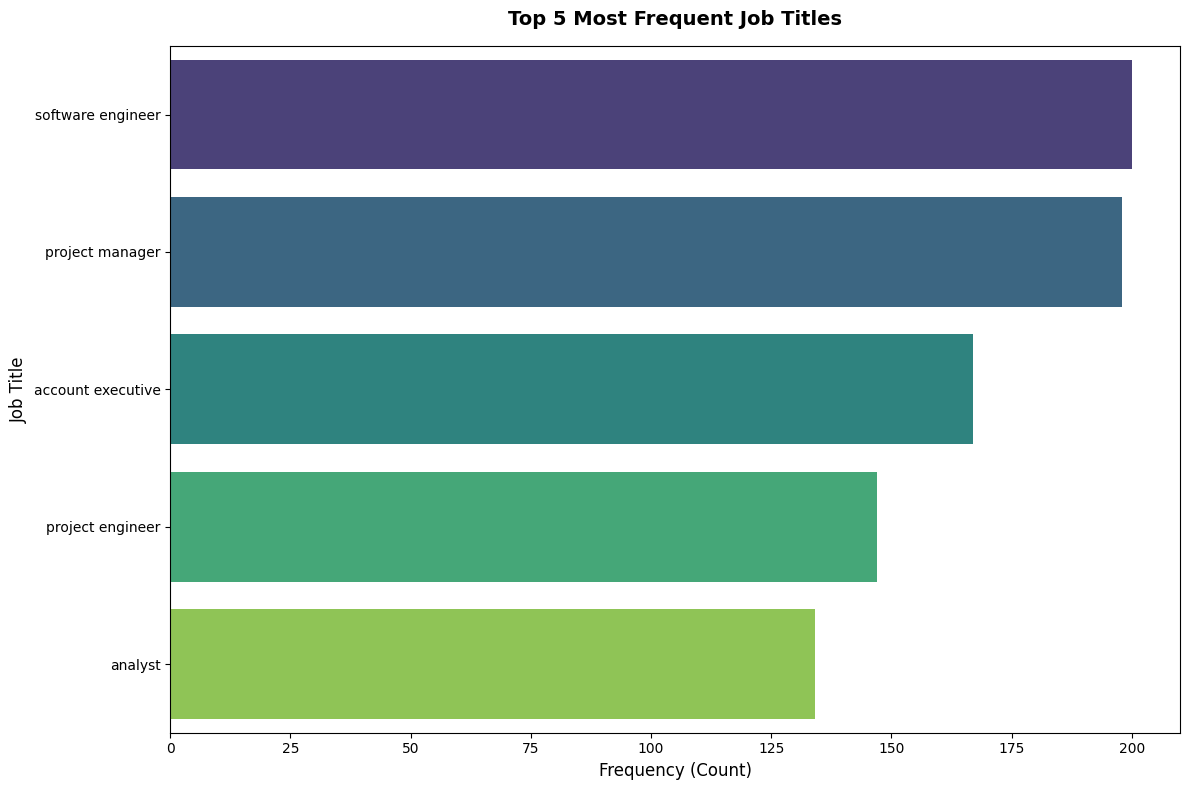

In [ ]:
top_5_titles = df['cleaned_title'].value_counts().head(5)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_5_titles.values, y=top_5_titles.index, palette='viridis')
plt.title('Top 5 Most Frequent Job Titles', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency (Count)', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.tight_layout()
plt.show()

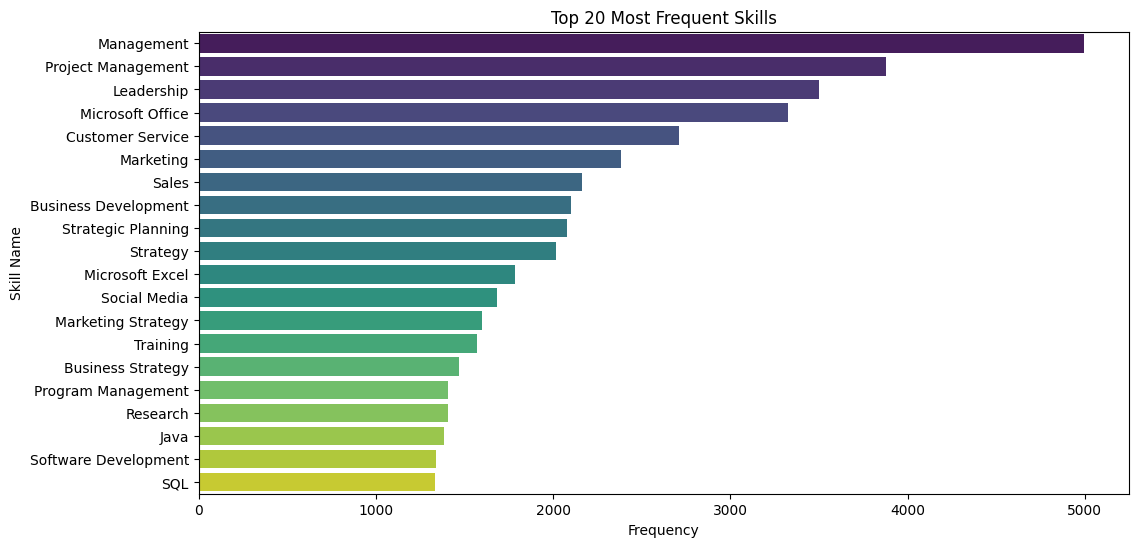

In [ ]:
all_skills = [skill for sublist in df['skills_required'] for skill in sublist]
skill_counts = Counter(all_skills)
common_skills = skill_counts.most_common(20)

plt.figure(figsize=(12, 6))
skills, counts = zip(*common_skills)
sns.barplot(x=list(counts), y=list(skills), palette='viridis')
plt.title('Top 20 Most Frequent Skills')
plt.xlabel('Frequency')
plt.ylabel('Skill Name')
plt.show()

In [ ]:
print("Skill Complexity Statistical Summary:")
print(df['skills_required'].apply(len).describe().apply(lambda x: f"{x:,.2f}" if x > 100 else f"{x:.2f}"))

Skill Complexity Statistical Summary:
count    8,084.00
mean        19.91
std          0.91
min          3.00
25%         20.00
50%         20.00
75%         20.00
max         48.00
Name: skills_required, dtype: str


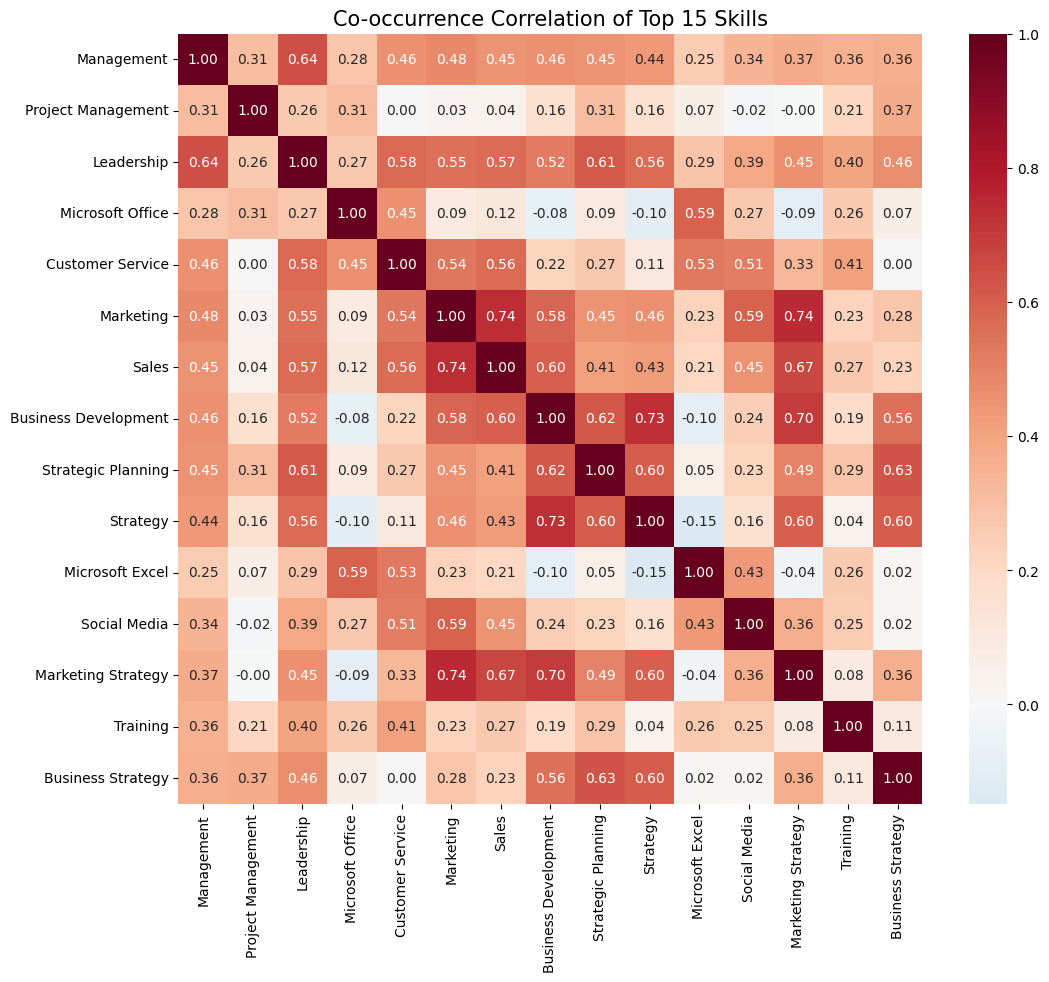

In [ ]:
top_15_skills = [s for s, c in skill_counts.most_common(15)]

mlb = MultiLabelBinarizer(classes=top_15_skills)
skills_matrix = mlb.fit_transform(df['skills_required'])
skills_df = pd.DataFrame(skills_matrix, columns=top_15_skills)

correlation_matrix = skills_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Co-occurrence Correlation of Top 15 Skills', fontsize=15)
plt.show()

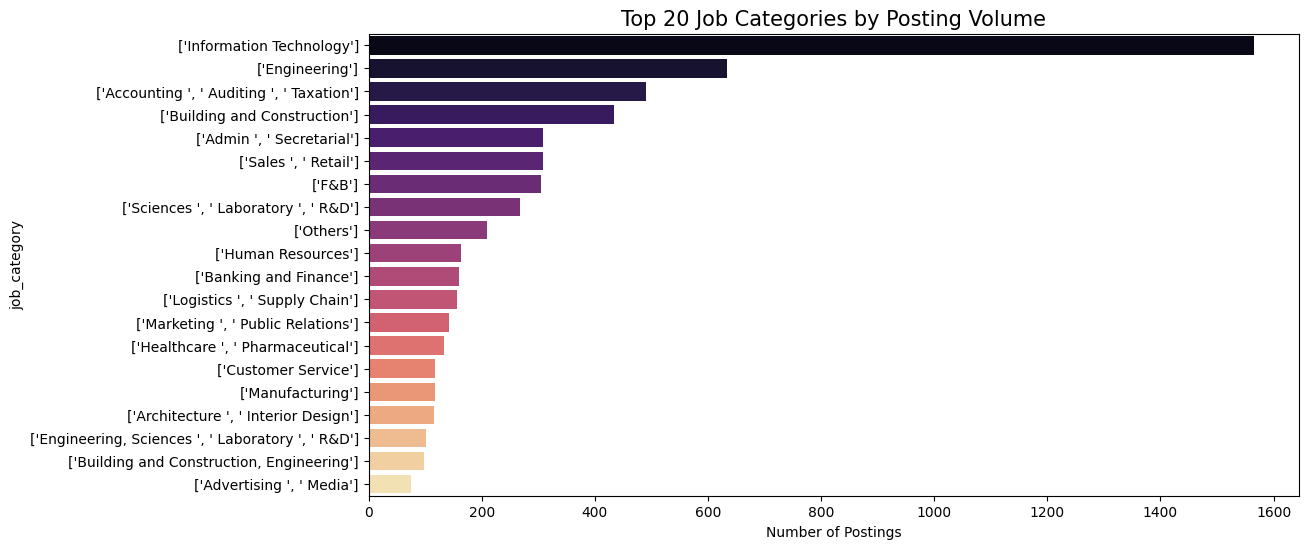

In [ ]:
category_counts = df['job_category'].explode().value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='magma')
plt.title('Top 20 Job Categories by Posting Volume', fontsize=15)
plt.xlabel('Number of Postings')
plt.show()

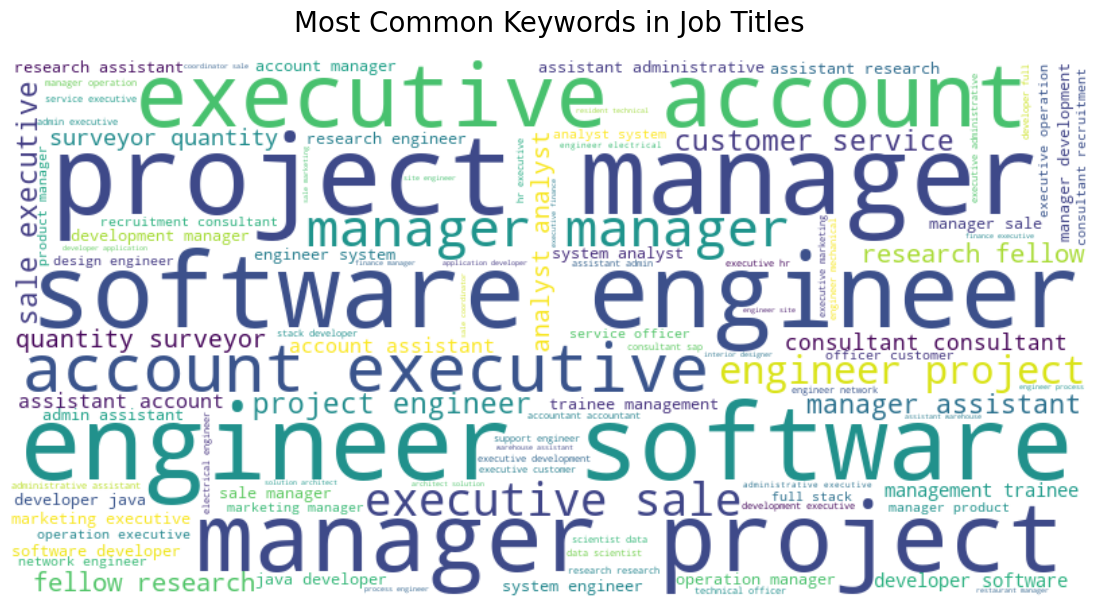

In [ ]:
all_titles = ' '.join(df['cleaned_title'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100).generate(all_titles)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Keywords in Job Titles', fontsize=20, pad=20)
plt.show()

# Feature Engineering

## Train Test Split

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print(f"Train size:      {len(train_df)} (80%)")
print(f"Validation size: {len(val_df)} (10%)")
print(f"Test size:       {len(test_df)} (10%)")

Train size:      6467 (80%)
Validation size: 808 (10%)
Test size:       809 (10%)


# Evaluation Metrics

In [ ]:
def recall_at_k(y_true, y_pred, k=20):
    scores = [len(set(t).intersection(p[:k]))/len(t) if len(t)>0 else 0 for t, p in zip(y_true, y_pred)]
    return np.mean(scores) * 100

def precision_at_k(y_true, y_pred, k=20):
    scores = [len(set(t).intersection(p[:k]))/k for t, p in zip(y_true, y_pred)]
    return np.mean(scores) * 100

def f1_at_k(y_true, y_pred, k=20):
    f1_scores = []
    for t, p in zip(y_true, y_pred):
        intersect = len(set(t).intersection(p[:k]))
        prec, rec = intersect/k, intersect/len(t) if len(t)>0 else 0
        f1_scores.append(2*prec*rec/(prec+rec) if (prec+rec)>0 else 0)
    return np.mean(f1_scores) * 100

def ndcg_at_k(y_true, y_pred, k=20):
    scores = []
    for t, p in zip(y_true, y_pred):
        t_set = set(t)
        dcg = sum([1/math.log2(i+2) for i, s in enumerate(p[:k]) if s in t_set])
        idcg = sum([1/math.log2(i+2) for i in range(min(len(t_set), k))])
        scores.append(dcg/idcg if idcg>0 else 0)
    return np.mean(scores) * 100

def mrr_at_k(y_true, y_pred, k=20):
    rr_scores = []
    for t, p in zip(y_true, y_pred):
        rr = 0.0
        for i, s in enumerate(p[:k]):
            if s in t: rr = 1/(i+1); break
        rr_scores.append(rr)
    return np.mean(rr_scores)

# BM25 Baseline

## Tokenization

In [ ]:
tokenized_title = [doc.split() for doc in train_df['cleaned_title'].tolist()]
tokenized_role = [doc.split() for doc in train_df['cleaned_role'].tolist()]
tokenized_req   = [doc.split() for doc in train_df['cleaned_req'].tolist()]
tokenized_description  = [doc.split() for doc in train_df['cleaned_description'].tolist()]
tokenized_content  = [doc.split() for doc in train_df['cleaned_content'].tolist()]

print("Tokenized corpora prepared for Title, Role, Requirements, Full Description and Full Content.")

Tokenized corpora prepared for Title, Role, Requirements, Full Description and Full Content.


In [ ]:
bm25_title = BM25Okapi(tokenized_title)
bm25_role = BM25Okapi(tokenized_role)
bm25_req   = BM25Okapi(tokenized_req)
bm25_description  = BM25Okapi(tokenized_description)
bm25_content  = BM25Okapi(tokenized_content)

## Hyperparameter Tuning

In [ ]:
input_configs = {
    'cleaned_title': tokenized_title,
    'cleaned_role': tokenized_role,
    'cleaned_req': tokenized_req,
    'cleaned_description': tokenized_description,
    'cleaned_content': tokenized_content
}

k1_space = [1.8, 2.0, 2.5]
b_space = [0.5, 0.75, 0.85]
best_val_f1 = -1
best_config = {}
results_list = []
val_sample = val_df
combinations = []

for col_name, corpus in input_configs.items():
    for k1, b in itertools.product(k1_space, b_space):
        combinations.append((col_name, corpus, k1, b))
total_combinations = len(combinations)
current_step = 0
column_best_f1 = {col: -1 for col in input_configs.keys()}

for col_name, corpus, k1, b in tqdm(combinations, desc="Grid Search Progress"):
    current_step += 1
    temp_model = BM25Okapi(corpus, k1=k1, b=b)
    y_true_val, y_pred_val = [], []
    for _, row in val_sample.iterrows():
        y_true_val.append(row['skills_required'])
        query = row[col_name].split()
        scores = temp_model.get_scores(query)
        top_idx = np.argsort(scores)[::-1][:20]
        skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
        y_pred_val.append([s for s, _ in Counter(skills).most_common(20)])
    current_f1 = f1_at_k(y_true_val, y_pred_val, k=20)
    results_list.append({'column': col_name,'k1': k1,'b': b,'F1': current_f1})

    if column_best_f1[col_name] == -1:
        column_best_f1[col_name] = current_f1
        print(f"\n[{col_name}] Initial Baseline: k1={k1}, b={b} -> F1: {current_f1:.2f}%")
        print("-" * 50)
    elif current_f1 > column_best_f1[col_name]:
        old_col_f1 = column_best_f1[col_name]
        column_best_f1[col_name] = current_f1
        print(f"\n[{col_name}] Better Parameters Found: k1={k1}, b={b} -> F1: {current_f1:.2f}% (Improved from {old_col_f1:.2f}%)")
        print("-" * 50)

    if current_f1 > best_val_f1:
        best_val_f1 = current_f1
        best_config = {'column': col_name, 'k1': k1, 'b': b, 'corpus': corpus}

print(f"\nGrid Search Step 1 Finished!")
print(f"Overall Best Config: {best_config['column']} (k1={best_config['k1']}, b={best_config['b']}) -> Global Best F1: {best_val_f1:.2f}%\n")
best_bm25 = BM25Okapi(best_config['corpus'], k1=best_config['k1'], b=best_config['b'])
results_df = pd.DataFrame(results_list)

Grid Search Progress:   2%|█▎                                                           | 1/45 [00:01<01:12,  1.64s/it]


[cleaned_title] Initial Baseline: k1=1.8, b=0.5 -> F1: 78.16%
--------------------------------------------------


Grid Search Progress:   4%|██▋                                                          | 2/45 [00:03<01:08,  1.59s/it]


[cleaned_title] Better Parameters Found: k1=1.8, b=0.75 -> F1: 78.89% (Improved from 78.16%)
--------------------------------------------------


Grid Search Progress:  11%|██████▊                                                      | 5/45 [00:07<00:58,  1.46s/it]


[cleaned_title] Better Parameters Found: k1=2.0, b=0.75 -> F1: 78.90% (Improved from 78.89%)
--------------------------------------------------


Grid Search Progress:  22%|█████████████▎                                              | 10/45 [01:19<12:26, 21.32s/it]


[cleaned_role] Initial Baseline: k1=1.8, b=0.5 -> F1: 58.25%
--------------------------------------------------


Grid Search Progress:  24%|██████████████▋                                             | 11/45 [02:30<20:39, 36.45s/it]


[cleaned_role] Better Parameters Found: k1=1.8, b=0.75 -> F1: 59.90% (Improved from 58.25%)
--------------------------------------------------


Grid Search Progress:  31%|██████████████████▋                                         | 14/45 [05:46<29:06, 56.34s/it]


[cleaned_role] Better Parameters Found: k1=2.0, b=0.75 -> F1: 60.08% (Improved from 59.90%)
--------------------------------------------------


Grid Search Progress:  42%|█████████████████████████▎                                  | 19/45 [10:29<23:44, 54.81s/it]


[cleaned_req] Initial Baseline: k1=1.8, b=0.5 -> F1: 53.89%
--------------------------------------------------


Grid Search Progress:  44%|██████████████████████████▋                                 | 20/45 [11:07<20:46, 49.84s/it]


[cleaned_req] Better Parameters Found: k1=1.8, b=0.75 -> F1: 54.42% (Improved from 53.89%)
--------------------------------------------------


Grid Search Progress:  47%|████████████████████████████                                | 21/45 [11:49<18:59, 47.46s/it]


[cleaned_req] Better Parameters Found: k1=1.8, b=0.85 -> F1: 54.46% (Improved from 54.42%)
--------------------------------------------------


Grid Search Progress:  58%|██████████████████████████████████▋                         | 26/45 [15:42<14:47, 46.72s/it]


[cleaned_req] Better Parameters Found: k1=2.5, b=0.75 -> F1: 54.49% (Improved from 54.46%)
--------------------------------------------------


Grid Search Progress:  60%|████████████████████████████████████                        | 27/45 [16:28<14:00, 46.69s/it]


[cleaned_req] Better Parameters Found: k1=2.5, b=0.85 -> F1: 54.63% (Improved from 54.49%)
--------------------------------------------------


Grid Search Progress:  62%|█████████████████████████████████████▎                      | 28/45 [18:48<21:09, 74.65s/it]


[cleaned_description] Initial Baseline: k1=1.8, b=0.5 -> F1: 60.20%
--------------------------------------------------


Grid Search Progress:  64%|██████████████████████████████████████▋                     | 29/45 [21:09<25:13, 94.61s/it]


[cleaned_description] Better Parameters Found: k1=1.8, b=0.75 -> F1: 61.12% (Improved from 60.20%)
--------------------------------------------------


Grid Search Progress:  67%|███████████████████████████████████████▎                   | 30/45 [23:34<27:24, 109.65s/it]


[cleaned_description] Better Parameters Found: k1=1.8, b=0.85 -> F1: 61.16% (Improved from 61.12%)
--------------------------------------------------


Grid Search Progress:  71%|█████████████████████████████████████████▉                 | 32/45 [28:15<27:11, 125.49s/it]


[cleaned_description] Better Parameters Found: k1=2.0, b=0.75 -> F1: 61.23% (Improved from 61.16%)
--------------------------------------------------


Grid Search Progress:  78%|█████████████████████████████████████████████▉             | 35/45 [35:28<22:57, 137.75s/it]


[cleaned_description] Better Parameters Found: k1=2.5, b=0.75 -> F1: 61.47% (Improved from 61.23%)
--------------------------------------------------


Grid Search Progress:  82%|████████████████████████████████████████████████▌          | 37/45 [40:08<18:29, 138.72s/it]


[cleaned_content] Initial Baseline: k1=1.8, b=0.5 -> F1: 63.37%
--------------------------------------------------


Grid Search Progress:  84%|█████████████████████████████████████████████████▊         | 38/45 [42:30<16:16, 139.46s/it]


[cleaned_content] Better Parameters Found: k1=1.8, b=0.75 -> F1: 64.02% (Improved from 63.37%)
--------------------------------------------------


Grid Search Progress:  87%|███████████████████████████████████████████████████▏       | 39/45 [44:50<13:58, 139.69s/it]


[cleaned_content] Better Parameters Found: k1=1.8, b=0.85 -> F1: 64.15% (Improved from 64.02%)
--------------------------------------------------


Grid Search Progress:  91%|█████████████████████████████████████████████████████▊     | 41/45 [49:36<09:26, 141.68s/it]


[cleaned_content] Better Parameters Found: k1=2.0, b=0.75 -> F1: 64.26% (Improved from 64.15%)
--------------------------------------------------


Grid Search Progress:  98%|█████████████████████████████████████████████████████████▋ | 44/45 [57:03<02:26, 146.04s/it]


[cleaned_content] Better Parameters Found: k1=2.5, b=0.75 -> F1: 64.55% (Improved from 64.26%)
--------------------------------------------------


Grid Search Progress: 100%|████████████████████████████████████████████████████████████| 45/45 [59:32<00:00, 79.40s/it]


Grid Search Step 1 Finished!
Overall Best Config: cleaned_title (k1=2.0, b=0.75) -> Global Best F1: 78.90%



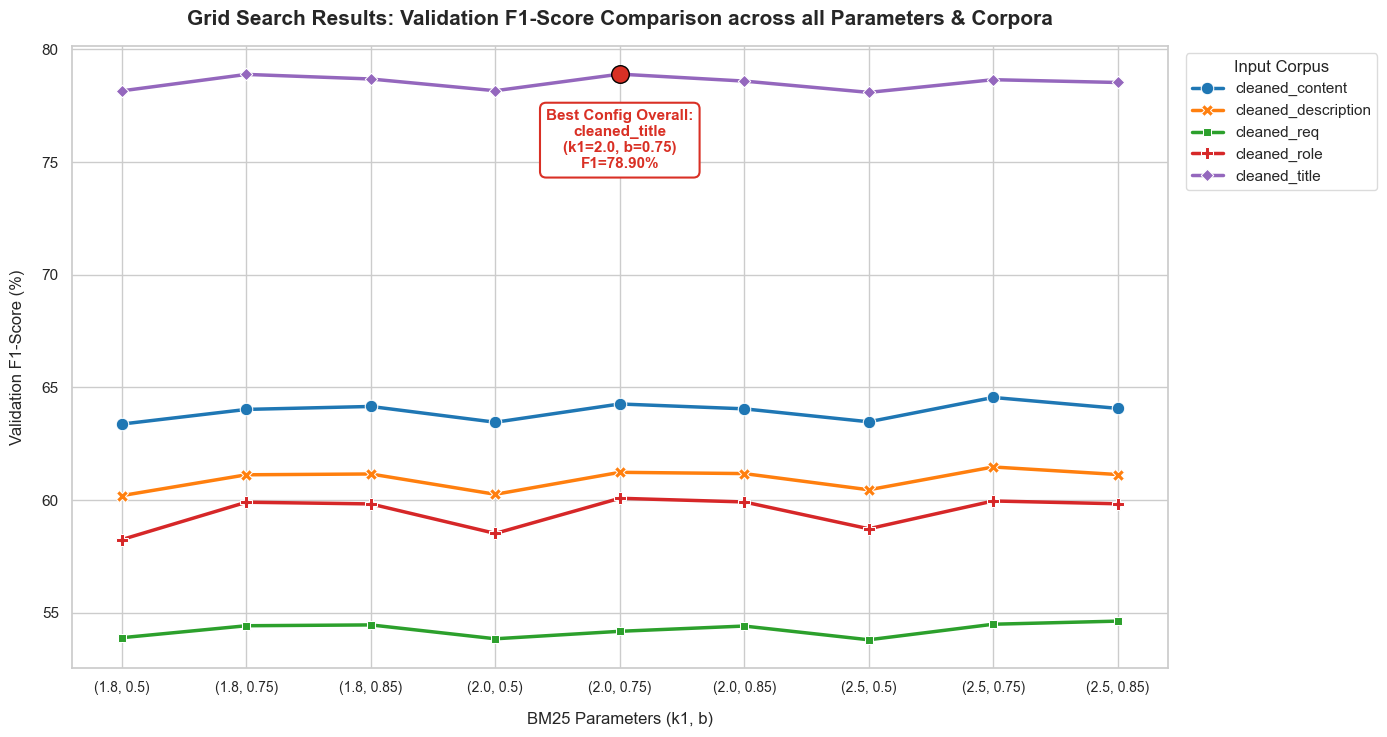

In [ ]:
results_df['param_comb'] = results_df.apply(lambda r: f"({r['k1']}, {r['b']})", axis=1)
param_order = [f"({k1}, {b})" for k1, b in itertools.product(k1_space, b_space)]
results_df['param_comb'] = pd.Categorical(results_df['param_comb'], categories=param_order, ordered=True)
results_df = results_df.sort_values(by=['column', 'param_comb'])

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.family': 'sans-serif','font.size': 11,'axes.labelsize': 13,'axes.titlesize': 14,'xtick.labelsize': 10,'ytick.labelsize': 11})
plt.figure(figsize=(14, 7.5))
sns.lineplot(data=results_df,x='param_comb',y='F1',hue='column',style='column',markers=True,dashes=False,linewidth=2.5,markersize=9,palette='tab10')
best_idx = results_df['F1'].idxmax()
best_row = results_df.loc[best_idx]
best_x = best_row['param_comb']
best_y = best_row['F1']
best_col = best_row['column']
plt.scatter(best_x, best_y, color='#d93025', s=160, zorder=5, edgecolor='black')
plt.annotate(
    f"Best Config Overall:\n{best_col}\n(k1={best_row['k1']}, b={best_row['b']})\nF1={best_y:.2f}%",
    (best_x, best_y),
    textcoords="offset points",
    xytext=(0, -25),
    ha='center',
    va='top',
    color='#d93025',
    weight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5)
)

plt.title("Grid Search Results: Validation F1-Score Comparison across all Parameters & Corpora", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("BM25 Parameters (k1, b)", fontsize=12, labelpad=12)
plt.ylabel("Validation F1-Score (%)", fontsize=12, labelpad=12)
plt.legend(title="Input Corpus", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True, facecolor='white', edgecolor='lightgray', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
target_col = best_config['column']
print(f"Joint Tuning for Neighbors (Top-N) and Recommended Skills (Top-K)...")
print(f"Using Best Corpus: '{target_col}' | k1: {best_config['k1']} | b: {best_config['b']}")
print("-" * 70)

neighbor_space = [3, 5, 10, 15, 20, 30, 50, 100, 150, 200]
skill_k_space = [5, 10, 15, 20, 25, 30]
joint_results = []

for top_n in tqdm(neighbor_space, desc="Joint Tuning Progress"):
    y_true_val = []
    predictions_dict = {k: [] for k in skill_k_space}

    for _, row in val_sample.iterrows():
        y_true_val.append(row['skills_required'])
        query = row[target_col].split()
        scores = best_bm25.get_scores(query)
        top_idx = np.argsort(scores)[::-1][:top_n]
        skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
        most_common_skills = [s for s, _ in Counter(skills).most_common(max(skill_k_space))]

        for k in skill_k_space:
            predictions_dict[k].append(most_common_skills[:k])

    for k in skill_k_space:
        current_f1 = f1_at_k(y_true_val, predictions_dict[k], k=k)
        joint_results.append({'top_n': top_n,'top_k': k,'F1': current_f1})

tuning_df = pd.DataFrame(joint_results)
best_row = tuning_df.loc[tuning_df['F1'].idxmax()]
best_top_n = int(best_row['top_n'])
best_top_k = int(best_row['top_k'])
best_f1 = best_row['F1']

print("\nBest Hyperparameters Found overall:")
print("="*55)
print(f"   Best Retrieved Neighbors (Top-N):{best_top_n}")
print(f"   Best Recommended Skills (Top-K) :{best_top_k}")
print(f"   Optimal Validation F1-Score     :{best_f1:.2f}%")
print("="*55 + "\n")

Joint Tuning for Neighbors (Top-N) and Recommended Skills (Top-K)...
Using Best Corpus: 'cleaned_title' | k1: 2.0 | b: 0.75
----------------------------------------------------------------------


Joint Tuning Progress: 100%|███████████████████████████████████████████████████████████| 10/10 [00:21<00:00,  2.17s/it]


Best Hyperparameters Found overall:
   Best Retrieved Neighbors (Top-N):10
   Best Recommended Skills (Top-K) :20
   Optimal Validation F1-Score     :82.50%



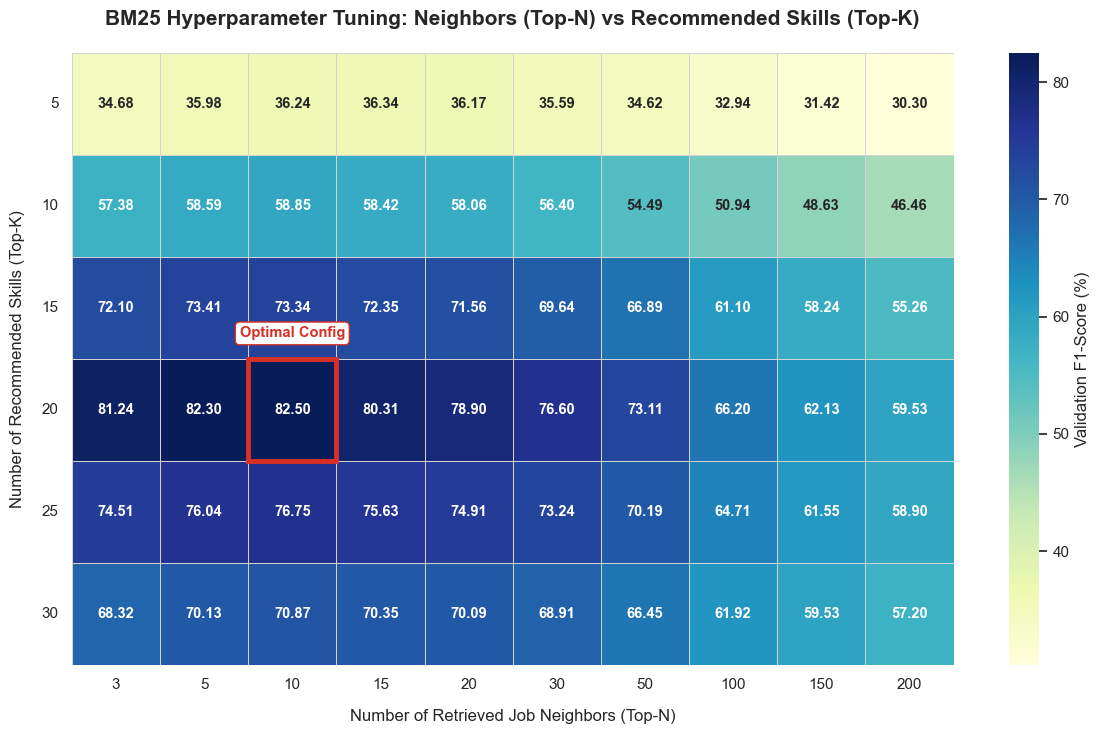

In [ ]:
heatmap_data = tuning_df.pivot(index='top_k', columns='top_n', values='F1')
heatmap_data = heatmap_data.sort_index(ascending=True)

sns.set_theme(style="white")
plt.figure(figsize=(12, 7.5))
ax = sns.heatmap(heatmap_data,annot=True,fmt=".2f",cmap="YlGnBu",cbar_kws={'label': 'Validation F1-Score (%)'},linewidths=0.5,linecolor='lightgray',annot_kws={'size': 10.5, 'weight': 'bold'})

max_val = heatmap_data.values.max()
max_loc = np.argwhere(heatmap_data.values == max_val)[0]
best_row_idx = max_loc[0]
best_col_idx = max_loc[1]

ax.add_patch(Rectangle((best_col_idx, best_row_idx),1,1,fill=False,edgecolor='#d93025',lw=3.5, zorder=10))
ax.text(
    best_col_idx + 0.5,
    best_row_idx - 0.25 if best_row_idx > 0 else best_row_idx + 1.25,
    "Optimal Config",
    color='#d93025',
    weight='bold',
    fontsize=10.5,
    ha='center',
    va='center',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d93025", lw=1)
)
plt.title('BM25 Hyperparameter Tuning: Neighbors (Top-N) vs Recommended Skills (Top-K)', fontsize=15,
fontweight='bold', pad=20)
plt.xlabel('Number of Retrieved Job Neighbors (Top-N)', fontsize=12, labelpad=12)
plt.ylabel('Number of Recommended Skills (Top-K)', fontsize=12, labelpad=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save dump file

In [ ]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

bm25_package = {
    "model": best_bm25,
    "best_config": best_config,
    "best_top_n": best_top_n,
    "best_top_k": best_top_k
}

model_path = os.path.join(save_dir, "best_bm25_model_careers.joblib")
joblib.dump(bm25_package, model_path)

print(f"BM25 model package saved successfully to: {model_path}")

BM25 model package saved successfully to: saved_models\best_bm25_model_careers.joblib


## Evaluate on Test Set

In [ ]:
loaded_bm25_pkg = joblib.load("saved_models/best_bm25_model_careers.joblib")

if isinstance(loaded_bm25_pkg, dict):
    best_bm25 = loaded_bm25_pkg["model"]
    best_config = loaded_bm25_pkg["best_config"]
    best_top_n = loaded_bm25_pkg["best_top_n"]
    best_top_k = loaded_bm25_pkg["best_top_k"]
else:
    print("Notice: Loaded old format model. Please re-run Cell 65 to update your saved file.")
    best_bm25 = loaded_bm25_pkg
    best_config = globals().get('best_config', {'column': 'cleaned_title', 'k1': 2.0, 'b': 0.75})
    best_top_n = globals().get('best_top_n', 10)
    best_top_k = globals().get('best_top_k', 20)
print("BM25 Baseline Model Package Loaded Successfully!")
print("=" * 55)
print("  LOADED OPTIMAL PARAMETERS:")
print(f"    - Target Text Column        : '{best_config['column']}'")
print(f"    - BM25 k1 Parameter        : {best_config['k1']}")
print(f"    - BM25 b Parameter         : {best_config['b']}")
print(f"    - Retrieved Neighbors (Top-N): {best_top_n}")
print(f"    - Recommended Skills (Top-K) : {best_top_k}")
print("=" * 55)

print("Running evaluation on test set using BM25 Baseline Model...")
y_true_test, y_pred_test = [], []
start_time = time.time()

for _, row in test_df.iterrows():
    y_true_test.append(row['skills_required'])
    query = row[best_config['column']].split()
    scores = best_bm25.get_scores(query)
    top_idx = np.argsort(scores)[::-1][:best_top_n]
    skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
    top_skills = [s for s, _ in Counter(skills).most_common(best_top_k)]
    y_pred_test.append(top_skills)
inference_time = time.time() - start_time

print("=" * 55)
print(f"  TEST EVALUATION RESULTS (@{best_top_k})")
print(f"    - Precision  : {precision_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"    - Recall     : {recall_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"    - F1-Score   : {f1_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"    - NDCG       : {ndcg_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"---------------------------------------------")
print(f"    - Inference Time : {inference_time:.4f} seconds")
print("=" * 55)

BM25 Baseline Model Package Loaded Successfully!
  LOADED OPTIMAL PARAMETERS:
    - Target Text Column        : 'cleaned_title'
    - BM25 k1 Parameter        : 2.0
    - BM25 b Parameter         : 0.75
    - Retrieved Neighbors (Top-N): 10
    - Recommended Skills (Top-K) : 20
Running evaluation on test set using BM25 Baseline Model...
  TEST EVALUATION RESULTS (@20)
    - Precision  : 78.80%
    - Recall     : 78.94%
    - F1-Score   : 78.83%
    - NDCG       : 81.87%
---------------------------------------------
    - Inference Time : 2.0118 seconds


# BM25 Ensemble (BM25 + LightGBM (XENDCG)

In [ ]:
def calculate_relevance(true_skills, candidate_skills):
    set1, set2 = set(true_skills), set(candidate_skills)
    if not set1 or not set2: return
    return len(set1.intersection(set2)) / len(set1.union(set2))

In [ ]:
def prepare_ranking_data(query_df, corpus_df, bm25_models, num_candidates=100):
    X, y, groups = [], [], []
    print(f"Extracting features for {len(query_df)} queries (Retrieval K={num_candidates})...")

    for q_idx, q_row in query_df.iterrows():
        query_tokens = q_row[best_config['column']].split()

        scores = best_bm25.get_scores(query_tokens)

        if q_idx < len(corpus_df):
            scores[q_idx] = -np.inf

        candidate_indices = np.argsort(scores)[::-1][:num_candidates]

        q_words = set(query_tokens)
        f_sl = len(query_tokens)

        f_title_batch = bm25_models['title'].get_batch_scores(q_row['cleaned_title'].split(), candidate_indices)
        f_role_batch  = bm25_models['role'].get_batch_scores(q_row['cleaned_role'].split(), candidate_indices)
        f_req_batch   = bm25_models['req'].get_batch_scores(q_row['cleaned_req'].split(), candidate_indices)
        f_desc_batch  = bm25_models['desc'].get_batch_scores(q_row['cleaned_description'].split(), candidate_indices)
        f_full_batch  = bm25_models['full'].get_batch_scores(q_row['full_content'].split(), candidate_indices)

        for i, idx in enumerate(candidate_indices):
            c_row = corpus_df.iloc[idx]

            f_title = f_title_batch[i]
            f_role  = f_role_batch[i]
            f_req   = f_req_batch[i]
            f_desc  = f_desc_batch[i]
            f_full  = f_full_batch[i]

            c_words = set(c_row['full_content'].split())
            f_overlap = len(q_words.intersection(c_words))
            f_tl = len(c_row['cleaned_title'].split())
            f_sk = len(c_row['skills_required'])
            f_rank = i + 1

            X.append([f_title, f_role, f_req, f_desc, f_full,
                      f_overlap, f_tl, f_sl, f_sk, f_rank])

            js = calculate_relevance(q_row['skills_required'], c_row['skills_required'])
            y.append(int(js * 10))

        groups.append(num_candidates)
    return np.array(X), np.array(y), groups

In [ ]:
bm25_models = {}

column_mapping = {
    'title': ('cleaned_title', tokenized_title),
    'role': ('cleaned_role', tokenized_role),
    'req': ('cleaned_req', tokenized_req),
    'desc': ('cleaned_description', tokenized_description),
    'full': ('cleaned_content', tokenized_content)
}

print("Initializing BM25 feature models with their respective optimal parameters...")
for model_key, (col_name, corpus) in column_mapping.items():
    col_df = results_df[results_df['column'] == col_name]
    best_row = col_df.loc[col_df['F1'].idxmax()]
    best_k1 = best_row['k1']
    best_b = best_row['b']

    bm25_models[model_key] = BM25Okapi(corpus, k1=best_k1, b=best_b)
    print(f" - {model_key}: initialized with k1={best_k1}, b={best_b} (Best F1: {best_row['F1']:.2f}%)")
print("-" * 75)

X_train_rank, y_train_rank, groups_train = prepare_ranking_data(train_df, train_df, bm25_models, num_candidates=100)

y_train_rank = y_train_rank.astype(int)
ranker = lgb.LGBMRanker(
    objective="rank_xendcg",
    metric="ndcg",
    n_estimators=500,
    num_leaves=63,
    learning_rate=0.01,
    importance_type='gain'
)
ranker.fit(
    X_train_rank, y_train_rank,
    group=groups_train,
    callbacks=[lgb.log_evaluation(period=50)]
)
print("\nLambdaMART Training Complete!")


Initializing BM25 feature models with their respective optimal parameters...
 - title: initialized with k1=2.0, b=0.75 (Best F1: 78.90%)
 - role: initialized with k1=2.0, b=0.75 (Best F1: 60.08%)
 - req: initialized with k1=2.5, b=0.85 (Best F1: 54.63%)
 - desc: initialized with k1=2.5, b=0.75 (Best F1: 61.47%)
 - full: initialized with k1=2.5, b=0.75 (Best F1: 64.55%)
---------------------------------------------------------------------------
Extracting features for 6467 queries (Retrieval K=100)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1414
[LightGBM] [Info] Number of data points in the train set: 646700, number of used features: 10

LambdaMART Training Complete!


## Hypertuning

In [ ]:
print("Searching for the BEST Initial Retrieval Corpus for Ensemble...")
retrieval_models = ['title', 'role', 'req', 'desc', 'full']
best_retrieval_corpus = None
best_retrieval_f1 = -1
corpus_results = []
temp_ranker = lgb.LGBMRanker(objective="rank_xendcg",n_estimators=500,num_leaves=63,learning_rate=0.05,random_state=42,verbose=-1)
temp_ranker.fit(X_train_rank, y_train_rank, group=groups_train)
for r_name in retrieval_models:
    y_true_v, y_pred_v = [], []
    for i in range(len(val_df.head(100))):
        q_row = val_df.head(100).iloc[i]
        q_tokens = q_row[best_config['column']].split()
        candidate_indices = np.argsort(bm25_models[r_name].get_scores(q_tokens))[::-1][:100]
        feats = []
        q_words = set(q_tokens)
        f_sl = len(q_tokens)
        f_title_batch = bm25_models['title'].get_batch_scores(q_row['cleaned_title'].split(), candidate_indices)
        f_role_batch  = bm25_models['role'].get_batch_scores(q_row['cleaned_role'].split(), candidate_indices)
        f_req_batch   = bm25_models['req'].get_batch_scores(q_row['cleaned_req'].split(), candidate_indices)
        f_desc_batch  = bm25_models['desc'].get_batch_scores(q_row['cleaned_description'].split(), candidate_indices)
        f_full_batch  = bm25_models['full'].get_batch_scores(q_row['full_content'].split(), candidate_indices)
        for idx_i, idx in enumerate(candidate_indices):
            c_row = train_df.iloc[idx]
            f_t  = f_title_batch[idx_i]
            f_ro = f_role_batch[idx_i]
            f_r  = f_req_batch[idx_i]
            f_d  = f_desc_batch[idx_i]
            f_f  = f_full_batch[idx_i]
            f_o    = len(q_words.intersection(set(c_row['full_content'].split())))
            f_tl   = len(c_row['cleaned_title'].split())
            f_sk   = len(c_row['skills_required'])
            f_rank = idx_i + 1
            feats.append([f_t, f_ro, f_r, f_d, f_f, f_o, f_tl, f_sl, f_sk, f_rank])
        scores = temp_ranker.predict(np.array(feats))
        top_5_pos = candidate_indices[np.argsort(scores)[::-1][:5]]
        skills = [s for slist in train_df.iloc[top_5_pos]['skills_required'] for s in slist]
        y_pred_v.append([s for s, _ in Counter(skills).most_common(20)])
        y_true_v.append(q_row['skills_required'])
    current_f1 = f1_at_k(y_true_v, y_pred_v, k=20)
    print(f"Retrieval Corpus: {r_name:5} | Val F1: {current_f1:.2f}%")
    corpus_results.append({'corpus': r_name,'F1': current_f1})
    if current_f1 > best_retrieval_f1:
        best_retrieval_f1 = current_f1
        best_retrieval_corpus = r_name
print(f"\nThe BEST Retrieval Corpus for Ensemble is: '{best_retrieval_corpus}' (Val F1: {best_retrieval_f1:.2f}%)")
corpus_df = pd.DataFrame(corpus_results)

Searching for the BEST Initial Retrieval Corpus for Ensemble...
Retrieval Corpus: title | Val F1: 82.36%
Retrieval Corpus: role  | Val F1: 76.32%
Retrieval Corpus: req   | Val F1: 74.42%
Retrieval Corpus: desc  | Val F1: 76.67%
Retrieval Corpus: full  | Val F1: 81.56%

The BEST Retrieval Corpus for Ensemble is: 'title' (Val F1: 82.36%)


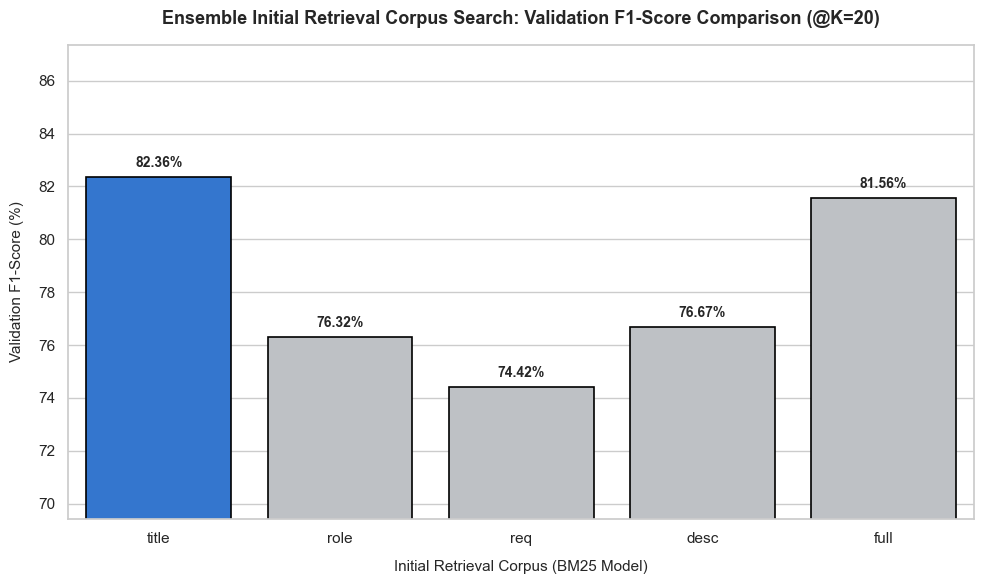

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

colors = ['#1a73e8' if c == best_retrieval_corpus else '#bdc1c6' for c in corpus_df['corpus']]

ax = sns.barplot(data=corpus_df,x='corpus',y='F1',palette=colors,edgecolor='black',linewidth=1.2)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        weight='bold',
        fontsize=10
    )

plt.title('Ensemble Initial Retrieval Corpus Search: Validation F1-Score Comparison (@K=20)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Initial Retrieval Corpus (BM25 Model)', fontsize=11, labelpad=10)
plt.ylabel('Validation F1-Score (%)', fontsize=11, labelpad=10)

f1_min = corpus_df['F1'].min()
f1_max = corpus_df['F1'].max()
plt.ylim(max(0, f1_min - 5), min(100, f1_max + 5))

plt.tight_layout()
plt.show()

In [ ]:
X_val, y_val, groups_val = prepare_ranking_data(val_df, train_df, bm25_models, num_candidates=100)
print(f"\nStarting Clean Tuning for LightGBM (No Regularization Constraints)...")
n_estimators_space = [100, 300, 500, 800]
num_leaves_space   = [31, 63, 95]
learning_rate_space = [0.05, 0.1, 0.15]
best_val_f1 = -1
best_lgb_params = {}
lgb_tuning_results = []
for n_est, leaves, lr in itertools.product(n_estimators_space, num_leaves_space, learning_rate_space):
    temp_ranker = lgb.LGBMRanker(objective="rank_xendcg",n_estimators=n_est,num_leaves=leaves,learning_rate=lr,random_state=42,verbose=-1)
    temp_ranker.fit(X_train_rank, y_train_rank, group=groups_train)
    y_true_v, y_pred_v = [], []
    for i in range(len(val_df.head(100))):
        start_idx = i * 100
        end_idx = start_idx + 100
        q_feats = X_val[start_idx:end_idx]
        scores = temp_ranker.predict(q_feats)
        q_row = val_df.head(100).iloc[i]
        query_tokens = q_row[best_config['column']].split()
        candidate_indices = np.argsort(best_bm25.get_scores(query_tokens))[::-1][:100]
        top_5_pos = candidate_indices[np.argsort(scores)[::-1][:5]]
        skills = [s for slist in train_df.iloc[top_5_pos]['skills_required'] for s in slist]
        y_pred_v.append([s for s, _ in Counter(skills).most_common(20)])
        y_true_v.append(q_row['skills_required'])
    current_f1 = f1_at_k(y_true_v, y_pred_v, k=20)
    print(f"n={n_est:4}, leaves={leaves:3}, lr={lr} | Val F1: {current_f1:.2f}%")
    lgb_tuning_results.append({'n_estimators': n_est,'num_leaves': leaves,'learning_rate': lr,'F1': current_f1})
    if current_f1 > best_val_f1:
        best_val_f1 = current_f1
        best_lgb_params = {'n_estimators': n_est, 'num_leaves': leaves, 'learning_rate': lr}
        print(f"New Record: {current_f1:.2f}%!")
print(f"\nFinal Tuned Parameters: {best_lgb_params} (Val F1: {best_val_f1:.2f}%)")
lgb_tuning_df = pd.DataFrame(lgb_tuning_results)

Extracting features for 808 queries (Retrieval K=100)...

Starting Clean Tuning for LightGBM (No Regularization Constraints)...
n= 100, leaves= 31, lr=0.05 | Val F1: 80.76%
New Record: 80.76%!
n= 100, leaves= 31, lr=0.1 | Val F1: 82.06%
New Record: 82.06%!
n= 100, leaves= 31, lr=0.15 | Val F1: 81.16%
n= 100, leaves= 63, lr=0.05 | Val F1: 80.41%
n= 100, leaves= 63, lr=0.1 | Val F1: 81.36%
n= 100, leaves= 63, lr=0.15 | Val F1: 81.31%
n= 100, leaves= 95, lr=0.05 | Val F1: 80.46%
n= 100, leaves= 95, lr=0.1 | Val F1: 79.21%
n= 100, leaves= 95, lr=0.15 | Val F1: 79.86%
n= 300, leaves= 31, lr=0.05 | Val F1: 81.76%
n= 300, leaves= 31, lr=0.1 | Val F1: 81.16%
n= 300, leaves= 31, lr=0.15 | Val F1: 81.76%
n= 300, leaves= 63, lr=0.05 | Val F1: 80.81%
n= 300, leaves= 63, lr=0.1 | Val F1: 81.51%
n= 300, leaves= 63, lr=0.15 | Val F1: 80.61%
n= 300, leaves= 95, lr=0.05 | Val F1: 81.31%
n= 300, leaves= 95, lr=0.1 | Val F1: 82.16%
New Record: 82.16%!
n= 300, leaves= 95, lr=0.15 | Val F1: 81.26%
n= 500, 

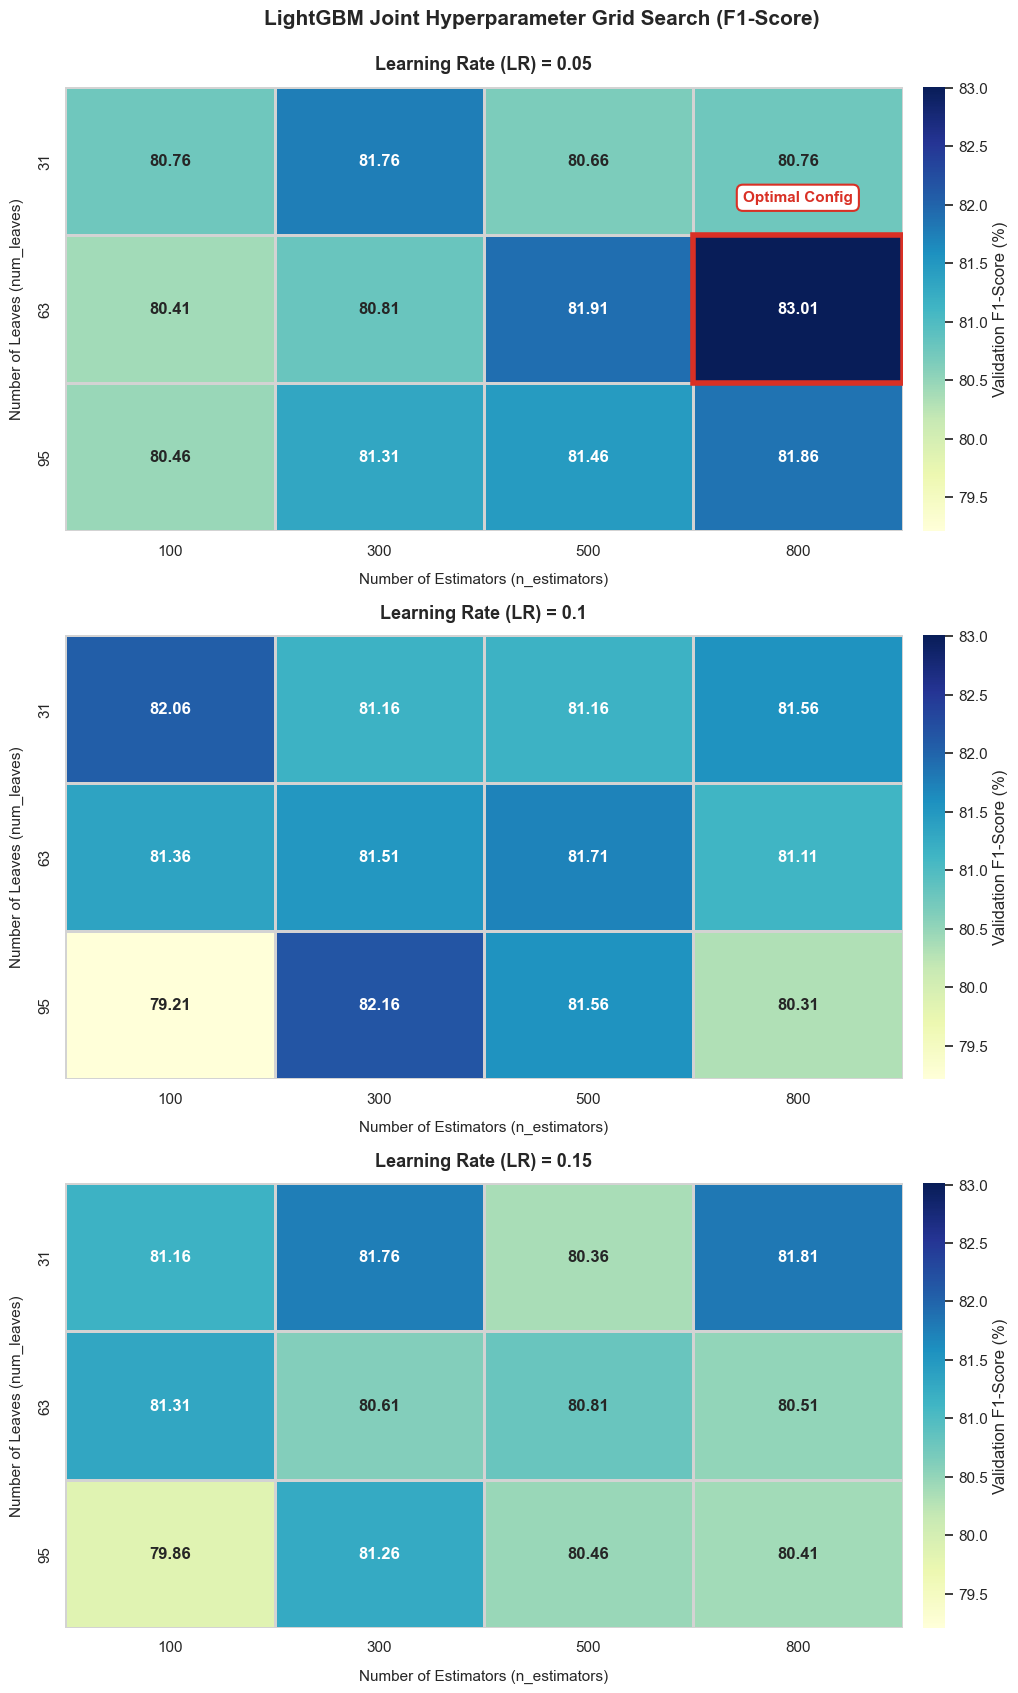

In [ ]:
lgb_tuning_df = pd.DataFrame(lgb_tuning_results)
sns.set_theme(style="white")
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11, 17))

learning_rates = [0.05, 0.1, 0.15]
best_n = best_lgb_params['n_estimators']
best_leaves = best_lgb_params['num_leaves']
best_lr = best_lgb_params['learning_rate']

vmin = lgb_tuning_df['F1'].min()
vmax = lgb_tuning_df['F1'].max()

for i, lr in enumerate(learning_rates):
    lr_df = lgb_tuning_df[lgb_tuning_df['learning_rate'] == lr]
    pivot_df = lr_df.pivot(index='num_leaves', columns='n_estimators', values='F1')
    pivot_df = pivot_df.sort_index(ascending=True)
    ax = axes[i]
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={'label': 'Validation F1-Score (%)', 'pad': 0.02},
        linewidths=0.8,
        linecolor='lightgray',
        annot_kws={'size': 12, 'weight': 'bold'},
        ax=ax
    )
    ax.set_title(f"Learning Rate (LR) = {lr}", fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("Number of Estimators (n_estimators)", fontsize=11, labelpad=10)
    ax.set_ylabel("Number of Leaves (num_leaves)", fontsize=11, labelpad=10)
    ax.tick_params(axis='x', labelbottom=True) # Ensure numbers are shown

    # 3. Highlight the overall optimal configuration
    if lr == best_lr:
        row_idx = list(pivot_df.index).index(best_leaves)
        col_idx = list(pivot_df.columns).index(best_n)

        ax.add_patch(
            Rectangle(
                (col_idx, row_idx),
                1,
                1,
                fill=False,
                edgecolor='#d93025',
                lw=4.0,  # Thicker border for large cells
                zorder=10
            )
        )
        ax.text(
            col_idx + 0.5,
            row_idx - 0.25 if row_idx > 0 else row_idx + 1.25,
            "Optimal Config",
            color='#d93025',
            weight='bold',
            fontsize=11,
            ha='center',
            va='center',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5)
        )

# Main Title and Layout adjustments
plt.suptitle('LightGBM Joint Hyperparameter Grid Search (F1-Score)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Evaluate On Test Set

In [ ]:
final_ranker = lgb.LGBMRanker(
    objective="rank_xendcg",
    n_estimators=best_lgb_params['n_estimators'],
    num_leaves=best_lgb_params['num_leaves'],
    learning_rate=best_lgb_params.get('learning_rate', 0.05),
    random_state=42,
        verbose=-1
)
final_ranker.fit(X_train_rank, y_train_rank, group=groups_train)

start_time = time.time()

y_true_ens, y_pred_ensemble = [], []
print(f"Evaluating BM25+LightGBM Ensemble on TEST SET...")
print(f"Retrieval Corpus: '{best_retrieval_corpus}' | Params: {best_lgb_params}")

for _, q_row in test_df.iterrows():
    y_true_ens.append(q_row['skills_required'])

    q_tokens = q_row[best_config['column']].split()
    bm25_scores = bm25_models[best_retrieval_corpus].get_scores(q_tokens)
    candidate_indices = np.argsort(bm25_scores)[::-1][:100]

    feats = []
    q_words = set(q_tokens)
    f_sl = len(q_tokens)

    f_title_batch = bm25_models['title'].get_batch_scores(q_row['cleaned_title'].split(), candidate_indices)
    f_role_batch  = bm25_models['role'].get_batch_scores(q_row['cleaned_role'].split(), candidate_indices)
    f_req_batch   = bm25_models['req'].get_batch_scores(q_row['cleaned_req'].split(), candidate_indices)
    f_desc_batch  = bm25_models['desc'].get_batch_scores(q_row['cleaned_description'].split(), candidate_indices)
    f_full_batch  = bm25_models['full'].get_batch_scores(q_row['full_content'].split(), candidate_indices)

    for i, idx in enumerate(candidate_indices):
        c_row = train_df.iloc[idx]
        f_o   = len(q_words.intersection(set(c_row['full_content'].split())))
        f_tl  = len(c_row['cleaned_title'].split())
        f_sk  = len(c_row['skills_required'])
        f_rank = i + 1

        feats.append([
            f_title_batch[i], f_role_batch[i], f_req_batch[i],
            f_desc_batch[i],  f_full_batch[i],
            f_o, f_tl, f_sl, f_sk, f_rank
        ])

    preds = final_ranker.predict(np.array(feats))
    top_5_pos = candidate_indices[np.argsort(preds)[::-1][:10]]

    skills_pool = [s for slist in train_df.iloc[top_5_pos]['skills_required'] for s in slist]
    y_pred_ensemble.append([s for s, _ in Counter(skills_pool).most_common(20)])

end_time = time.time()
inference_time_ens = end_time - start_time
memory_usage_ens = process.memory_info().rss / (1024 * 1024)

all_skills_f = list(set([s for sub in y_true_ens for s in sub] + [s for sub in y_pred_ensemble for s in sub]))
mlb_f = MultiLabelBinarizer(classes=all_skills_f).fit(all_skills_f)

print(f"\n{'='*52}")
print(f"---  FINAL STACKING RESULTS (BM25 + LightGBM) ---")
print(f"{'='*52}")
print(f"Precision@20:      {precision_at_k(y_true_ens, y_pred_ensemble, 20):.2f}%")
print(f"Recall@20:         {recall_at_k(y_true_ens, y_pred_ensemble, 20):.2f}%")
print(f"F1-Score@20:       {f1_at_k(y_true_ens, y_pred_ensemble, 20):.2f}%")
print(f"NDCG@20:           {ndcg_at_k(y_true_ens, y_pred_ensemble, 20):.2f}%")
print(f"Inference Time(s): {inference_time_ens:.4f}")
print(f"Memory Usage (MB): {memory_usage_ens:.2f}")
print(f"{'='*52}")

Evaluating BM25+LightGBM Ensemble on TEST SET...
Retrieval Corpus: 'title' | Params: {'n_estimators': 800, 'num_leaves': 63, 'learning_rate': 0.05}

---  FINAL STACKING RESULTS (BM25 + LightGBM) ---
Precision@20:      79.14%
Recall@20:         79.28%
F1-Score@20:       79.17%
NDCG@20:           82.33%
Inference Time(s): 36.3251
Memory Usage (MB): 1627.44


## Save BM25 Ensemble Model

In [ ]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

ensemble_package = {
    "final_ranker": final_ranker,
    "bm25_models": bm25_models,
    "best_retrieval_corpus": best_retrieval_corpus,
    "best_config": best_config,
    "best_ranker_params": {
        "n_estimators": 800,
        "num_leaves": 63,
        "learning_rate": 0.05
    },
    "best_top_n_neighbors": 10,
    "best_top_k": 20
}

model_path = os.path.join(save_dir, "bm25_lightgbm_ensemble_careers.joblib")
joblib.dump(ensemble_package, model_path)
print(f"BM25 + LightGBM Ensemble package successfully saved to: {model_path}")

BM25 + LightGBM Ensemble package successfully saved to: saved_models\bm25_lightgbm_ensemble_careers.joblib


# SBERT Baseline

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_sbert = SentenceTransformer('intfloat/e5-small-v2', device=device)
print(f"SBERT (E5) Model Loaded on {device}")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 6287.08it/s]


SBERT (E5) Model Loaded on cpu


In [ ]:
sbert_cols = ['title_SBERT', 'role_SBERT', 'req_SBERT', 'description_SBERT', 'content_SBERT']

train_embs_dict = {}
val_embs_dict   = {}
test_embs_dict  = {}

print("Starting Batch Encoding...")

for col in sbert_cols:
    print(f"\nProcessing column: [{col}]")

    train_passages = ["passage: " + str(t) for t in train_df[col]]
    val_queries    = ["query: " + str(t) for t in val_df[col]]
    test_queries   = ["query: " + str(t) for t in test_df[col]]

    train_embs_dict[col] = model_sbert.encode(train_passages, show_progress_bar=True, normalize_embeddings=True, convert_to_tensor=True)
    val_embs_dict[col]   = model_sbert.encode(val_queries, show_progress_bar=True, normalize_embeddings=True, convert_to_tensor=True)
    test_embs_dict[col]  = model_sbert.encode(test_queries, show_progress_bar=True, normalize_embeddings=True, convert_to_tensor=True)

print("\n All columns encoded successfully!")

Starting Batch Encoding...

Processing column: [title_SBERT]


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 30.67it/s]



Processing column: [role_SBERT]


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [00:08<00:00,  3.16it/s]



Processing column: [req_SBERT]


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [00:06<00:00,  3.96it/s]



Processing column: [description_SBERT]


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [00:14<00:00,  1.84it/s]



Processing column: [content_SBERT]


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [00:14<00:00,  1.85it/s]


 All columns encoded successfully!


## Hypertuning

In [ ]:
print("Searching for the BEST SBERT Input Column...")

best_sbert_col = None
best_sbert_f1 = -1
col_results = []

for col in sbert_cols:
    y_true_v, y_pred_v = [], []

    for i in range(len(val_df)):
        query_emb = val_embs_dict[col][i]
        cos_scores = util.cos_sim(query_emb, train_embs_dict[col])[0]

        top_indices = torch.topk(cos_scores, k=5).indices.cpu().numpy()

        skills = [s for slist in train_df.iloc[top_indices]['skills_required'] for s in slist]
        y_pred_v.append([s for s, _ in Counter(skills).most_common(10)])
        y_true_v.append(val_df.iloc[i]['skills_required'])

    current_f1 = f1_at_k(y_true_v, y_pred_v, k=10)
    print(f"Input Column: {col:18} | Val F1: {current_f1:.2f}%")

    col_results.append({'column': col,'F1': current_f1})

    if current_f1 > best_sbert_f1:
        best_sbert_f1 = current_f1
        best_sbert_col = col

print(f"\n The WINNER is: '{best_sbert_col}' with F1: {best_sbert_f1:.2f}%")

Searching for the BEST SBERT Input Column...
Input Column: title_SBERT        | Val F1: 59.32%
Input Column: role_SBERT         | Val F1: 44.13%
Input Column: req_SBERT          | Val F1: 41.38%
Input Column: description_SBERT  | Val F1: 44.88%
Input Column: content_SBERT      | Val F1: 56.51%

 The WINNER is: 'title_SBERT' with F1: 59.32%


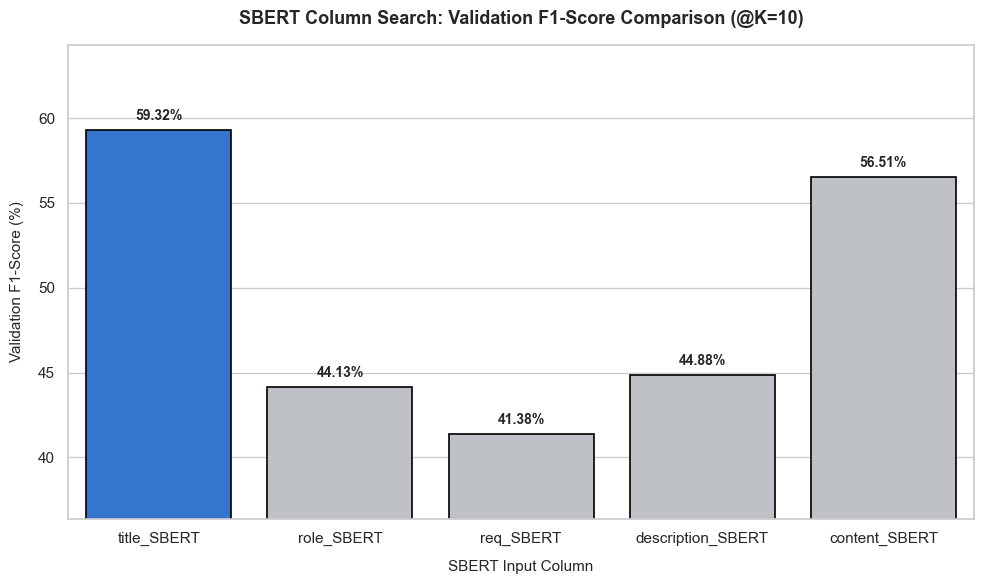

In [ ]:
col_df = pd.DataFrame(col_results)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

colors = ['#1a73e8' if c == best_sbert_col else '#bdc1c6' for c in col_df['column']]

ax = sns.barplot(
    data=col_df,
    x='column',
    y='F1',
    palette=colors,
    edgecolor='black',
    linewidth=1.2
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        weight='bold',
        fontsize=10
    )

plt.title('SBERT Column Search: Validation F1-Score Comparison (@K=10)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('SBERT Input Column', fontsize=11, labelpad=10)
plt.ylabel('Validation F1-Score (%)', fontsize=11, labelpad=10)

f1_min = col_df['F1'].min()
f1_max = col_df['F1'].max()
plt.ylim(max(0, f1_min - 5), min(100, f1_max + 5))
plt.tight_layout()
plt.show()

In [ ]:
neighbor_space = [1, 3, 5, 8, 10, 15]
skill_k_space = [5, 10, 15, 20, 25, 30]
joint_results = []
col = best_sbert_col
max_n = max(neighbor_space)
max_k = max(skill_k_space)
print(f"Starting Joint Tuning for SBERT using Column: '{col}'...")
predictions_dict = { (n, k): [] for n in neighbor_space for k in skill_k_space }
y_true_val = []
for i in range(len(val_df)):
    y_true_val.append(val_df.iloc[i]['skills_required'])
    query_emb = val_embs_dict[col][i]
    cos_scores = util.cos_sim(query_emb, train_embs_dict[col])[0]
    top_indices_max = torch.topk(cos_scores, k=max_n).indices.cpu().numpy()
    for top_n in neighbor_space:
        top_idx = top_indices_max[:top_n]
        skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
        most_common_skills = [s for s, _ in Counter(skills).most_common(max_k)]
        for k in skill_k_space:
            predictions_dict[(top_n, k)].append(most_common_skills[:k])
for top_n in neighbor_space:
    for k in skill_k_space:
        current_f1 = f1_at_k(y_true_val, predictions_dict[(top_n, k)], k=k)
        joint_results.append({'top_n': top_n,'top_k': k,'F1': current_f1})
tuning_df = pd.DataFrame(joint_results)
best_row = tuning_df.loc[tuning_df['F1'].idxmax()]
best_sbert_N = int(best_row['top_n'])
best_sbert_top_k = int(best_row['top_k'])
best_f1 = best_row['F1']
print("\nBest SBERT Hyperparameters Found overall:")
print("="*55)
print(f"   Best Retrieved Neighbors (Top-N): {best_sbert_N}")
print(f"   Best Recommended Skills (Top-K) : {best_sbert_top_k}")
print(f"   Optimal Validation F1-Score     : {best_f1:.2f}%")
print("="*55 + "\n")

Starting Joint Tuning for SBERT using Column: 'title_SBERT'...

Best SBERT Hyperparameters Found overall:
   Best Retrieved Neighbors (Top-N): 5
   Best Recommended Skills (Top-K) : 20
   Optimal Validation F1-Score     : 85.83%



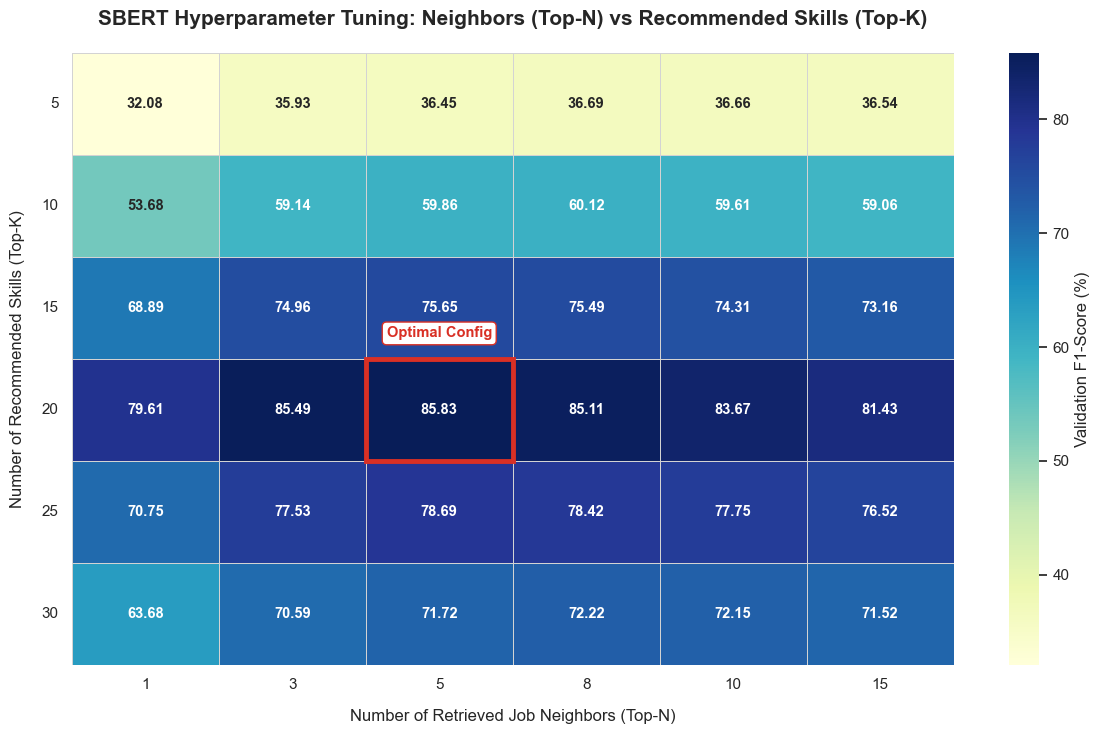

In [ ]:
heatmap_data = tuning_df.pivot(index='top_k', columns='top_n', values='F1')
heatmap_data = heatmap_data.sort_index(ascending=True)
sns.set_theme(style="white")
plt.figure(figsize=(12, 7.5))
ax = sns.heatmap(heatmap_data,annot=True,fmt=".2f",cmap="YlGnBu",cbar_kws={'label': 'Validation F1-Score (%)'},linewidths=0.5,linecolor='lightgray',annot_kws={'size': 10.5, 'weight': 'bold'})
max_val = heatmap_data.values.max()
max_loc = np.argwhere(heatmap_data.values == max_val)[0]  # [row_idx, col_idx]
best_row_idx = max_loc[0]
best_col_idx = max_loc[1]
ax.add_patch(Rectangle((best_col_idx, best_row_idx),1,1,fill=False,edgecolor='#d93025',lw=3.5,zorder=10))
ax.text(
    best_col_idx + 0.5,
    best_row_idx - 0.25 if best_row_idx > 0 else best_row_idx + 1.25,
    "Optimal Config",
    color='#d93025',
    weight='bold',
    fontsize=10.5,
    ha='center',
    va='center',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d93025", lw=1)
)
plt.title('SBERT Hyperparameter Tuning: Neighbors (Top-N) vs Recommended Skills (Top-K)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Retrieved Job Neighbors (Top-N)', fontsize=12, labelpad=12)
plt.ylabel('Number of Recommended Skills (Top-K)', fontsize=12, labelpad=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save SBERT basline JOBLIB

In [ ]:
save_dir = "saved_models_sbert"
os.makedirs(save_dir, exist_ok=True)
sbert_baseline_data = {"best_sbert_col": "title_SBERT","best_sbert_N": 5,"best_sbert_top_k": 20               }
model_path = os.path.join(save_dir, "sbert_baseline_best_params.joblib")
joblib.dump(sbert_baseline_data, model_path)

print(f"SBERT Baseline parameters successfully saved to: {model_path}")

SBERT Baseline parameters successfully saved to: saved_models_sbert\sbert_baseline_best_params.joblib


## Evaluate on Test Set

In [ ]:
process = psutil.Process()
start_time_sbert = time.time()
start_ram_sbert = process.memory_info().rss / (1024 * 1024)

final_sbert_col = best_sbert_col
final_sbert_N = best_sbert_N
final_sbert_top_k = best_sbert_top_k

print(f"Starting Final Evaluation for SBERT (E5) on Test Set...")
print(f"Using Config: Column='{final_sbert_col}', Neighbors_N={final_sbert_N}, Skills_K={final_sbert_top_k}")

y_true_sbert = test_df['skills_required'].tolist()
y_pred_sbert = []

for i in range(len(test_df)):
    query_emb = test_embs_dict[final_sbert_col][i]
    cos_scores = util.cos_sim(query_emb, train_embs_dict[final_sbert_col])[0]
    top_indices = torch.topk(cos_scores, k=final_sbert_N).indices.cpu().numpy()
    retrieved_skills = [s for slist in train_df.iloc[top_indices]['skills_required'] for s in slist]
    top_skills = [s for s, _ in Counter(retrieved_skills).most_common(final_sbert_top_k)]
    y_pred_sbert.append(top_skills)
f1_sbert        = f1_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)
precision_sbert = precision_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)
recall_sbert    = recall_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)
ndcg_sbert      = ndcg_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)
mrr_sbert       = mrr_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)

all_skills_sbert = list(set([s for sub in y_true_sbert for s in sub] + [s for sub in y_pred_sbert for s in sub]))
mlb_sbert = MultiLabelBinarizer(classes=all_skills_sbert).fit(all_skills_sbert)
eval_results_sbert = {
    f'F1@{final_sbert_top_k}': f1_sbert,
    f'Precision@{final_sbert_top_k}': precision_sbert,
    f'Recall@{final_sbert_top_k}': recall_sbert,
    f'NDCG@{final_sbert_top_k}': ndcg_sbert
}

print(f"\n{'='*40}")
print(f"   FINAL SBERT BASELINE PERFORMANCE (@{final_sbert_top_k})")
print(f"{'='*40}")
for metric, value in eval_results_sbert.items():
    unit = "%" if "@" in metric or "MRR" in metric or "Hit" in metric else ""
    print(f"{metric:18} : {value:.4f}{unit}")
print(f"{'='*40}")

Starting Final Evaluation for SBERT (E5) on Test Set...
Using Config: Column='title_SBERT', Neighbors_N=5, Skills_K=20

   FINAL SBERT BASELINE PERFORMANCE (@20)
F1@20              : 82.4723%
Precision@20       : 82.4351%
Recall@20          : 82.5926%
NDCG@20            : 84.5565%


# SBERT + XGBoost Ensemble

In [ ]:
def calculate_relevance(true_skills, pred_skills):
    if not true_skills or not pred_skills:
        return 0.0
    set_true = set(true_skills)
    set_pred = set(pred_skills)
    intersection = len(set_true.intersection(set_pred))
    union = len(set_true.union(set_pred))
    return intersection / union if union > 0 else 0.0

In [ ]:
def prepare_sbert_ensemble_data(query_df, corpus_df, query_embs, train_embs, num_candidates=100):
    X, y, groups = [], [], []
    print(f"Extracting SBERT Ensemble features for {len(query_df)} queries...")

    sim_matrix = util.cos_sim(query_embs, train_embs).cpu().numpy()

    for i, (q_idx, q_row) in enumerate(query_df.iterrows()):
        scores = sim_matrix[i].copy()
        if q_idx < len(corpus_df): scores[q_idx] = -1.0

        candidate_indices = np.argsort(scores)[::-1][:num_candidates]

        q_tokens = light_clean_text_SBERT(q_row['job_title']).split()
        f_sl = len(q_tokens)
        q_words = set(q_tokens)

        for rank, idx in enumerate(candidate_indices):
            c_row = corpus_df.iloc[idx]
            c_tokens = c_row['title_SBERT'].split()

            f_semantic = scores[idx]
            f_rank = rank + 1
            f_overlap = len(q_words.intersection(set(c_tokens)))
            f_tl = len(c_tokens)
            f_sk = len(c_row['skills_required'])

            X.append([f_semantic, f_rank, f_overlap, f_tl, f_sk, f_sl])

            js = calculate_relevance(q_row['skills_required'], c_row['skills_required'])
            y.append(int(js * 10))

        groups.append(num_candidates)
    return np.array(X), np.array(y), groups

In [ ]:
train_embs_sbert_ensemble = train_embs_dict[final_sbert_col]
val_embs_sbert_ensemble   = val_embs_dict[final_sbert_col]

X_train_sbert_ensemble, y_train_sbert_ensemble, g_train_sbert_ensemble = prepare_sbert_ensemble_data(train_df, train_df, train_embs_sbert_ensemble, train_embs_sbert_ensemble)
X_val_sbert_ensemble, y_val_sbert_ensemble, g_val_sbert_ensemble = prepare_sbert_ensemble_data(val_df, train_df, val_embs_sbert_ensemble, train_embs_sbert_ensemble)

Extracting SBERT Ensemble features for 6467 queries...
Extracting SBERT Ensemble features for 808 queries...


In [ ]:
X_train_sbe, y_train_sbe, g_train_sbe = prepare_sbert_ensemble_data(train_df, train_df, train_embs_sbert_ensemble, train_embs_sbert_ensemble)
X_test_sbe, _, _ = prepare_sbert_ensemble_data(test_df, train_df, test_embs_dict[final_sbert_col], train_embs_sbert_ensemble)

Extracting SBERT Ensemble features for 6467 queries...
Extracting SBERT Ensemble features for 809 queries...


In [ ]:
xgb_sbert_ensemble = xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    n_jobs=6
)

xgb_sbert_ensemble.fit(X_train_sbe, y_train_sbe, group=g_train_sbe)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'rank:ndcg'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from s

## Hypertuning

Tuning Aggregation K for SBERT + XGBoost Ensemble...
Aggregation K= 4 | Val F1: 85.15%
Aggregation K= 5 | Val F1: 85.20%
Aggregation K= 8 | Val F1: 85.17%
Aggregation K=10 | Val F1: 83.90%

 Best Aggregation K for SBERT + XGBoost is: 5 (Val F1: 85.20%)


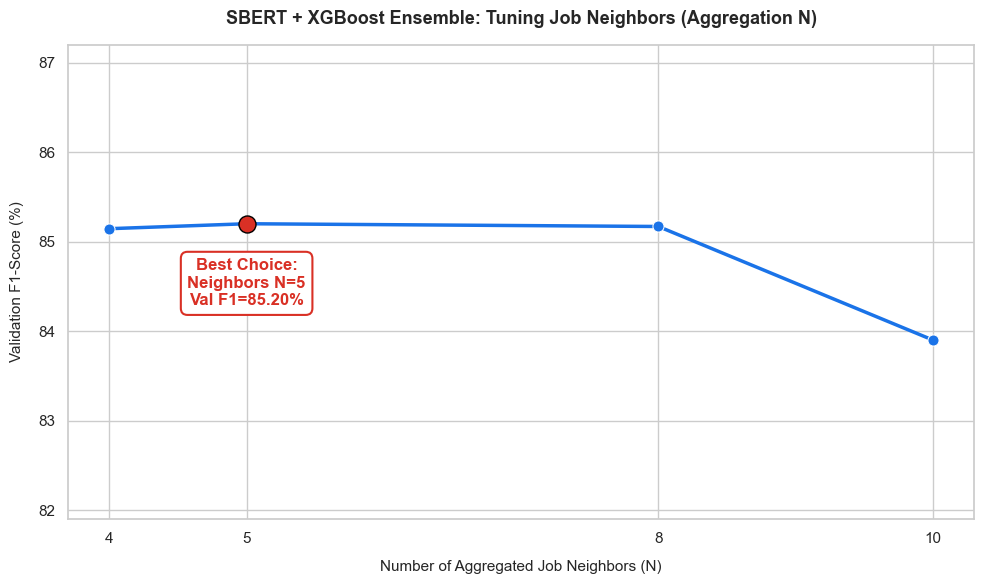

In [ ]:
print("Tuning Aggregation K for SBERT + XGBoost Ensemble...")

best_xgb_k = 0
max_xgb_f1 = -1
results_list = []

sim_matrix_val = util.cos_sim(val_embs_sbert_ensemble, train_embs_sbert_ensemble).cpu().numpy()

for k_val in [4, 5, 8, 10]:
    y_pred_tmp = []
    y_true_val = val_df['skills_required'].tolist()

    for i in range(len(val_df)):
        query_feats = X_val_sbert_ensemble[i*100 : (i+1)*100]
        scores = xgb_sbert_ensemble.predict(query_feats)

        q_sim = sim_matrix_val[i].copy()
        if i < len(train_df) and val_df.index[i] in train_df.index:
            q_sim[i] = -1.0
        candidate_indices = np.argsort(q_sim)[::-1][:100]

        top_k_idx = np.argsort(scores)[::-1][:k_val]
        final_top_indices = candidate_indices[top_k_idx]

        skills = [s for slist in train_df.iloc[final_top_indices]['skills_required'] for s in slist]
        y_pred_tmp.append([s for s, _ in Counter(skills).most_common(20)])

    current_f1 = f1_at_k(y_true_val, y_pred_tmp, k=20)
    print(f"Aggregation K={k_val:2} | Val F1: {current_f1:.2f}%")

    results_list.append({
        'k_val': k_val,
        'F1': current_f1
    })

    if current_f1 > max_xgb_f1:
        max_xgb_f1 = current_f1
        best_xgb_k = k_val

print(f"\n Best Aggregation K for SBERT + XGBoost is: {best_xgb_k} (Val F1: {max_xgb_f1:.2f}%)")

results_df = pd.DataFrame(results_list)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df,x='k_val',y='F1',marker='o',linewidth=2.5,markersize=8,color='#1a73e8')
plt.scatter(best_xgb_k, max_xgb_f1, color='#d93025', s=150, zorder=5, edgecolor='black')
plt.annotate(
    f"Best Choice:\nNeighbors N={best_xgb_k}\nVal F1={max_xgb_f1:.2f}%",
    (best_xgb_k, max_xgb_f1),
    textcoords="offset points",
    xytext=(0, -25),
    ha='center',
    va='top',
    color='#d93025',
    weight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5)
)
plt.title('SBERT + XGBoost Ensemble: Tuning Job Neighbors (Aggregation N)', fontsize=13, fontweight='bold',
pad=15)
plt.xlabel('Number of Aggregated Job Neighbors (N)', fontsize=11, labelpad=10)
plt.ylabel('Validation F1-Score (%)', fontsize=11, labelpad=10)
plt.xticks([4, 5, 8, 10])

f1_min = results_df['F1'].min()
f1_max = results_df['F1'].max()
plt.ylim(max(0, f1_min - 2), min(100, f1_max + 2))
plt.tight_layout()
plt.show()

Starting XGBoost Grid Search on 808 queries over 48 combinations...
Using Optimal Aggregation Neighbors K = 5
Params: n_est= 50, depth=3, lr=0.01 | Val F1:84.81%
Params: n_est= 50, depth=3, lr=0.05 | Val F1:84.73%
Params: n_est= 50, depth=3, lr=0.10 | Val F1:84.76%
Params: n_est= 50, depth=4, lr=0.01 | Val F1:84.76%
Params: n_est= 50, depth=4, lr=0.05 | Val F1:84.61%
Params: n_est= 50, depth=4, lr=0.10 | Val F1:84.95%
Params: n_est= 50, depth=5, lr=0.01 | Val F1:84.76%
Params: n_est= 50, depth=5, lr=0.05 | Val F1:85.55%
Params: n_est= 50, depth=5, lr=0.10 | Val F1:85.82%
Params: n_est= 50, depth=6, lr=0.01 | Val F1:85.25%
Params: n_est= 50, depth=6, lr=0.05 | Val F1:85.12%
Params: n_est= 50, depth=6, lr=0.10 | Val F1:85.82%
Params: n_est=100, depth=3, lr=0.01 | Val F1:84.80%
Params: n_est=100, depth=3, lr=0.05 | Val F1:84.67%
Params: n_est=100, depth=3, lr=0.10 | Val F1:84.80%
Params: n_est=100, depth=4, lr=0.01 | Val F1:84.75%
Params: n_est=100, depth=4, lr=0.05 | Val F1:84.81%
Params

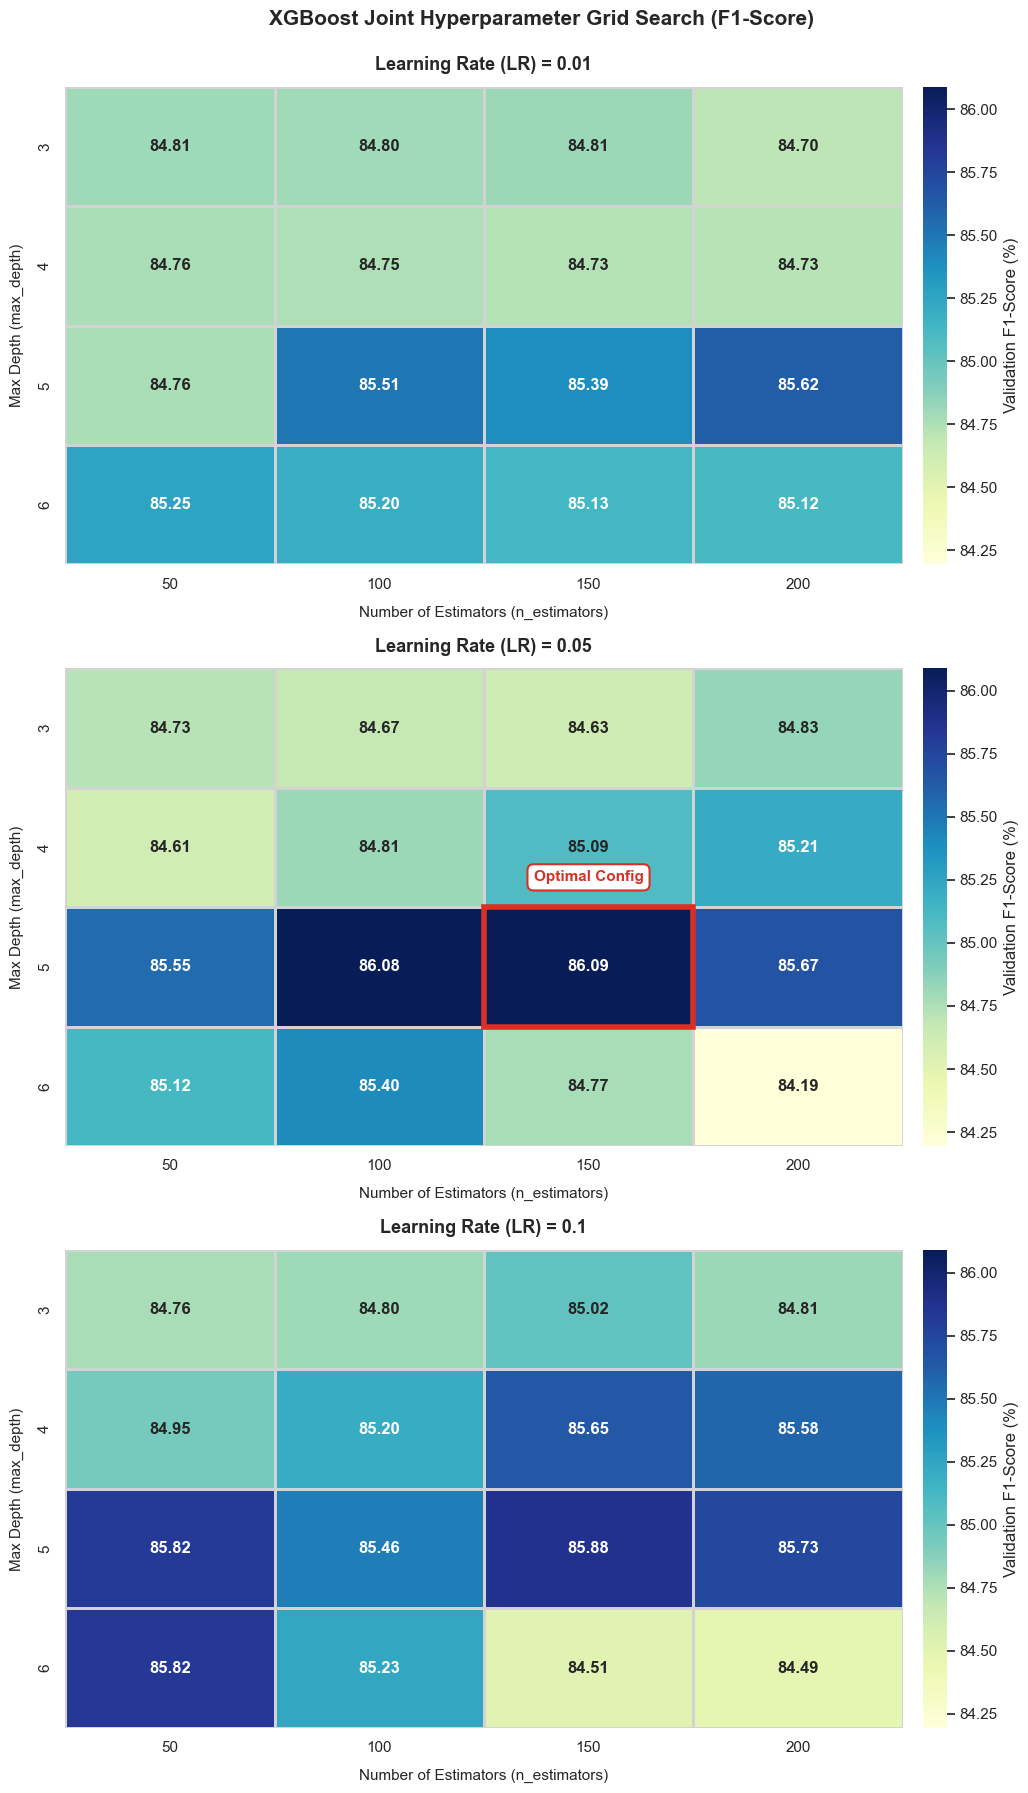

In [ ]:
n_estimators_space = [50, 100, 150, 200]
max_depth_space = [3, 4, 5, 6]
learning_rate_space = [0.01, 0.05, 0.1]

xgb_grid = [
    {'n_estimators': n, 'max_depth': d, 'lr': lr}
    for n, d, lr in itertools.product(n_estimators_space, max_depth_space, learning_rate_space)
]

best_xgb_f1 = -1
best_xgb_params = {}
xgb_grid_results = []

print(f"Starting XGBoost Grid Search on {len(val_df)} queries over {len(xgb_grid)} combinations...")
print(f"Using Optimal Aggregation Neighbors K = {best_xgb_k}")

sim_matrix_val = util.cos_sim(val_embs_sbert_ensemble, train_embs_sbert_ensemble).cpu().numpy()

for params in xgb_grid:
    model = xgb.XGBRanker(
        tree_method="hist",
        objective="rank:ndcg",
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['lr'],
        random_state=42,
        n_jobs=6
    )
    model.fit(X_train_sbert_ensemble, y_train_sbert_ensemble, group=g_train_sbert_ensemble)

    y_pred_val = []
    y_true_val = val_df['skills_required'].tolist()

    for i in range(len(val_df)):
        q_feats = X_val_sbert_ensemble[i*100 : (i+1)*100]
        scores = model.predict(q_feats)
        q_sim = sim_matrix_val[i].copy()
        if i < len(train_df) and val_df.index[i] in train_df.index:
            q_sim[i] = -1.0
        cands = np.argsort(q_sim)[::-1][:100]
        top_idx = cands[np.argsort(scores)[::-1][:best_xgb_k]]
        skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
        y_pred_val.append([s for s, _ in Counter(skills).most_common(20)])
    current_f1 = f1_at_k(y_true_val, y_pred_val, k=20)
    print(f"Params: n_est={params['n_estimators']:3}, depth={params['max_depth']}, lr={params['lr']:.2f} | Val F1:{current_f1:.2f}%")

    xgb_grid_results.append({'n_estimators': params['n_estimators'],'max_depth': params['max_depth'],'learning_rate': params['lr'],'F1': current_f1})

    if current_f1 > best_xgb_f1:
        best_xgb_f1 = current_f1
        best_xgb_params = params
print(f"\n Best Sbert Ensemble Parameter: {best_xgb_params} with F1: {best_xgb_f1:.2f}%")

xgb_grid_df = pd.DataFrame(xgb_grid_results)
sns.set_theme(style="white")
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11, 18))

best_n = best_xgb_params['n_estimators']
best_depth = best_xgb_params['max_depth']
best_lr = best_xgb_params['lr']

vmin = xgb_grid_df['F1'].min()
vmax = xgb_grid_df['F1'].max()

for i, lr in enumerate(learning_rate_space):
    lr_df = xgb_grid_df[xgb_grid_df['learning_rate'] == lr]
    pivot_df = lr_df.pivot(index='max_depth', columns='n_estimators', values='F1')
    pivot_df = pivot_df.sort_index(ascending=True)
    ax = axes[i]
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={'label': 'Validation F1-Score (%)', 'pad': 0.02},
        linewidths=0.8,
        linecolor='lightgray',
        annot_kws={'size': 12, 'weight': 'bold'},
        ax=ax
    )
    ax.set_title(f"Learning Rate (LR) = {lr}", fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("Number of Estimators (n_estimators)", fontsize=11, labelpad=10)
    ax.set_ylabel("Max Depth (max_depth)", fontsize=11, labelpad=10)
    ax.tick_params(axis='x', labelbottom=True)

    if lr == best_lr:
        row_idx = list(pivot_df.index).index(best_depth)
        col_idx = list(pivot_df.columns).index(best_n)
        ax.add_patch(
            Rectangle(
                (col_idx, row_idx),
                1,
                1,
                fill=False,
                edgecolor='#d93025',
                lw=4.0,
                zorder=10
            )
        )
        ax.text(
            col_idx + 0.5,
            row_idx - 0.25 if row_idx > 0 else row_idx + 1.25,
            "Optimal Config",
            color='#d93025',
            weight='bold',
            fontsize=11,
            ha='center',
            va='center',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5)
        )
plt.suptitle('XGBoost Joint Hyperparameter Grid Search (F1-Score)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
xgb_sbert_ensemble = xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    n_estimators=best_xgb_params['n_estimators'],
    max_depth=best_xgb_params['max_depth'],
    learning_rate=best_xgb_params['lr'],
    random_state=42,
    n_jobs=6
)
xgb_sbert_ensemble.fit(X_train_sbert_ensemble, y_train_sbert_ensemble, group=g_train_sbert_ensemble)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'rank:ndcg'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from s

# Save Joblib SBERT Ensemble

In [ ]:
save_dir = "saved_models_sbert"
os.makedirs(save_dir, exist_ok=True)

sbert_xgb_package = {
    "xgb_model": xgb_sbert_ensemble,
    "best_sbert_col": best_sbert_col,
    "best_xgb_k": best_xgb_k,
    "best_sbert_top_k": best_sbert_top_k,
    "best_xgb_params": {
        "n_estimators": 150,
        "max_depth": 5,
        "learning_rate": 0.05
    }
}

model_path = os.path.join(save_dir, "sbert_xgb_ensemble_careers.joblib")
joblib.dump(sbert_xgb_package, model_path)

print(f"SBERT + XGBoost Ensemble package successfully saved to: {model_path}")

SBERT + XGBoost Ensemble package successfully saved to: saved_models_sbert\sbert_xgb_ensemble_careers.joblib


## Evaluate on Test Set

In [ ]:
process = psutil.Process()
start_time_final = time.time()
start_ram_final = process.memory_info().rss / (1024 * 1024)

y_pred_final = []
y_true_final = test_df['skills_required'].tolist()

sim_matrix_test = util.cos_sim(test_embs_dict[final_sbert_col], train_embs_sbert_ensemble).cpu().numpy()

print(f"Final Test Evaluation (Neighbors N={best_xgb_k}, Skills K={best_sbert_top_k})...")
for i in range(len(test_df)):
    q_feats = X_test_sbe[i*100 : (i+1)*100]
    scores = xgb_sbert_ensemble.predict(q_feats)
    q_sim = sim_matrix_test[i].copy()
    if i < len(train_df) and test_df.index[i] in train_df.index:
        q_sim[i] = -1.0
    candidates = np.argsort(q_sim)[::-1][:100]
    top_pos = candidates[np.argsort(scores)[::-1][:best_xgb_k]]
    skills = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_final.append([s for s, _ in Counter(skills).most_common(best_sbert_top_k)])
duration_final = time.time() - start_time_final

all_skills = list(set([s for sub in y_true_final for s in sub] + [s for sub in y_pred_final for s in sub]))
mlb = MultiLabelBinarizer(classes=all_skills).fit(all_skills)

eval_results_sbert_ensemble = {
    f'F1@{best_sbert_top_k}': f1_at_k(y_true_final, y_pred_final, k=best_sbert_top_k),
    f'NDCG@{best_sbert_top_k}': ndcg_at_k(y_true_final, y_pred_final, k=best_sbert_top_k),
    f'Precision@{best_sbert_top_k}': precision_at_k(y_true_final, y_pred_final, k=best_sbert_top_k),
    f'Recall@{best_sbert_top_k}': recall_at_k(y_true_final, y_pred_final, k=best_sbert_top_k),
    'Time (s)': duration_final,
}
print("\n" + "="*55)
print(pd.DataFrame(list(eval_results_sbert_ensemble.items()), columns=['Metric', 'Result']).
to_string(index=False))
print("="*55)

Final Test Evaluation (Neighbors N=5, Skills K=20)...

      Metric  Result
       F1@20   82.62
     NDCG@20   84.69
Precision@20   82.58
   Recall@20   82.75
    Time (s)    1.00


# BPR Baseline

In [ ]:
print("Building ID mappings...")
all_skills_list = list(set([s for slist in pd.concat([train_df, val_df, test_df])['skills_required'] for s in slist]))
skill_to_id = {skill: i for i, skill in enumerate(all_skills_list)}
id_to_skill = {i: skill for skill, i in skill_to_id.items()}

Building ID mappings...


In [ ]:
all_train_job_ids = train_df['job_id'].unique()
job_to_idx = {jid: i for i, jid in enumerate(all_train_job_ids)}

In [ ]:
rows, cols, data = [], [], []
for j, (i, row) in enumerate(train_df.iterrows()):
    j_idx = job_to_idx[row['job_id']]
    for s in row['skills_required']:
        if s in skill_to_id:
            rows.append(j_idx)
            cols.append(skill_to_id[s])
            data.append(1)
train_matrix_bpr = csr_matrix((data, (rows, cols)), shape=(len(all_train_job_ids), len(all_skills_list)))
print(f"Matrix Built! Shape: {train_matrix_bpr.shape}")

Matrix Built! Shape: (6086, 1238)


## Hypertuning

Starting Joint BPR Tuning (Input Fields + BPR Factors + Neighbors N + Recommended Skills K)...
New Record! Col: cleaned_title   | Factors:  16 | Neighbors N:  5 | Skills K:  5 | Val F1: 35.30%
New Record! Col: cleaned_title   | Factors:  16 | Neighbors N:  5 | Skills K: 10 | Val F1: 54.46%
New Record! Col: cleaned_title   | Factors:  16 | Neighbors N:  5 | Skills K: 15 | Val F1: 64.72%
New Record! Col: cleaned_title   | Factors:  16 | Neighbors N:  5 | Skills K: 20 | Val F1: 66.16%
New Record! Col: cleaned_title   | Factors:  32 | Neighbors N:  5 | Skills K: 20 | Val F1: 66.75%

Best BPR Hyperparameters Found overall:
   Best Input Column (column)      : 'cleaned_title'
   Best Latent Factors (factors)   : 32
   Best Neighbors Num (neighbor_n) : 5
   Best Recommended Skills (top_k) : 20
   Optimal Validation F1-Score     : 66.75%



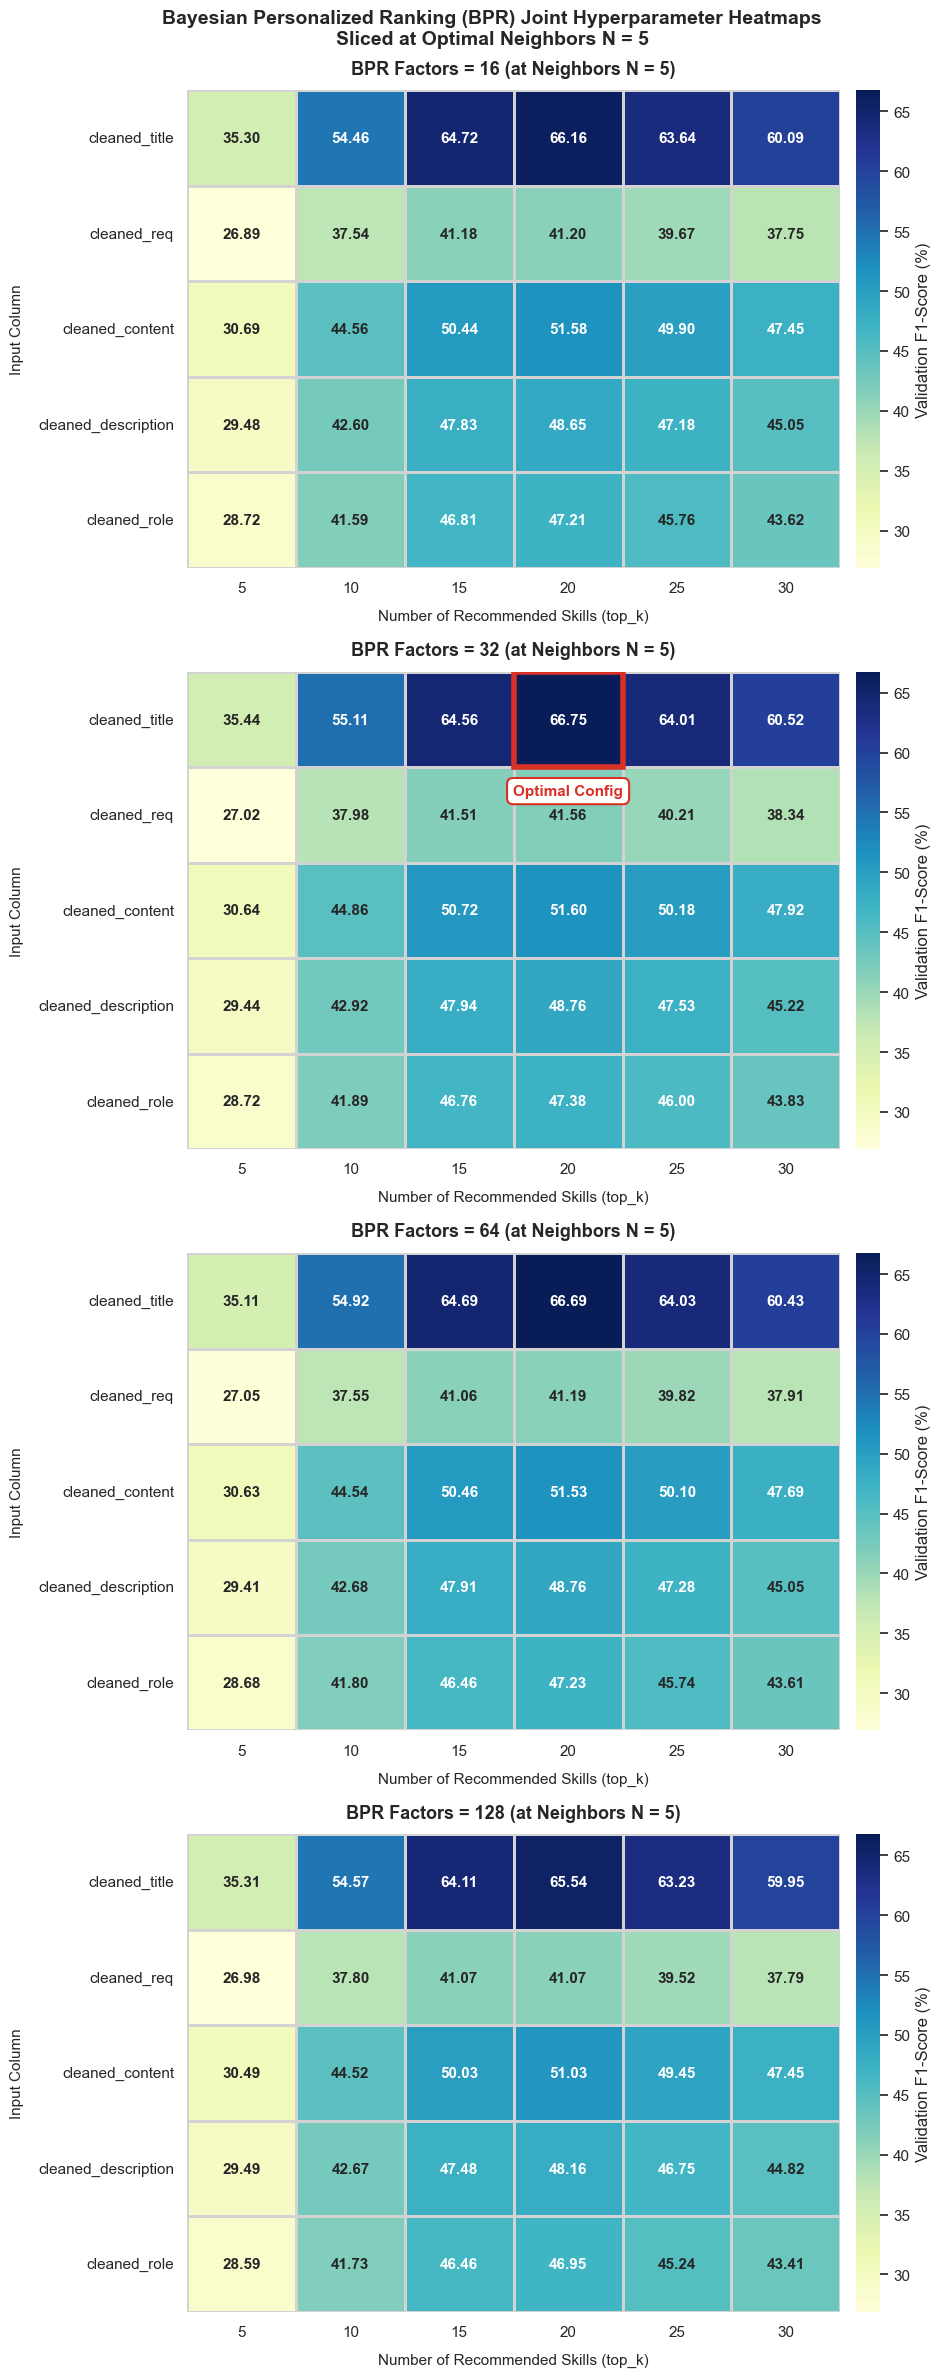

In [ ]:
train_df_unique = train_df.drop_duplicates(subset='job_id')

columns_to_test = ['cleaned_title', 'cleaned_req', 'cleaned_content', 'cleaned_description', 'cleaned_role']
factors_space = [16, 32, 64, 128]
neighbor_space = [5, 10, 20, 30]
skill_k_space = [5, 10, 15, 20, 25, 30]
iters = 100

best_total_f1 = -1
best_config = {}
bpr_tuning_results = []

max_n = max(neighbor_space)
max_k = max(skill_k_space)

print("Starting Joint BPR Tuning (Input Fields + BPR Factors + Neighbors N + Recommended Skills K)...")

for factors in factors_space:
    model = implicit.bpr.BayesianPersonalizedRanking(factors=factors, iterations=iters, random_state=42)
    model.fit(train_matrix_bpr, show_progress=False)
    for col in columns_to_test:
        tfidf_vec = TfidfVectorizer(max_features=3000)
        train_tfidf = tfidf_vec.fit_transform(train_df_unique[col].fillna(''))
        val_tfidf = tfidf_vec.transform(val_df[col].fillna(''))
        sim_matrix = cosine_similarity(val_tfidf, train_tfidf)
        predictions_dict = { (n, k): [] for n in neighbor_space for k in skill_k_space }
        y_true_val = val_df['skills_required'].tolist()
        for i in range(len(val_df)):
            top_indices_max = np.argsort(sim_matrix[i])[::-1][:max_n]
            for N in neighbor_space:
                neighbor_indices = top_indices_max[:N]
                avg_factor = np.mean(model.user_factors[neighbor_indices], axis=0)
                scores = avg_factor.dot(model.item_factors.T)
                ids = np.argsort(scores)[::-1][:max_k]
                skills_list = [id_to_skill[idx] for idx in ids]
                for k in skill_k_space:
                    predictions_dict[(N, k)].append(skills_list[:k])
        for N in neighbor_space:
            for k in skill_k_space:
                current_f1 = f1_at_k(y_true_val, predictions_dict[(N, k)], k=k)
                bpr_tuning_results.append({'column': col,'factors': factors,'neighbor_n': N,'skill_k': k,'F1': current_f1})

                if current_f1 > best_total_f1:
                    best_total_f1 = current_f1
                    best_config = {'column': col, 'factors': factors, 'neighbor_n': N, 'top_k': k,'iters': iters}
                    print(f"New Record! Col: {col:15} | Factors: {factors:3} | Neighbors N: {N:2} | Skills K: {k:2} | Val F1: {current_f1:.2f}%")
print("\nBest BPR Hyperparameters Found overall:")
print("="*55)
print(f"   Best Input Column (column)      : '{best_config['column']}'")
print(f"   Best Latent Factors (factors)   : {best_config['factors']}")
print(f"   Best Neighbors Num (neighbor_n) : {best_config['neighbor_n']}")
print(f"   Best Recommended Skills (top_k) : {best_config['top_k']}")
print(f"   Optimal Validation F1-Score     : {best_total_f1:.2f}%")
print("="*55 + "\n")

bpr_tuning_df = pd.DataFrame(bpr_tuning_results)
sns.set_theme(style="white")
num_factors = len(factors_space)
fig, axes = plt.subplots(num_factors, 1, figsize=(10, 6 * num_factors))
best_col = best_config['column']
best_factors = best_config['factors']
best_k = best_config['top_k']
best_neighbor_n = best_config['neighbor_n']
plot_df_filtered = bpr_tuning_df[bpr_tuning_df['neighbor_n'] == best_neighbor_n]

vmin = plot_df_filtered['F1'].min()
vmax = plot_df_filtered['F1'].max()

for i, factors in enumerate(factors_space):
    f_df = plot_df_filtered[plot_df_filtered['factors'] == factors]
    pivot_df = f_df.pivot(index='column', columns='skill_k', values='F1')
    pivot_df = pivot_df.loc[columns_to_test]
    ax = axes[i] if num_factors > 1 else axes
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={'label': 'Validation F1-Score (%)', 'pad': 0.02},
        linewidths=0.8,
        linecolor='lightgray',
        annot_kws={'size': 11, 'weight': 'bold'},
        ax=ax
    )
    ax.set_title(f"BPR Factors = {factors} (at Neighbors N = {best_neighbor_n})", fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("Number of Recommended Skills (top_k)", fontsize=11, labelpad=10)
    ax.set_ylabel("Input Column", fontsize=11, labelpad=10)

    if factors == best_factors:
        row_idx = list(pivot_df.index).index(best_col)
        col_idx = list(pivot_df.columns).index(best_k)
        ax.add_patch(Rectangle((col_idx, row_idx),1,1,fill=False,edgecolor='#d93025',lw=4.0,zorder=10))
        ax.text(
            col_idx + 0.5,
            row_idx - 0.25 if row_idx > 0 else row_idx + 1.25,
            "Optimal Config",
            color='#d93025',
            weight='bold',
            fontsize=11,
            ha='center',
            va='center',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5)
        )
plt.suptitle(f'Bayesian Personalized Ranking (BPR) Joint Hyperparameter Heatmaps\nSliced at Optimal Neighbors N = {best_neighbor_n}', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

## Evaluation Using Test Set

In [ ]:
def format_bpr_val(row):
        return f"{row['Value']:.2f}%"

train_df_unique = train_df.drop_duplicates(subset='job_id')
final_col = best_config['column']
final_factors = best_config['factors']
final_iters = best_config['iters']
final_top_k = best_config['top_k']

final_tfidf_vec = TfidfVectorizer(max_features=5000)
final_train_tfidf = final_tfidf_vec.fit_transform(train_df_unique[final_col].fillna(''))
final_test_tfidf = final_tfidf_vec.transform(test_df[final_col].fillna(''))

bpr_model_baseline = implicit.bpr.BayesianPersonalizedRanking(factors=final_factors, iterations=final_iters, random_state=42)
bpr_model_baseline.fit(train_matrix_bpr)

y_pred_bpr = []
y_true_bpr = test_df['skills_required'].tolist()
sim_matrix_test = cosine_similarity(final_test_tfidf, final_train_tfidf)

print(f"Final Evaluation on test_df using '{final_col}' (Factors={final_factors}, Skills K={final_top_k})...")

for i in range(len(test_df)):
    neighbors = np.argsort(sim_matrix_test[i])[::-1][:5]
    avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    ids = np.argsort(scores)[::-1][:final_top_k]
    y_pred_bpr.append([id_to_skill[idx] for idx in ids])

y_true_binary_test = mlb.transform(test_df['skills_required'])

eval_results_bpr_pure = {
    f'F1@{final_top_k}': f1_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'NDCG@{final_top_k}': ndcg_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'Precision@{final_top_k}': precision_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'Recall@{final_top_k}': recall_at_k(y_true_bpr, y_pred_bpr, k=final_top_k)
}

report_df_pure = pd.DataFrame(list(eval_results_bpr_pure.items()), columns=['Metric', 'Value'])
report_df_pure['Value'] = report_df_pure.apply(format_bpr_val, axis=1)

print("\n" + "="*45)
print(f"      FINAL PURE BPR REPORT (@K={final_top_k})")
print("="*45)
print(report_df_pure.to_string(index=False))
print("="*45)

100%|█████████████████████████████████████████████| 100/100 [00:00<00:00, 235.68it/s, train_auc=98.99%, skipped=13.38%]


Final Evaluation on test_df using 'cleaned_title' (Factors=32, Skills K=20)...

      FINAL PURE BPR REPORT (@K=20)
      Metric  Value
       F1@20 63.29%
     NDCG@20 70.28%
Precision@20 63.29%
   Recall@20 63.34%


# Save BPR Baseline Joblib

In [ ]:
save_dir = "saved_models_bpr_careers"
os.makedirs(save_dir, exist_ok=True)

bpr_model_data = {
    "bpr_model_baseline": bpr_model_baseline,
    "final_tfidf_vec": final_tfidf_vec,
    "final_train_tfidf": final_train_tfidf,
    "best_config": best_config
}

model_path = os.path.join(save_dir, "bpr_baseline_model_careers.joblib")
joblib.dump(bpr_model_data, model_path)

print(f"BPR Baseline package successfully saved from active memory to: {model_path}")

BPR Baseline package successfully saved from active memory to: saved_models_bpr_careers\bpr_baseline_model_careers.joblib


# BPR + LightGBM Ensemble

Calculating Skill-Skill Co-occurrence...
Precomputing skill TF-IDF vectors...
Done!
Training Factor Predictor (Text -> BPR Latent Factors)...
Factor Predictor Trained!
Generating ensemble training data...


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:22<00:00, 12.18it/s]



Training LGBMRanker...
LGBMRanker Trained successfully!
Reranker type confirmed: <class 'lightgbm.sklearn.LGBMRanker'>

Tuning K on val_df...


Validation Inference: 100%|██████████████████████████████████████████████████████████| 808/808 [01:41<00:00,  7.97it/s]


Skills K:  5 | Val F1: 34.73%
Skills K: 10 | Val F1: 57.30%
Skills K: 15 | Val F1: 72.39%
Skills K: 20 | Val F1: 81.89%
Skills K: 25 | Val F1: 75.72%
Skills K: 30 | Val F1: 69.69%

Best K: 20 (Val F1: 81.89%)


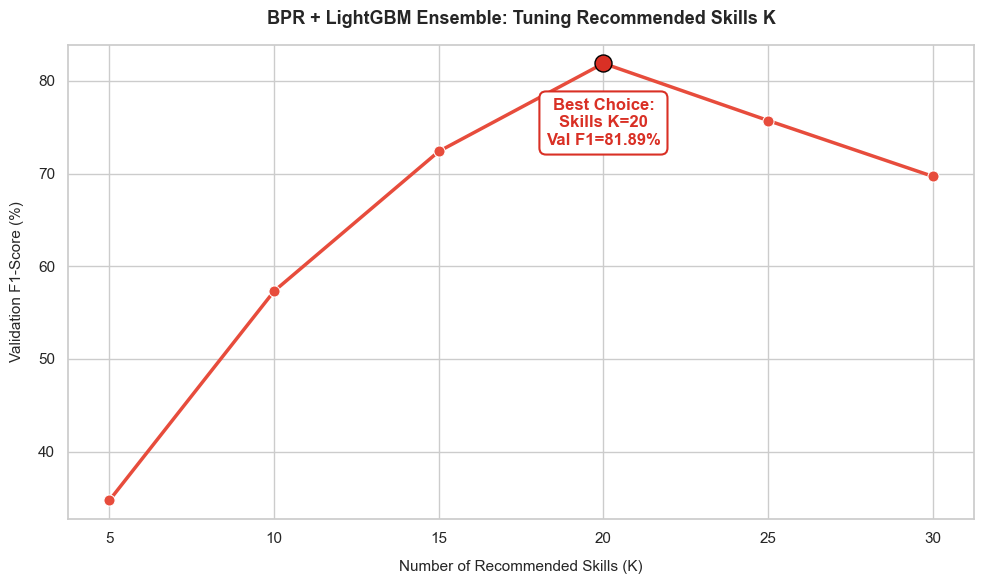

Starting Final Evaluation (K=20)...


100%|████████████████████████████████████████████████████████████████████████████████| 809/809 [01:45<00:00,  7.65it/s]


      PROPOSED BPR ENSEMBLE REPORT (@K=20)
        Metric    Value
         F1@20  74.2445
       NDCG@20  78.5268
  Precision@20  74.2583
     Recall@20  74.2873
      Time (s) 105.7806
RAM Usage (MB)   0.0000


In [ ]:
final_neighbor_n = best_config.get('neighbor_n', 5)

print("Calculating Skill-Skill Co-occurrence...")
cooc_matrix = train_matrix_bpr.T.dot(train_matrix_bpr)
cooc_matrix.data = np.log1p(cooc_matrix.data)
all_train_skills = [s for slist in train_df['skills_required'] for s in slist]
skill_counts = Counter(all_train_skills)
total_jobs = len(train_df_unique)

print("Precomputing skill TF-IDF vectors...")
all_skill_names = [id_to_skill[i] for i in range(len(id_to_skill))]
skill_name_tfidf = final_tfidf_vec.transform(all_skill_names)
print("Done!")

print("Training Factor Predictor (Text -> BPR Latent Factors)...")
X_train_text = final_train_tfidf
y_train_factors = bpr_model_baseline.user_factors
factor_regressor = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
factor_regressor.fit(X_train_text, y_train_factors)
print("Factor Predictor Trained!")

def extract_hybrid_features(candidate_ids, bpr_scores, neighbor_skill_counts=None, q_tfidf=None):
    feats = []
    top_5_ids = candidate_ids[:5]
    top_10_ids = set(candidate_ids[:10])
    scores_arr = np.array([bpr_scores[s] for s in candidate_ids])
    score_min, score_max = scores_arr.min(), scores_arr.max()
    score_range = score_max - score_min if score_max != score_min else 1.0
    score_mean = scores_arr.mean()

    for rank, s_idx in enumerate(candidate_ids):
        f_score = bpr_scores[s_idx]
        f_rank = 1.0 / (rank + 1)
        s_name = id_to_skill[s_idx]
        f_pop = skill_counts.get(s_name, 0) / total_jobs
        others = [idx for idx in top_5_ids if idx != s_idx]
        f_cooc = np.mean([cooc_matrix[s_idx, o_idx] for o_idx in others]) if others else 0
        f_neighbor_freq = (neighbor_skill_counts.get(s_name, 0) / 20.0) if neighbor_skill_counts else 0
        f_score_norm = (f_score - score_min) / score_range
        f_interaction = f_score_norm * f_rank
        if q_tfidf is not None:
            f_text_sim = cosine_similarity(q_tfidf, skill_name_tfidf[s_idx])[0][0]
        else:
            f_text_sim = 0.0
        skill_idx_in_vocab = final_tfidf_vec.vocabulary_.get(s_name.lower(), -1)
        f_idf = final_tfidf_vec.idf_[skill_idx_in_vocab] if skill_idx_in_vocab >= 0 else 0.0
        f_score_diff = f_score - score_mean
        f_top10_flag = 1.0 if s_idx in top_10_ids else 0.0

        feats.append([
            f_score, f_rank, f_pop, f_cooc, f_neighbor_freq,
            f_score_norm, f_interaction, f_text_sim, f_idf,
            f_score_diff, f_top10_flag
        ])
    return np.array(feats)
X_train_ens, y_train_ens = [], []
sample_jobs = train_df_unique.sample(n=min(1000, len(train_df_unique)), random_state=42)
print("Generating ensemble training data...")
for _, row in tqdm(sample_jobs.iterrows(), total=len(sample_jobs)):
    true_skills = set(row['skills_required'])
    q_tfidf = final_tfidf_vec.transform([row[final_col]])
    sims = cosine_similarity(q_tfidf, final_train_tfidf)[0]
    neighbors = np.argsort(sims)[::-1][:20]
    avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
    neighbor_skills_flat = [s for idx in neighbors for s in train_df_unique.iloc[idx]['skills_required']]
    neighbor_skill_counts = Counter(neighbor_skills_flat)
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    candidate_ids = np.argsort(scores)[::-1][:200]
    feats = extract_hybrid_features(candidate_ids, scores, neighbor_skill_counts, q_tfidf)
    X_train_ens.extend(feats)
    for s_idx in candidate_ids:
        y_train_ens.append(1 if id_to_skill[s_idx] in true_skills else 0)
X_train_rank = np.array(X_train_ens)
y_train_rank = np.array(y_train_ens)
groups_train = [200] * len(sample_jobs)

print("\nTraining LGBMRanker...")
rf_reranker = lgb.LGBMRanker(objective="rank_xendcg",metric="ndcg",n_estimators=500,num_leaves=63,learning_rate=0.01,importance_type='gain',random_state=42,n_jobs=-1)
rf_reranker.fit(X_train_rank, y_train_rank,group=groups_train,callbacks=[lgb.log_evaluation(period=50)])

print("LGBMRanker Trained successfully!")
print(f"Reranker type confirmed: {type(rf_reranker)}")

def recommend_bpr_ensemble_final(query_text, top_k=None):
    if top_k is None:
        top_k = best_ens_k if 'best_ens_k' in globals() else 20
    q_tfidf = final_tfidf_vec.transform([query_text])
    sims = cosine_similarity(q_tfidf, final_train_tfidf)[0]
    neighbors = np.argsort(sims)[::-1][:20]
    avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
    neighbor_skills_flat = [s for idx in neighbors for s in train_df_unique.iloc[idx]['skills_required']]
    neighbor_skill_counts = Counter(neighbor_skills_flat)
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    candidate_ids = np.argsort(scores)[::-1][:200]
    feats = extract_hybrid_features(candidate_ids, scores, neighbor_skill_counts, q_tfidf)
    scores_pred = rf_reranker.predict(feats)
    final_indices = np.argsort(scores_pred)[::-1][:top_k]
    return [id_to_skill[candidate_ids[idx]] for idx in final_indices]

print("\nTuning K on val_df...")
k_space = [5, 10, 15, 20, 25, 30]
best_ens_k, best_ens_f1 = 20, -1
ens_tuning_results = []
y_true_val = val_df['skills_required'].tolist()
y_pred_max = []
val_tfidf_temp = final_tfidf_vec.transform(val_df[final_col].fillna(''))
sim_matrix_val = cosine_similarity(val_tfidf_temp, final_train_tfidf)

for i in tqdm(range(len(val_df)), desc="Validation Inference"):
    q_tfidf = val_tfidf_temp[i]
    neighbors = np.argsort(sim_matrix_val[i])[::-1][:final_neighbor_n]
    avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
    neighbor_skills_flat = [s for idx in neighbors for s in train_df_unique.iloc[idx]['skills_required']]
    neighbor_skill_counts = Counter(neighbor_skills_flat)
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    candidate_ids = np.argsort(scores)[::-1][:200]
    feats = extract_hybrid_features(candidate_ids, scores, neighbor_skill_counts, q_tfidf)
    scores_pred = rf_reranker.predict(feats)
    sorted_indices = np.argsort(scores_pred)[::-1]
    y_pred_max.append([id_to_skill[candidate_ids[idx]] for idx in sorted_indices])

for k in k_space:
    y_pred_k = [pred[:k] for pred in y_pred_max]
    current_f1 = f1_at_k(y_true_val, y_pred_k, k=k)
    print(f"Skills K: {k:2} | Val F1: {current_f1:.2f}%")
    ens_tuning_results.append({'k': k, 'F1': current_f1})
    if current_f1 > best_ens_f1:
        best_ens_f1 = current_f1
        best_ens_k = k
print(f"\nBest K: {best_ens_k} (Val F1: {best_ens_f1:.2f}%)")

ens_tuning_df = pd.DataFrame(ens_tuning_results)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=ens_tuning_df, x='k', y='F1', marker='o', linewidth=2.5, markersize=8, color='#e74c3c')
plt.scatter(best_ens_k, best_ens_f1, color='#d93025', s=150, zorder=5, edgecolor='black')
plt.annotate(f"Best Choice:\nSkills K={best_ens_k}\nVal F1={best_ens_f1:.2f}%",
    (best_ens_k, best_ens_f1), textcoords="offset points", xytext=(0, -25),
    ha='center', va='top', color='#d93025', weight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5))
plt.title('BPR + LightGBM Ensemble: Tuning Recommended Skills K', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Recommended Skills (K)', fontsize=11, labelpad=10)
plt.ylabel('Validation F1-Score (%)', fontsize=11, labelpad=10)
plt.xticks(k_space)
f1_min, f1_max = ens_tuning_df['F1'].min(), ens_tuning_df['F1'].max()
plt.ylim(max(0, f1_min - 2), min(100, f1_max + 2))
plt.tight_layout()
plt.show()

process = psutil.Process()
start_time_final = time.time()
start_ram_final = process.memory_info().rss / (1024 * 1024)
y_pred_ens = []
y_true_ens = test_df['skills_required'].tolist()
print(f"Starting Final Evaluation (K={best_ens_k})...")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    y_pred_ens.append(recommend_bpr_ensemble_final(row[final_col], top_k=best_ens_k))
y_true_binary_test = mlb.transform(test_df['skills_required'])
eval_results_bpr_ensemble = {
    f'F1@{best_ens_k}': f1_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'NDCG@{best_ens_k}': ndcg_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'Precision@{best_ens_k}': precision_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'Recall@{best_ens_k}': recall_at_k(y_true_ens, y_pred_ens, k=best_ens_k)
}
duration_final = time.time() - start_time_final
ram_final = (process.memory_info().rss / (1024 * 1024)) - start_ram_final
eval_results_bpr_ensemble['Time (s)'] = duration_final
eval_results_bpr_ensemble['RAM Usage (MB)'] = ram_final

report_df = pd.DataFrame(list(eval_results_bpr_ensemble.items()), columns=['Metric', 'Value'])
def format_val(row):
    return f"{row['Value']:.4f}"
report_df['Value'] = report_df.apply(format_val, axis=1)
print("\n" + "="*45)
print(f"      PROPOSED BPR ENSEMBLE REPORT (@K={best_ens_k})")
print("="*45)
print(report_df.to_string(index=False))
print("="*45)

In [ ]:
save_dir = "saved_models_bpr_careers"
os.makedirs(save_dir, exist_ok=True)

bpr_ens_package = {
    "rf_reranker": rf_reranker,
    "bpr_model_baseline": bpr_model_baseline,
    "final_tfidf_vec": final_tfidf_vec,
    "final_train_tfidf": final_train_tfidf,
    "best_config": best_config,
    "best_ens_k": best_ens_k
}

model_path = os.path.join(save_dir, "bpr_lightgbm_ensemble_careers.joblib")
joblib.dump(bpr_ens_package, model_path)

print(f"BPR + LightGBM Ensemble package successfully saved from active memory to: {model_path}")

BPR + LightGBM Ensemble package successfully saved from active memory to: saved_models_bpr_careers\bpr_lightgbm_ensemble_careers.joblib


# Video Demo Purpose

In [ ]:
with open('mycareersfuture.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.json_normalize(data['jobs'])

del data

gc.collect()

print(f"Data import complete, current number of records: {len(df)}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.sample(5)

Data import complete, current number of records: 20298
Rows: 20,298
Columns: 16


,company_name,job_title,employment_type,seniority,job_category,location,salary,min_experience,skills_required,requirements_and_role,job_requirements,company_info,posting_date,expiry_date,no_of_applications,job_id
19312,FIDECO SERVICES PTE. LTD.,Software Developer (Java Developer / Full Stack Developer),Contract,Executive,[Information Technology],"TRADEHUB 21, 18 BOON LAY WAY 609966","$6,000to$8,500Monthly",5 years exp,"[.NET, Agile Methodologies, C, C#, C++, CSS, HTML, Java, JavaScript, jQuery, Linux, Microsoft SQ...",degree information technology engineering background minimum 5 9 years experience information te...,requirements performing end end software development cycle coding using java j2ee spring framewo...,No information added.,21 May 2019,20 Jun 2019,2,JOB-2019-0106588
15572,VALTECH DIGITAL SINGAPORE PTE. LTD.,Solutions Consultant,Full Time,Senior Executive,[Design],9A KEONG SAIK ROAD 089117,Salary undisclosed,5 years exp,"[Business Analysis, Business Development, Cloud Computing, CRM, Data Center, Enterprise Software...",solutions consultant translate client requirements functional technical designs implement custom...,requirements develop powerful features multi site multi channel delivery targeting content aggre...,VALTECH DIGITAL SINGAPORE PTE. LTD.\n,16 May 2019,15 Jun 2019,0,JOB-2019-0104409
2073,CLARIST RESOURCES PTE. LTD.,CRM Executive - RETAIL - S$4500,"Permanent, Full Time",Executive,"[Customer Service, Marketing , Public Relations]",not_available,"$3,000to$4,500Monthly",not_available,"[Account Management, Banking, Business Analysis, Business Development, CRM, Financial Services, ...",client role well known retailer invites dynamic committed individual join group crm executive bu...,requirements experience database management crm marketing prior retail experience would welcomed...,CLARIST RESOURCES PTE. LTD. Clarist Resources is an Executive and Professional Recruiter. We fo...,29 May 2019,28 Jun 2019,9,JOB-2019-0113562
2164,Company Undisclosed,Technical Accounting and Claims Handler,Permanent,"Professional, Executive","[Banking and Finance, Insurance]",not_available,"$6,000to$9,000Monthly",2 years exp,"[Automobile, B2B, Change Management, Claim, Claim Investigation, Claims Handling, Claims Managem...",regional team responsible providing technical accounting life non life business apac region seek...,requirements graduate finance accounting insurance business mathematics law etc least 2 3 years ...,not_available,17 May 2019,16 Jun 2019,6,JOB-2019-0105736
11474,ETH SINGAPORE SEC LTD.,Computer Scientist / Software Engineer for Cooling Singapore,"Contract, Full Time",Professional,"[Sciences , Laboratory , R&D]",not_available,"$6,000to$12,000Monthly",3 years exp,"[Agile Methodologies, Algorithms, Artificial Intelligence, C, C++, Cloud Computing, Computer Sci...",singapore centre sec established joint initiative swiss federal institute technology singapore n...,requirementsyou master degree computer science equivalent relevant background need comfortable w...,Singapore-ETH Centre (SEC) The Singapore-ETH Centre for Global Environmental Sustainability ...,17 May 2019,16 Jun 2019,2,JOB-2019-0080860


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def get_wordnet_pos(word):
    try:
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
        return tag_dict.get(tag, wordnet.NOUN)
    except: return wordnet.NOUN

def clean_job_title(title):
    if not isinstance(title, str): return ""
    title = re.sub(r'\[.*?\]|\(.*?\)', '', title)
    noise_patterns = r'\b(urgent|position|contract|months?|days?|nearest|mrt|salary|up to|senior|associate|avp)\b'
    title = re.sub(noise_patterns, '', title, flags=re.IGNORECASE)
    return title.strip().lower()

def deep_clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower().replace('&', ' and ')
    text = re.sub(r'[^a-z0-9\s+#.]', ' ', text)
    tokenizer = RegexpTokenizer(r'\w+[\+#]*|\.\w+')
    tokens = tokenizer.tokenize(text)
    corporate_noise = {'business', 'group', 'infrastructure', 'strategic', 'urgent', 'apply'}
    cleaned_tokens = [
        lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in tokens
        if (len(w) > 1 or w in {'r', 'c'}) and w not in stop_words and w not in corporate_noise and not w.isdigit()
    ]
    return " ".join(cleaned_tokens)

def light_clean_text_SBERT(text_SBERT):
    if not isinstance(text_SBERT, str): return ""
    text_SBERT = text_SBERT.lower()
    text_SBERT = re.sub(r'\[.*?\]', '', text_SBERT)
    text_SBERT = re.sub(r'\(.*?\)', '', text_SBERT)
    text_SBERT = re.sub(r'[^a-z0-9\s+#.]', ' ', text_SBERT)
    text_SBERT = re.sub(r'\s+', ' ', text_SBERT).strip()
    return text_SBERT

In [ ]:
df = pd.read_csv('mycareersfuture_CLEANED.csv')
df['skills_required'] = df['skills_required'].apply(ast.literal_eval)
df = df.fillna("")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.sample()

Rows: 18,610
Columns: 17


,job_id,job_title,job_category,cleaned_title,cleaned_role,cleaned_req,cleaned_description,cleaned_content,title_SBERT,role_SBERT,req_SBERT,description_SBERT,content_SBERT,skills_required,job_requirements,requirements_and_role,full_content
15468,JOB-2019-0112721,Senior Project Engineer,"['Engineering, Information Technology']",project engineer,ensure smooth operation daily site activity conflict resolution site progress monitoring support...,requirement minimum year work experience bachelor degree holder good communication skill ability...,ensure smooth operation daily site activity conflict resolution site progress monitoring support...,project engineer ensure smooth operation daily site activity conflict resolution site progress m...,senior project engineer,ensure smooth operation daily site activities conflicts resolution site progress monitoring supp...,requirements minimum 5 years working experience bachelor degree holder good communication skills...,ensure smooth operation daily site activities conflicts resolution site progress monitoring supp...,senior project engineer ensure smooth operation daily site activities conflicts resolution site ...,"[Construction, Continuous Improvement, Management, Civil Engineering, Project Engineering, Lean ...",requirements minimum 5 years working experience bachelor degree holder good communication skills...,ensure smooth operation daily site activities conflicts resolution site progress monitoring supp...,Senior Project Engineer ensure smooth operation daily site activities conflicts resolution site ...


In [ ]:
title_counts = df['cleaned_title'].value_counts()
valid_titles = title_counts[title_counts >= 5].index
df = df[df['cleaned_title'].isin(valid_titles)].reset_index(drop=True)
all_skills = df['skills_required'].explode()
all_skills = df['skills_required'].explode()
skill_counts = Counter(all_skills)
min_freq = 5
valid_skills = {s for s, c in skill_counts.items() if c >= min_freq}
df['skills_required'] = df['skills_required'].apply(lambda x: [s for s in x if s in valid_skills])
df['num_skills'] = df['skills_required'].apply(len)
df = df[df['num_skills'] > 0].reset_index(drop=True)
all_skills_filtered = df['skills_required'].explode()

print(f"Before filtering rare titles: {len(df)} rows")
print(f"Number of Unique Job Titles BEFORE: {df['cleaned_title'].nunique()}")
print('Number of unique skills before filtering:', all_skills.nunique())
print(f"After filtering rare titles:  {len(df)} rows")
print(f"Number of Unique Job Titles AFTER:  {len(valid_titles)}")
print('Number of unique skills after filtering:', all_skills_filtered.nunique())
print('Total job postings after removing empty skill lists:', len(df))

Before filtering rare titles: 8084 rows
Number of Unique Job Titles BEFORE: 488
Number of unique skills before filtering: 1679
After filtering rare titles:  8084 rows
Number of Unique Job Titles AFTER:  488
Number of unique skills after filtering: 1238
Total job postings after removing empty skill lists: 8084


In [ ]:
print("Skill Complexity Statistical Summary:")
print(df['skills_required'].apply(len).describe().apply(lambda x: f"{x:,.2f}" if x > 100 else f"{x:.2f}"))

Skill Complexity Statistical Summary:
count    8,084.00
mean        19.91
std          0.91
min          3.00
25%         20.00
50%         20.00
75%         20.00
max         48.00
Name: skills_required, dtype: str


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print(f"Train size:      {len(train_df)} (80%)")
print(f"Validation size: {len(val_df)} (10%)")
print(f"Test size:       {len(test_df)} (10%)")

Train size:      6467 (80%)
Validation size: 808 (10%)
Test size:       809 (10%)


In [ ]:
def recall_at_k(y_true, y_pred, k=20):
    scores = [len(set(t).intersection(p[:k]))/len(t) if len(t)>0 else 0 for t, p in zip(y_true, y_pred)]
    return np.mean(scores) * 100

def precision_at_k(y_true, y_pred, k=20):
    scores = [len(set(t).intersection(p[:k]))/k for t, p in zip(y_true, y_pred)]
    return np.mean(scores) * 100

def f1_at_k(y_true, y_pred, k=20):
    f1_scores = []
    for t, p in zip(y_true, y_pred):
        intersect = len(set(t).intersection(p[:k]))
        prec, rec = intersect/k, intersect/len(t) if len(t)>0 else 0
        f1_scores.append(2*prec*rec/(prec+rec) if (prec+rec)>0 else 0)
    return np.mean(f1_scores) * 100

def ndcg_at_k(y_true, y_pred, k=20):
    scores = []
    for t, p in zip(y_true, y_pred):
        t_set = set(t)
        dcg = sum([1/math.log2(i+2) for i, s in enumerate(p[:k]) if s in t_set])
        idcg = sum([1/math.log2(i+2) for i in range(min(len(t_set), k))])
        scores.append(dcg/idcg if idcg>0 else 0)
    return np.mean(scores) * 100

def mrr_at_k(y_true, y_pred, k=20):
    rr_scores = []
    for t, p in zip(y_true, y_pred):
        rr = 0.0
        for i, s in enumerate(p[:k]):
            if s in t: rr = 1/(i+1); break
        rr_scores.append(rr)
    return np.mean(rr_scores)

In [ ]:
loaded_bm25_pkg = joblib.load("saved_models/best_bm25_model_careers.joblib")

if isinstance(loaded_bm25_pkg, dict):
    best_bm25 = loaded_bm25_pkg["model"]
    best_config = loaded_bm25_pkg["best_config"]
    best_top_n = loaded_bm25_pkg["best_top_n"]
    best_top_k = loaded_bm25_pkg["best_top_k"]
else:
    print("Notice: Loaded old format model. Please re-run Cell 65 to update your saved file.")
    best_bm25 = loaded_bm25_pkg
    best_config = globals().get('best_config', {'column': 'cleaned_title', 'k1': 2.0, 'b': 0.75})
    best_top_n = globals().get('best_top_n', 10)
    best_top_k = globals().get('best_top_k', 20)
print("BM25 Baseline Model Package Loaded Successfully!")
print("=" * 55)
print("  LOADED OPTIMAL PARAMETERS:")
print(f"    - Target Text Column        : '{best_config['column']}'")
print(f"    - BM25 k1 Parameter        : {best_config['k1']}")
print(f"    - BM25 b Parameter         : {best_config['b']}")
print(f"    - Retrieved Neighbors (Top-N): {best_top_n}")
print(f"    - Recommended Skills (Top-K) : {best_top_k}")
print("=" * 55)

print("Running evaluation on test set using BM25 Baseline Model...")
y_true_test, y_pred_test = [], []
start_time = time.time()

for _, row in test_df.iterrows():
    y_true_test.append(row['skills_required'])
    query = row[best_config['column']].split()
    scores = best_bm25.get_scores(query)
    top_idx = np.argsort(scores)[::-1][:best_top_n]
    skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
    top_skills = [s for s, _ in Counter(skills).most_common(best_top_k)]
    y_pred_test.append(top_skills)
inference_time = time.time() - start_time

print("=" * 55)
print(f"  DYNAMIC TEST EVALUATION RESULTS (@{best_top_k})")
print(f"    - Precision  : {precision_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"    - Recall     : {recall_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"    - F1-Score   : {f1_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"    - NDCG       : {ndcg_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"---------------------------------------------")
print(f"    - Inference Time : {inference_time:.4f} seconds")
print("=" * 55)

BM25 Baseline Model Package Loaded Successfully!
  LOADED OPTIMAL PARAMETERS:
    - Target Text Column        : 'cleaned_title'
    - BM25 k1 Parameter        : 2.0
    - BM25 b Parameter         : 0.75
    - Retrieved Neighbors (Top-N): 10
    - Recommended Skills (Top-K) : 20
Running evaluation on test set using BM25 Baseline Model...
  DYNAMIC TEST EVALUATION RESULTS (@20)
    - Precision  : 78.80%
    - Recall     : 78.94%
    - F1-Score   : 78.83%
    - NDCG       : 81.87%
---------------------------------------------
    - Inference Time : 2.0424 seconds


In [ ]:
model_path = "saved_models/bm25_lightgbm_ensemble_careers.joblib"
if not os.path.exists(model_path):
    model_path = "saved_models/bm25_lambdamart_ensemble_careers.joblib"

loaded_ensemble = joblib.load(model_path)
print("-" * 55)
print("Evaluating BM25 + LightGBM Ensemble on TEST SET (@K=20).")
y_true_ens, y_pred_ensemble = [], []
start_time = time.time()
N = ensemble_package["best_top_n_neighbors"]
K = ensemble_package["best_top_k"]

for _, q_row in test_df.iterrows():
    y_true_ens.append(q_row['skills_required'])
    q_tokens = q_row[best_config['column']].split()
    bm25_scores = bm25_models[best_retrieval_corpus].get_scores(q_tokens)
    candidate_indices = np.argsort(bm25_scores)[::-1][:100]
    feats = []
    q_words = set(q_tokens)
    f_sl = len(q_tokens)
    f_title_batch = bm25_models['title'].get_batch_scores(q_row['cleaned_title'].split(), candidate_indices)
    f_role_batch  = bm25_models['role'].get_batch_scores(q_row['cleaned_role'].split(), candidate_indices)
    f_req_batch   = bm25_models['req'].get_batch_scores(q_row['cleaned_req'].split(), candidate_indices)
    f_desc_batch  = bm25_models['desc'].get_batch_scores(q_row['cleaned_description'].split(), candidate_indices)
    f_full_batch  = bm25_models['full'].get_batch_scores(q_row['full_content'].split(), candidate_indices)
    for i, idx in enumerate(candidate_indices):
        c_row = train_df.iloc[idx]
        f_o   = len(q_words.intersection(set(c_row['full_content'].split())))
        f_tl  = len(c_row['cleaned_title'].split())
        f_sk  = len(c_row['skills_required'])
        f_rank = i + 1
        feats.append([f_title_batch[i], f_role_batch[i], f_req_batch[i],f_desc_batch[i],f_full_batch[i],f_o, f_tl, f_sl, f_sk, f_rank])
    preds = final_ranker.predict(np.array(feats))
    top_pos = candidate_indices[np.argsort(preds)[::-1][:N]]
    skills_pool = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_ensemble.append([s for s, _ in Counter(skills_pool).most_common(K)])
inference_time_ens = time.time() - start_time

print(f"\n{'='*52}")
print(f"---  FINAL STACKING RESULTS (BM25 + LightGBM) ---")
print(f"{'='*52}")
print(f"Precision@{K}:      {precision_at_k(y_true_ens, y_pred_ensemble, K):.2f}%")
print(f"Recall@{K}:         {recall_at_k(y_true_ens, y_pred_ensemble, K):.2f}%")
print(f"F1-Score@{K}:       {f1_at_k(y_true_ens, y_pred_ensemble, K):.2f}%")
print(f"NDCG@{K}:           {ndcg_at_k(y_true_ens, y_pred_ensemble, K):.2f}%")
print(f"--------------------------------------------")
print(f"Inference Time(s): {inference_time_ens:.4f}")
print(f"{'='*52}")

-------------------------------------------------------
Evaluating BM25 + LightGBM Ensemble on TEST SET (@K=20).

---  FINAL STACKING RESULTS (BM25 + LightGBM) ---
Precision@20:      79.14%
Recall@20:         79.28%
F1-Score@20:       79.17%
NDCG@20:           82.33%
--------------------------------------------
Inference Time(s): 38.8647


In [ ]:
loaded_sbert = joblib.load("saved_models_sbert/sbert_baseline_best_params.joblib")

best_sbert_col = loaded_sbert["best_sbert_col"]
best_sbert_k = loaded_sbert["best_sbert_N"]
best_sbert_top_k = loaded_sbert["best_sbert_top_k"]

print("SBERT Baseline Parameters Loaded Successfully!")
print("=" * 55)
print("  LOADED OPTIMAL PARAMETERS:")
print(f"    - Target Text Column (Embedding) : '{best_sbert_col}'")
print(f"    - Retrieved Neighbors (Top-N)    : {best_sbert_k}")
print(f"    - Recommended Skills (Top-K)     : {best_sbert_top_k}")
print("=" * 55)
print("Running dynamic evaluation on test set using SBERT Baseline embeddings...")
start_time = time.time()

y_true_sbert = test_df['skills_required'].tolist()
y_pred_sbert = []

for i in range(len(test_df)):
    query_emb = test_embs_dict[best_sbert_col][i]
    cos_scores = util.cos_sim(query_emb, train_embs_dict[best_sbert_col])[0]
    top_indices = torch.topk(cos_scores, k=best_sbert_k).indices.cpu().numpy()
    retrieved_skills = [s for slist in train_df.iloc[top_indices]['skills_required'] for s in slist]
    top_skills = [s for s, _ in Counter(retrieved_skills).most_common(best_sbert_top_k)]
    y_pred_sbert.append(top_skills)
inference_time = time.time() - start_time

print("\n" + "="*40)
print(f"   FINAL SBERT BASELINE PERFORMANCE (@{best_sbert_top_k})")
print(f"{'='*40}")
print(f"F1@{best_sbert_top_k}              : {f1_at_k(y_true_sbert, y_pred_sbert, k=best_sbert_top_k):.4f}%")
print(f"Precision@{best_sbert_top_k}       : {precision_at_k(y_true_sbert, y_pred_sbert, k=best_sbert_top_k):.4f}%")
print(f"Recall@{best_sbert_top_k}          : {recall_at_k(y_true_sbert, y_pred_sbert, k=best_sbert_top_k):.4f}%")
print(f"NDCG@{best_sbert_top_k}            : {ndcg_at_k(y_true_sbert, y_pred_sbert, k=best_sbert_top_k):.4f}%")
print(f"{'='*40}")
print(f"Inference Time : {inference_time:.4f} seconds")
print(f"{'='*40}")

SBERT Baseline Parameters Loaded Successfully!
  LOADED OPTIMAL PARAMETERS:
    - Target Text Column (Embedding) : 'title_SBERT'
    - Retrieved Neighbors (Top-N)    : 5
    - Recommended Skills (Top-K)     : 20
Running dynamic evaluation on test set using SBERT Baseline embeddings...

   FINAL SBERT BASELINE PERFORMANCE (@20)
F1@20              : 82.4723%
Precision@20       : 82.4351%
Recall@20          : 82.5926%
NDCG@20            : 84.5565%
Inference Time : 1.3182 seconds


In [ ]:
model_path = "saved_models_sbert/sbert_xgb_ensemble_careers.joblib"
loaded_package = joblib.load(model_path)

xgb_sbert_ensemble = loaded_package["xgb_model"]
best_sbert_col = loaded_package["best_sbert_col"]
best_xgb_k = loaded_package["best_xgb_k"]
best_sbert_top_k = loaded_package["best_sbert_top_k"]
xgb_params = loaded_package.get("best_xgb_params", {"n_estimators": 150, "max_depth": 5, "learning_rate": 0.05})

print("SBERT+XGBoost Ensemble Model Loaded Successfully!")
print("=" * 55)
print("  LOADED OPTIMAL PARAMETERS:")
print(f"    - Target Text Column (Embedding) : '{best_sbert_col}'")
print(f"    - XGBoost n_estimators           : {xgb_params['n_estimators']}")
print(f"    - XGBoost max_depth              : {xgb_params['max_depth']}")
print(f"    - XGBoost learning_rate          : {xgb_params['learning_rate']}")
print(f"    - Aggregated Job Neighbors (N)   : {best_xgb_k}")
print(f"    - Recommended Skills (Top-K)     : {best_sbert_top_k}")
print("=" * 55)
print("Evaluating SBERT+XGBoost Ensemble on Test Set dynamically...")
start_time = time.time()

y_true_final = test_df['skills_required'].tolist()
y_pred_ens = []
sim_matrix_test = util.cos_sim(test_embs_dict[best_sbert_col], train_embs_sbert_ensemble).cpu().numpy()

for i in range(len(test_df)):
    q_feats = X_test_sbe[i*100 : (i+1)*100]
    scores = xgb_sbert_ensemble.predict(q_feats)
    q_sim = sim_matrix_test[i].copy()
    if i < len(train_df) and test_df.index[i] in train_df.index:
        q_sim[i] = -1.0
    candidates = np.argsort(q_sim)[::-1][:100]
    top_pos = candidates[np.argsort(scores)[::-1][:best_xgb_k]]
    skills = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_ens.append([s for s, _ in Counter(skills).most_common(best_sbert_top_k)])
inference_time = time.time() - start_time

f1_val = f1_at_k(y_true_final, y_pred_ens, k=best_sbert_top_k)
prec_val = precision_at_k(y_true_final, y_pred_ens, k=best_sbert_top_k)
rec_val = recall_at_k(y_true_final, y_pred_ens, k=best_sbert_top_k)
ndcg_val = ndcg_at_k(y_true_final, y_pred_ens, k=best_sbert_top_k)

print(f"\n{'='*52}")
print(f"--- SBERT + XGBoost ENSEMBLE PERFORMANCE (@{best_sbert_top_k}) ---")
print(f"{'='*52}")
print(f"Precision@{best_sbert_top_k}:      {prec_val:.2f}%")
print(f"Recall@{best_sbert_top_k}:         {rec_val:.2f}%")
print(f"F1-Score@{best_sbert_top_k}:       {f1_val:.2f}%")
print(f"NDCG@{best_sbert_top_k}:           {ndcg_val:.2f}%")
print(f"--------------------------------------------")
print(f"Inference Time(s): {inference_time:.4f}")
print(f"{'='*52}")

SBERT+XGBoost Ensemble Model Loaded Successfully!
  LOADED OPTIMAL PARAMETERS:
    - Target Text Column (Embedding) : 'title_SBERT'
    - XGBoost n_estimators           : 150
    - XGBoost max_depth              : 5
    - XGBoost learning_rate          : 0.05
    - Aggregated Job Neighbors (N)   : 5
    - Recommended Skills (Top-K)     : 20
Evaluating SBERT+XGBoost Ensemble on Test Set dynamically...

--- SBERT + XGBoost ENSEMBLE PERFORMANCE (@20) ---
Precision@20:      82.58%
Recall@20:         82.75%
F1-Score@20:       82.62%
NDCG@20:           84.69%
--------------------------------------------
Inference Time(s): 1.1464


In [ ]:
def format_bpr_val(row):
        return f"{row['Value']:.2f}%"

save_dir = "saved_models_bpr_careers"
model_path = os.path.join(save_dir, "bpr_baseline_model_careers.joblib")
loaded_bpr = joblib.load(model_path)

bpr_model_baseline = loaded_bpr["bpr_model_baseline"]
final_tfidf_vec = loaded_bpr["final_tfidf_vec"]
final_train_tfidf = loaded_bpr["final_train_tfidf"]
best_config = loaded_bpr["best_config"]
final_col = best_config['column']
final_neighbor_n = best_config['neighbor_n']
final_top_k = best_config['top_k']

print("BPR Baseline Model Package Loaded Successfully!")
print("=" * 55)
print("  LOADED OPTIMAL PARAMETERS:")
print(f"    - Target Text Column             : '{final_col}'")
print(f"    - BPR Latent Factors             : {best_config['factors']}")
print(f"    - Aggregated Job Neighbors (N)   : {final_neighbor_n}")
print(f"    - Recommended Skills (Top-K)     : {final_top_k}")
print("=" * 55)
print("Evaluating BPR Baseline Model on Test Set dynamically...")
y_pred_bpr = []
y_true_bpr = test_df['skills_required'].tolist()
start_time = time.time()

test_tfidf = final_tfidf_vec.transform(test_df[final_col].fillna(''))
sims_bpr = cosine_similarity(test_tfidf, final_train_tfidf)

for i in range(len(test_df)):
    neighbor_indices = np.argsort(sims_bpr[i])[::-1][:final_neighbor_n]
    avg_factor = np.mean(bpr_model_baseline.user_factors[neighbor_indices], axis=0)
    scores = avg_factor.dot(bpr_model_baseline.item_factors.T)
    top_skill_ids = np.argsort(scores)[::-1][:final_top_k]
    recommended_skills = [id_to_skill[idx] for idx in top_skill_ids]
    y_pred_bpr.append(recommended_skills)
inference_time = time.time() - start_time

eval_results_bpr_pure = {
    f'F1@{final_top_k}': f1_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'NDCG@{final_top_k}': ndcg_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'Precision@{final_top_k}': precision_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'Recall@{final_top_k}': recall_at_k(y_true_bpr, y_pred_bpr, k=final_top_k)
}

report_df_pure = pd.DataFrame(list(eval_results_bpr_pure.items()), columns=['Metric', 'Value'])
report_df_pure['Value'] = report_df_pure.apply(format_bpr_val, axis=1)

print("\n" + "="*45)
print(f"      FINAL PURE BPR REPORT (@K={final_top_k})")
print("="*45)
print(report_df_pure.to_string(index=False))
print("="*45)
print(f"Inference Time : {inference_time:.4f} seconds")
print("="*45)

BPR Baseline Model Package Loaded Successfully!
  LOADED OPTIMAL PARAMETERS:
    - Target Text Column             : 'cleaned_title'
    - BPR Latent Factors             : 32
    - Aggregated Job Neighbors (N)   : 5
    - Recommended Skills (Top-K)     : 20
Evaluating BPR Baseline Model on Test Set dynamically...

      FINAL PURE BPR REPORT (@K=20)
      Metric  Value
       F1@20 63.29%
     NDCG@20 70.28%
Precision@20 63.29%
   Recall@20 63.34%
Inference Time : 0.1341 seconds


In [ ]:
def format_bpr_val(row):
        return f"{row['Value']:.2f}%"

save_dir = "saved_models_bpr_careers"
model_path = os.path.join(save_dir, "bpr_lightgbm_ensemble_careers.joblib")
loaded_ens = joblib.load(model_path)

rf_reranker = loaded_ens["rf_reranker"]
bpr_model_baseline = loaded_ens["bpr_model_baseline"]
final_tfidf_vec = loaded_ens["final_tfidf_vec"]
final_train_tfidf = loaded_ens["final_train_tfidf"]
best_config = loaded_ens["best_config"]
best_ens_k = loaded_ens["best_ens_k"]
final_col = best_config['column']
final_neighbor_n = best_config['neighbor_n']

print("BPR + LightGBM Ensemble Loaded Successfully!")
print("=" * 55)
print("  LOADED OPTIMAL PARAMETERS:")
print(f"    - Target Text Column             : '{final_col}'")
print(f"    - BPR Latent Factors             : {best_config['factors']}")
print(f"    - Aggregated Job Neighbors (N)   : {final_neighbor_n}")
print(f"    - Recommended Skills (Top-K)     : {best_ens_k}")
print("=" * 55)
print("Evaluating BPR + LightGBM Ensemble on Test Set dynamically...")
y_pred_ens = []
y_true_ens = test_df['skills_required'].tolist()
start_time_final = time.time()

test_tfidf_temp = final_tfidf_vec.transform(test_df[final_col].fillna(''))
sim_matrix_test = cosine_similarity(test_tfidf_temp, final_train_tfidf)

for i in tqdm(range(len(test_df)), desc="Ensemble Inference"):
    q_tfidf = test_tfidf_temp[i]
    neighbors = np.argsort(sim_matrix_test[i])[::-1][:final_neighbor_n]
    avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
    neighbor_skills_flat = [s for idx in neighbors for s in train_df_unique.iloc[idx]['skills_required']]
    neighbor_skill_counts = Counter(neighbor_skills_flat)
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    candidate_ids = np.argsort(scores)[::-1][:200]
    feats = extract_hybrid_features(candidate_ids, scores, neighbor_skill_counts, q_tfidf)
    scores_pred = rf_reranker.predict(feats)
    sorted_indices = np.argsort(scores_pred)[::-1][:best_ens_k]
    y_pred_ens.append([id_to_skill[candidate_ids[idx]] for idx in sorted_indices])
duration_final = time.time() - start_time_final

eval_results_bpr_ensemble = {
    f'F1@{best_ens_k}': f1_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'NDCG@{best_ens_k}': ndcg_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'Precision@{best_ens_k}': precision_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'Recall@{best_ens_k}': recall_at_k(y_true_ens, y_pred_ens, k=best_ens_k)
}
eval_results_bpr_ensemble['Time (s)'] = duration_final

report_df = pd.DataFrame(list(eval_results_bpr_ensemble.items()), columns=['Metric', 'Value'])
report_df['Value'] = report_df.apply(format_bpr_val, axis=1)

print("\n" + "="*45)
print(f"      PROPOSED BPR ENSEMBLE REPORT (@K={best_ens_k})")
print("="*45)
print(report_df.to_string(index=False))
print("="*45)

BPR + LightGBM Ensemble Loaded Successfully!
  LOADED OPTIMAL PARAMETERS:
    - Target Text Column             : 'cleaned_title'
    - BPR Latent Factors             : 32
    - Aggregated Job Neighbors (N)   : 5
    - Recommended Skills (Top-K)     : 20
Evaluating BPR + LightGBM Ensemble on Test Set dynamically...


Ensemble Inference: 100%|████████████████████████████████████████████████████████████| 809/809 [01:42<00:00,  7.89it/s]


      PROPOSED BPR ENSEMBLE REPORT (@K=20)
      Metric   Value
       F1@20  78.51%
     NDCG@20  80.03%
Precision@20  78.50%
   Recall@20  78.60%
    Time (s) 102.49%


# Baseline vs ensemble model comparison

Evaluating BM25 Baseline from Joblib...
Evaluating BM25 + LightGBM Ensemble from Joblib...


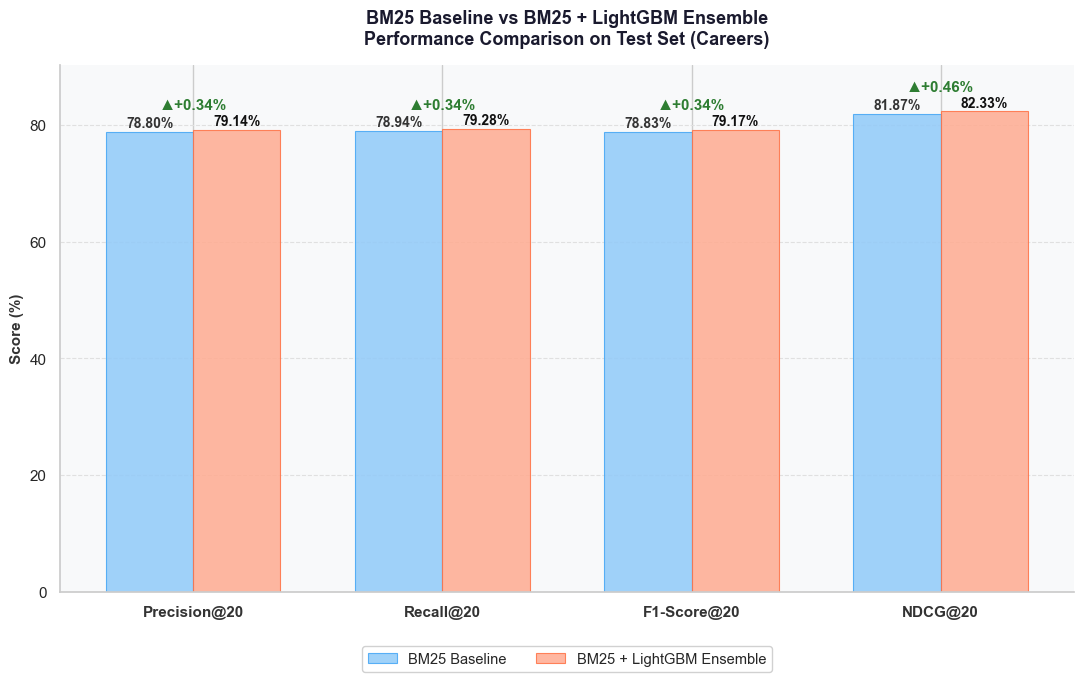

In [ ]:
loaded_bm25_pkg = joblib.load("saved_models/best_bm25_model_careers.joblib")
if isinstance(loaded_bm25_pkg, dict):
    best_bm25 = loaded_bm25_pkg["model"]
    best_config_base = loaded_bm25_pkg["best_config"]
    best_top_n = loaded_bm25_pkg["best_top_n"]
    best_top_k = loaded_bm25_pkg["best_top_k"]
else:
    best_bm25 = loaded_bm25_pkg
    best_config_base = {'column': 'cleaned_title'}
    best_top_n = 10
    best_top_k = 20

model_path_ens = "saved_models/bm25_lightgbm_ensemble_careers.joblib"
if not os.path.exists(model_path_ens):
    model_path_ens = "saved_models/bm25_lambdamart_ensemble_careers.joblib"
loaded_ens = joblib.load(model_path_ens)

final_ranker = loaded_ens["final_ranker"]
bm25_models = loaded_ens["bm25_models"]
best_retrieval_corpus = loaded_ens["best_retrieval_corpus"]
best_config_ens = loaded_ens["best_config"]
N = loaded_ens["best_top_n_neighbors"]
K = loaded_ens["best_top_k"]

print("Evaluating BM25 Baseline from Joblib...")
y_pred_base = []
y_true_base = []
for _, q_row in test_df.iterrows():
    y_true_base.append(q_row['skills_required'])
    q_tokens = q_row[best_config_base['column']].split()
    scores = best_bm25.get_scores(q_tokens)
    top_pos = np.argsort(scores)[::-1][:best_top_n]
    skills_pool = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_base.append([s for s, _ in Counter(skills_pool).most_common(best_top_k)])

metrics_base = {
    'Precision': precision_at_k(y_true_base, y_pred_base, best_top_k),
    'Recall': recall_at_k(y_true_base, y_pred_base, best_top_k),
    'F1-Score': f1_at_k(y_true_base, y_pred_base, best_top_k),
    'NDCG': ndcg_at_k(y_true_base, y_pred_base, best_top_k)
}

print("Evaluating BM25 + LightGBM Ensemble from Joblib...")
y_pred_ensemble = []
y_true_ens = []
for _, q_row in test_df.iterrows():
    y_true_ens.append(q_row['skills_required'])
    q_tokens = q_row[best_config_ens['column']].split()
    bm25_scores = bm25_models[best_retrieval_corpus].get_scores(q_tokens)
    candidate_indices = np.argsort(bm25_scores)[::-1][:100]
    feats = []
    q_words = set(q_tokens)
    f_sl = len(q_tokens)
    f_title_batch = bm25_models['title'].get_batch_scores(q_row['cleaned_title'].split(), candidate_indices)
    f_role_batch  = bm25_models['role'].get_batch_scores(q_row['cleaned_role'].split(), candidate_indices)
    f_req_batch   = bm25_models['req'].get_batch_scores(q_row['cleaned_req'].split(), candidate_indices)
    f_desc_batch  = bm25_models['desc'].get_batch_scores(q_row['cleaned_description'].split(), candidate_indices)
    f_full_batch  = bm25_models['full'].get_batch_scores(q_row['full_content'].split(), candidate_indices)
    for i, idx in enumerate(candidate_indices):
        c_row = train_df.iloc[idx]
        f_o   = len(q_words.intersection(set(c_row['full_content'].split())))
        f_tl  = len(c_row['cleaned_title'].split())
        f_sk  = len(c_row['skills_required'])
        f_rank = i + 1
        feats.append([f_title_batch[i], f_role_batch[i], f_req_batch[i], f_desc_batch[i], f_full_batch[i], f_o, f_tl, f_sl, f_sk, f_rank])
    preds = final_ranker.predict(np.array(feats))
    top_pos = candidate_indices[np.argsort(preds)[::-1][:N]]
    skills_pool = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_ensemble.append([s for s, _ in Counter(skills_pool).most_common(K)])

metrics_ens = {
    'Precision': precision_at_k(y_true_ens, y_pred_ensemble, K),
    'Recall': recall_at_k(y_true_ens, y_pred_ensemble, K),
    'F1-Score': f1_at_k(y_true_ens, y_pred_ensemble, K),
    'NDCG': ndcg_at_k(y_true_ens, y_pred_ensemble, K)
}

labels = ['Precision@20', 'Recall@20', 'F1-Score@20', 'NDCG@20']
base_scores = [metrics_base['Precision'], metrics_base['Recall'], metrics_base['F1-Score'], metrics_base['NDCG']]
ens_scores = [metrics_ens['Precision'], metrics_ens['Recall'], metrics_ens['F1-Score'], metrics_ens['NDCG']]

x = np.arange(len(labels))
width = 0.35
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")
bars_base = ax.bar(x - width/2, base_scores, width, label='BM25 Baseline', color='#90CAF9', alpha=0.85, edgecolor='#42A5F5', linewidth=0.8)
bars_ens  = ax.bar(x + width/2, ens_scores, width, label='BM25 + LightGBM Ensemble', color='#FFAB91', alpha=0.85, edgecolor='#FF7043', linewidth=0.8)

for bar in bars_base:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, color='#333333', fontweight='bold')
for bar in bars_ens:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, color='#111111', fontweight='bold')
for idx_i, (b_val, e_val) in enumerate(zip(base_scores, ens_scores)):
    diff = e_val - b_val
    col = "#2E7D32" if diff >= 0 else "#C62828"
    sym = "▲" if diff >= 0 else "▼"
    ax.text(idx_i, max(b_val, e_val) + 3.0, f'{sym}{diff:+.2f}%',
            ha='center', va='bottom', fontsize=11, color=col, fontweight='bold')
ax.set_title('BM25 Baseline vs BM25 + LightGBM Ensemble\nPerformance Comparison on Test Set (Careers)', fontsize=13, fontweight='bold', color='#1A1A2E', pad=15)
ax.set_ylabel('Score (%)', fontsize=11, color='#333333', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, color='#333333', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='y', color='#E0E0E0', linestyle='--', linewidth=0.8, zorder=0)
ax.set_ylim(0, max(max(base_scores), max(ens_scores)) + 8)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=2, fontsize=10.5, framealpha=0.9, edgecolor='#CCCCCC', facecolor='white')
plt.tight_layout()
plt.show()

Evaluating SBERT Baseline dynamically...
Evaluating SBERT + XGBoost Ensemble dynamically...


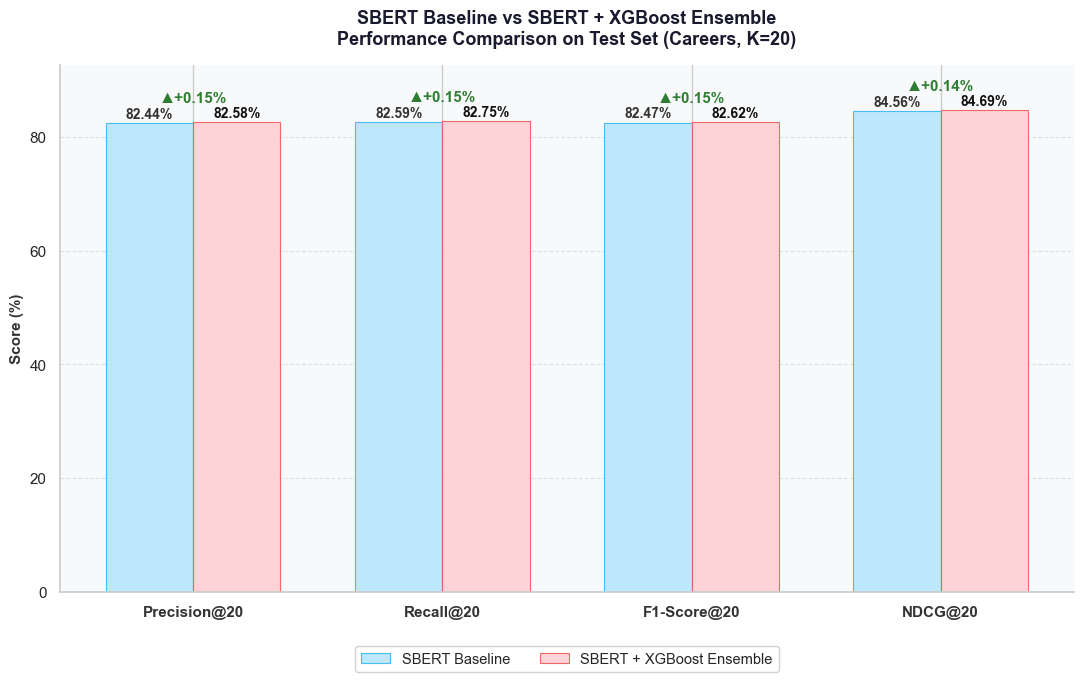

In [ ]:
loaded_sbert_base = joblib.load("saved_models_sbert/sbert_baseline_best_params.joblib")
best_sbert_col = loaded_sbert_base["best_sbert_col"]
best_sbert_k = loaded_sbert_base["best_sbert_N"]
best_sbert_top_k = loaded_sbert_base["best_sbert_top_k"]

model_path_sbert_ens = "saved_models_sbert/sbert_xgb_ensemble_careers.joblib"
loaded_sbert_ens = joblib.load(model_path_sbert_ens)
xgb_sbert_ensemble = loaded_sbert_ens["xgb_model"]
ens_sbert_col = loaded_sbert_ens["best_sbert_col"]
ens_xgb_k = loaded_sbert_ens["best_xgb_k"]
ens_sbert_top_k = loaded_sbert_ens["best_sbert_top_k"]

print("Evaluating SBERT Baseline dynamically...")
y_true_sbert = test_df['skills_required'].tolist()
y_pred_sbert = []

for i in range(len(test_df)):
    query_emb = test_embs_dict[best_sbert_col][i]
    cos_scores = util.cos_sim(query_emb, train_embs_dict[best_sbert_col])[0]
    top_indices = torch.topk(cos_scores, k=best_sbert_k).indices.cpu().numpy()
    retrieved_skills = [s for slist in train_df.iloc[top_indices]['skills_required'] for s in slist]
    top_skills = [s for s, _ in Counter(retrieved_skills).most_common(best_sbert_top_k)]
    y_pred_sbert.append(top_skills)

metrics_base = {
    'Precision': precision_at_k(y_true_sbert, y_pred_sbert, best_sbert_top_k),
    'Recall': recall_at_k(y_true_sbert, y_pred_sbert, best_sbert_top_k),
    'F1-Score': f1_at_k(y_true_sbert, y_pred_sbert, best_sbert_top_k),
    'NDCG': ndcg_at_k(y_true_sbert, y_pred_sbert, best_sbert_top_k)
}

print("Evaluating SBERT + XGBoost Ensemble dynamically...")
y_true_final = test_df['skills_required'].tolist()
y_pred_ens = []
sim_matrix_test = util.cos_sim(test_embs_dict[best_sbert_col], train_embs_sbert_ensemble).cpu().numpy()

for i in range(len(test_df)):
    q_feats = X_test_sbe[i*100 : (i+1)*100]
    scores = xgb_sbert_ensemble.predict(q_feats)
    q_sim = sim_matrix_test[i].copy()
    if i < len(train_df) and test_df.index[i] in train_df.index:
        q_sim[i] = -1.0
    candidates = np.argsort(q_sim)[::-1][:100]
    top_pos = candidates[np.argsort(scores)[::-1][:ens_xgb_k]]
    skills = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_ens.append([s for s, _ in Counter(skills).most_common(ens_sbert_top_k)])

metrics_ens = {
    'Precision': precision_at_k(y_true_final, y_pred_ens, ens_sbert_top_k),
    'Recall': recall_at_k(y_true_final, y_pred_ens, ens_sbert_top_k),
    'F1-Score': f1_at_k(y_true_final, y_pred_ens, ens_sbert_top_k),
    'NDCG': ndcg_at_k(y_true_final, y_pred_ens, ens_sbert_top_k)
}

labels = [f'Precision@{best_sbert_top_k}', f'Recall@{best_sbert_top_k}', f'F1-Score@{best_sbert_top_k}', f'NDCG@{best_sbert_top_k}']
base_scores = [metrics_base['Precision'], metrics_base['Recall'], metrics_base['F1-Score'], metrics_base['NDCG']]
ens_scores = [metrics_ens['Precision'], metrics_ens['Recall'], metrics_ens['F1-Score'], metrics_ens['NDCG']]

x = np.arange(len(labels))
width = 0.35
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")
bars_base = ax.bar(x - width/2, base_scores, width, label='SBERT Baseline', color='#B3E5FC', alpha=0.85, edgecolor='#29B6F6', linewidth=0.8)
bars_ens  = ax.bar(x + width/2, ens_scores, width, label='SBERT + XGBoost Ensemble', color='#FFCDD2', alpha=0.85, edgecolor='#EF5350', linewidth=0.8)

for bar in bars_base:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, color='#333333', fontweight='bold')
for bar in bars_ens:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, color='#111111', fontweight='bold')
for idx_i, (b_val, e_val) in enumerate(zip(base_scores, ens_scores)):
    diff = e_val - b_val
    col = "#2E7D32" if diff >= 0 else "#C62828"
    sym = "▲" if diff >= 0 else "▼"
    ax.text(idx_i, max(b_val, e_val) + 3.0, f'{sym}{diff:+.2f}%',
            ha='center', va='bottom', fontsize=11, color=col, fontweight='bold')

ax.set_title(f'SBERT Baseline vs SBERT + XGBoost Ensemble\nPerformance Comparison on Test Set (Careers, K={best_sbert_top_k})',
             fontsize=13, fontweight='bold', color='#1A1A2E', pad=15)
ax.set_ylabel('Score (%)', fontsize=11, color='#333333', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, color='#333333', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='y', color='#E0E0E0', linestyle='--', linewidth=0.8, zorder=0)
ax.set_ylim(0, max(max(base_scores), max(ens_scores)) + 8)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=2, fontsize=10.5, framealpha=0.9, edgecolor='#CCCCCC', facecolor='white')
plt.tight_layout()
plt.show()

Detected calculated BPR Baseline predictions in memory. Reusing...
Memory conflict detected (SBERT ensemble active). Re-running BPR Ensemble for accuracy...
Evaluating BPR + LightGBM Ensemble dynamically (approx. 1.5 mins)...


BPR Ensemble Inference: 100%|████████████████████████████████████████████████████████| 809/809 [01:42<00:00,  7.87it/s]


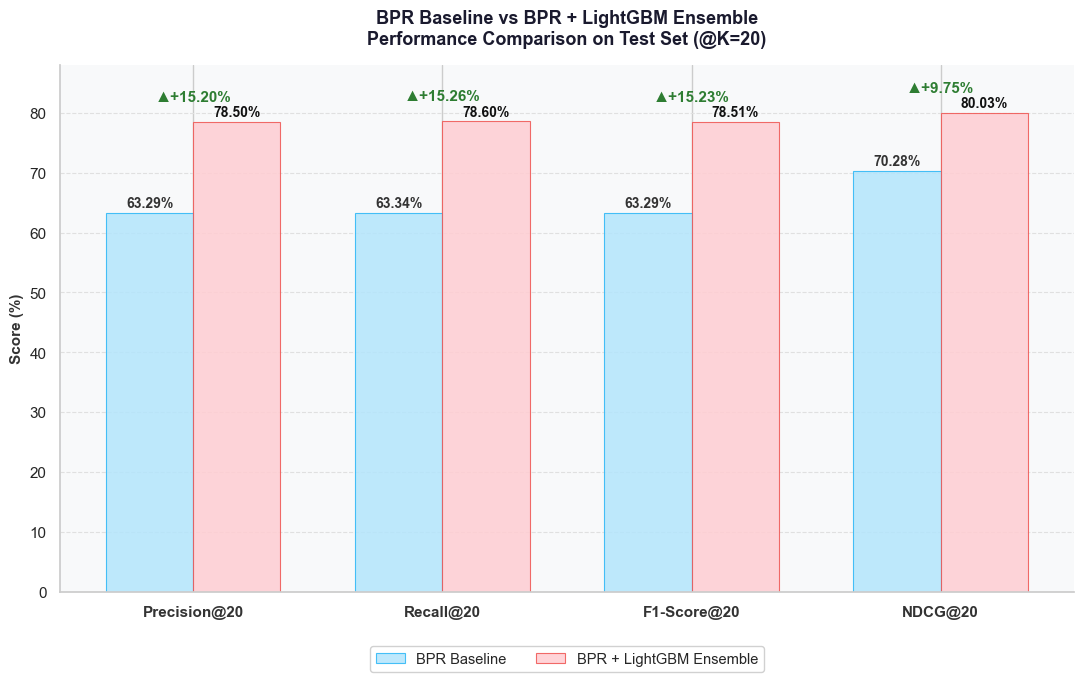

In [ ]:
save_dir = "saved_models_bpr_careers"
base_model_path = os.path.join(save_dir, "bpr_baseline_model_careers.joblib")
ens_model_path = os.path.join(save_dir, "bpr_lightgbm_ensemble_careers.joblib")

loaded_bpr = joblib.load(base_model_path)
bpr_model_baseline = loaded_bpr["bpr_model_baseline"]
final_tfidf_vec = loaded_bpr["final_tfidf_vec"]
final_train_tfidf = loaded_bpr["final_train_tfidf"]
best_config = loaded_bpr["best_config"]
loaded_ens = joblib.load(ens_model_path)
rf_reranker = loaded_ens["rf_reranker"]
best_ens_k = loaded_ens["best_ens_k"]
final_col = best_config['column']
final_neighbor_n = best_config['neighbor_n']
final_top_k = best_config['top_k']

y_true_bpr = test_df['skills_required'].tolist()
run_baseline = True
if 'y_pred_bpr' in globals() and len(y_pred_bpr) == len(test_df):
    y_pred_bpr_base = y_pred_bpr
    print("Detected calculated BPR Baseline predictions in memory. Reusing...")
    run_baseline = False
else:
    y_pred_bpr_base = []

if run_baseline:
    print("Evaluating BPR Baseline dynamically...")
    test_tfidf = final_tfidf_vec.transform(test_df[final_col].fillna(''))
    sims_bpr = cosine_similarity(test_tfidf, final_train_tfidf)
    for i in range(len(test_df)):
        neighbor_indices = np.argsort(sims_bpr[i])[::-1][:final_neighbor_n]
        avg_factor = np.mean(bpr_model_baseline.user_factors[neighbor_indices], axis=0)
        scores = avg_factor.dot(bpr_model_baseline.item_factors.T)
        top_skill_ids = np.argsort(scores)[::-1][:final_top_k]
        recommended_skills = [id_to_skill[idx] for idx in top_skill_ids]
        y_pred_bpr_base.append(recommended_skills)

metrics_base = {
    'Precision': precision_at_k(y_true_bpr, y_pred_bpr_base, k=final_top_k),
    'Recall': recall_at_k(y_true_bpr, y_pred_bpr_base, k=final_top_k),
    'F1-Score': f1_at_k(y_true_bpr, y_pred_bpr_base, k=final_top_k),
    'NDCG': ndcg_at_k(y_true_bpr, y_pred_bpr_base, k=final_top_k)
}

y_true_ens = test_df['skills_required'].tolist()
run_ensemble = True

if 'y_pred_ens' in globals() and len(y_pred_ens) == len(test_df):
    if 'xgb_sbert_ensemble' in globals() and 'sim_matrix_test' in globals():
         print("Memory conflict detected (SBERT ensemble active). Re-running BPR Ensemble for accuracy...")
         run_ensemble = True
    else:
         y_pred_bpr_ens = y_pred_ens
         print("Detected calculated BPR Ensemble predictions in memory. Reusing...")
         run_ensemble = False
else:
    y_pred_bpr_ens = []

if run_ensemble:
    print("Evaluating BPR + LightGBM Ensemble dynamically (approx. 1.5 mins)...")
    test_tfidf_temp = final_tfidf_vec.transform(test_df[final_col].fillna(''))
    sim_matrix_test = cosine_similarity(test_tfidf_temp, final_train_tfidf)
    y_pred_bpr_ens = []

    for i in tqdm(range(len(test_df)), desc="BPR Ensemble Inference"):
        q_tfidf = test_tfidf_temp[i]
        neighbors = np.argsort(sim_matrix_test[i])[::-1][:final_neighbor_n]
        avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
        neighbor_skills_flat = [s for idx in neighbors for s in train_df_unique.iloc[idx]['skills_required']]
        neighbor_skill_counts = Counter(neighbor_skills_flat)
        scores = avg_f.dot(bpr_model_baseline.item_factors.T)
        candidate_ids = np.argsort(scores)[::-1][:200]
        feats = extract_hybrid_features(candidate_ids, scores, neighbor_skill_counts, q_tfidf)
        scores_pred = rf_reranker.predict(feats)
        sorted_indices = np.argsort(scores_pred)[::-1][:best_ens_k]
        y_pred_bpr_ens.append([id_to_skill[candidate_ids[idx]] for idx in sorted_indices])

metrics_ens = {
    'Precision': precision_at_k(y_true_ens, y_pred_bpr_ens, k=best_ens_k),
    'Recall': recall_at_k(y_true_ens, y_pred_bpr_ens, k=best_ens_k),
    'F1-Score': f1_at_k(y_true_ens, y_pred_bpr_ens, k=best_ens_k),
    'NDCG': ndcg_at_k(y_true_ens, y_pred_bpr_ens, k=best_ens_k),
}

labels = [f'Precision@{final_top_k}', f'Recall@{final_top_k}', f'F1-Score@{final_top_k}', f'NDCG@{final_top_k}']
base_scores = [metrics_base['Precision'], metrics_base['Recall'], metrics_base['F1-Score'], metrics_base['NDCG']]
ens_scores = [metrics_ens['Precision'], metrics_ens['Recall'], metrics_ens['F1-Score'], metrics_ens['NDCG']]

x = np.arange(len(labels))
width = 0.35
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")
bars_base = ax.bar(x - width/2, base_scores, width, label='BPR Baseline', color='#B3E5FC', alpha=0.85, edgecolor='#29B6F6', linewidth=0.8)
bars_ens  = ax.bar(x + width/2, ens_scores, width, label='BPR + LightGBM Ensemble', color='#FFCDD2', alpha=0.85, edgecolor='#EF5350', linewidth=0.8)
for bar in bars_base:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, color='#333333', fontweight='bold')
for bar in bars_ens:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, color='#111111', fontweight='bold')
for idx_i, (b_val, e_val) in enumerate(zip(base_scores, ens_scores)):
    diff = e_val - b_val
    col = "#2E7D32" if diff >= 0 else "#C62828"
    sym = "▲" if diff >= 0 else "▼"
    ax.text(idx_i, max(b_val, e_val) + 3.0, f'{sym}{diff:+.2f}%',
            ha='center', va='bottom', fontsize=11, color=col, fontweight='bold')
ax.set_title(f'BPR Baseline vs BPR + LightGBM Ensemble\nPerformance Comparison on Test Set (@K={final_top_k})',
             fontsize=13, fontweight='bold', color='#1A1A2E', pad=15)
ax.set_ylabel('Score (%)', fontsize=11, color='#333333', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, color='#333333', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='y', color='#E0E0E0', linestyle='--', linewidth=0.8, zorder=0)
ax.set_ylim(0, max(max(base_scores), max(ens_scores)) + 8)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=2, fontsize=10.5, framealpha=0.9, edgecolor='#CCCCCC', facecolor='white')
plt.tight_layout()
plt.show()

Evaluating BM25 + LightGBM Ensemble dynamically on test set...
Evaluating BPR + LightGBM Ensemble dynamically on test set...


BPR Ensemble Inference: 100%|████████████████████████████████████████████████████████| 809/809 [01:41<00:00,  7.96it/s]


Evaluating SBERT + XGBoost Ensemble dynamically on test set...


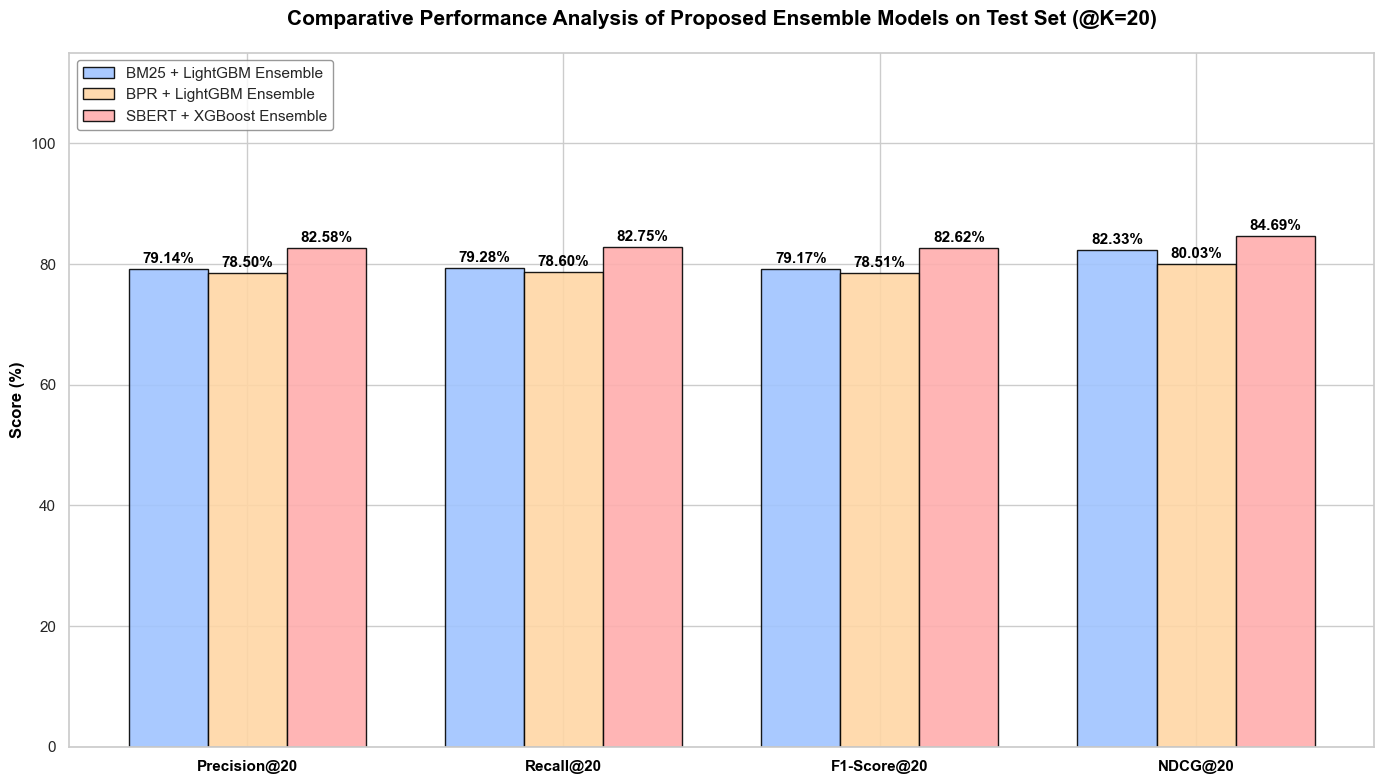

In [ ]:
print("Evaluating BM25 + LightGBM Ensemble dynamically on test set...")
model_path_ens_bm25 = "saved_models/bm25_lightgbm_ensemble_careers.joblib"
if not os.path.exists(model_path_ens_bm25):
    model_path_ens_bm25 = "saved_models/bm25_lambdamart_ensemble_careers.joblib"
loaded_ens_bm25 = joblib.load(model_path_ens_bm25)

final_ranker_bm25 = loaded_ens_bm25["final_ranker"]
bm25_models = loaded_ens_bm25["bm25_models"]
best_retrieval_corpus = loaded_ens_bm25["best_retrieval_corpus"]
best_config_ens_bm25 = loaded_ens_bm25["best_config"]
N_bm25 = loaded_ens_bm25["best_top_n_neighbors"]
K_bm25 = loaded_ens_bm25["best_top_k"]

y_pred_bm25 = []
y_true_bm25 = []
for _, q_row in test_df.iterrows():
    y_true_bm25.append(q_row['skills_required'])
    q_tokens = q_row[best_config_ens_bm25['column']].split()
    bm25_scores = bm25_models[best_retrieval_corpus].get_scores(q_tokens)
    candidate_indices = np.argsort(bm25_scores)[::-1][:100]
    feats = []
    q_words = set(q_tokens)
    f_sl = len(q_tokens)
    f_title_batch = bm25_models['title'].get_batch_scores(q_row['cleaned_title'].split(), candidate_indices)
    f_role_batch  = bm25_models['role'].get_batch_scores(q_row['cleaned_role'].split(), candidate_indices)
    f_req_batch   = bm25_models['req'].get_batch_scores(q_row['cleaned_req'].split(), candidate_indices)
    f_desc_batch  = bm25_models['desc'].get_batch_scores(q_row['cleaned_description'].split(), candidate_indices)
    f_full_batch  = bm25_models['full'].get_batch_scores(q_row['full_content'].split(), candidate_indices)
    for i, idx in enumerate(candidate_indices):
        c_row = train_df.iloc[idx]
        f_o   = len(q_words.intersection(set(c_row['full_content'].split())))
        f_tl  = len(c_row['cleaned_title'].split())
        f_sk  = len(c_row['skills_required'])
        f_rank = i + 1
        feats.append([f_title_batch[i], f_role_batch[i], f_req_batch[i], f_desc_batch[i], f_full_batch[i], f_o, f_tl, f_sl, f_sk, f_rank])
    preds = final_ranker_bm25.predict(np.array(feats))
    top_pos = candidate_indices[np.argsort(preds)[::-1][:N_bm25]]
    skills_pool = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_bm25.append([s for s, _ in Counter(skills_pool).most_common(K_bm25)])

metrics_bm25 = {
    'Precision': precision_at_k(y_true_bm25, y_pred_bm25, K_bm25),
    'Recall': recall_at_k(y_true_bm25, y_pred_bm25, K_bm25),
    'F1-Score': f1_at_k(y_true_bm25, y_pred_bm25, K_bm25),
    'NDCG': ndcg_at_k(y_true_bm25, y_pred_bm25, K_bm25)
}

print("Evaluating BPR + LightGBM Ensemble dynamically on test set...")
loaded_ens_bpr = joblib.load("saved_models_bpr_careers/bpr_lightgbm_ensemble_careers.joblib")
rf_reranker = loaded_ens_bpr["rf_reranker"]
bpr_model_baseline = loaded_ens_bpr["bpr_model_baseline"]
final_tfidf_vec = loaded_ens_bpr["final_tfidf_vec"]
final_train_tfidf = loaded_ens_bpr["final_train_tfidf"]
best_config_bpr = loaded_ens_bpr["best_config"]
best_ens_k_bpr = loaded_ens_bpr["best_ens_k"]
final_col_bpr = best_config_bpr['column']
final_neighbor_n_bpr = best_config_bpr['neighbor_n']

y_pred_bpr = []
y_true_bpr = test_df['skills_required'].tolist()
test_tfidf_temp = final_tfidf_vec.transform(test_df[final_col_bpr].fillna(''))
sim_matrix_test_bpr = cosine_similarity(test_tfidf_temp, final_train_tfidf)

for i in tqdm(range(len(test_df)), desc="BPR Ensemble Inference"):
    q_tfidf = test_tfidf_temp[i]
    neighbors = np.argsort(sim_matrix_test_bpr[i])[::-1][:final_neighbor_n_bpr]
    avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
    neighbor_skills_flat = [s for idx in neighbors for s in train_df_unique.iloc[idx]['skills_required']]
    neighbor_skill_counts = Counter(neighbor_skills_flat)
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    candidate_ids = np.argsort(scores)[::-1][:200]
    feats = extract_hybrid_features(candidate_ids, scores, neighbor_skill_counts, q_tfidf)
    scores_pred = rf_reranker.predict(feats)
    sorted_indices = np.argsort(scores_pred)[::-1][:best_ens_k_bpr]
    y_pred_bpr.append([id_to_skill[candidate_ids[idx]] for idx in sorted_indices])

metrics_bpr = {
    'Precision': precision_at_k(y_true_bpr, y_pred_bpr, k=best_ens_k_bpr),
    'Recall': recall_at_k(y_true_bpr, y_pred_bpr, k=best_ens_k_bpr),
    'F1-Score': f1_at_k(y_true_bpr, y_pred_bpr, k=best_ens_k_bpr),
    'NDCG': ndcg_at_k(y_true_bpr, y_pred_bpr, k=best_ens_k_bpr)
}

print("Evaluating SBERT + XGBoost Ensemble dynamically on test set...")
loaded_ens_sbert = joblib.load("saved_models_sbert/sbert_xgb_ensemble_careers.joblib")
xgb_sbert_ensemble = loaded_ens_sbert["xgb_model"]
ens_sbert_col = loaded_ens_sbert["best_sbert_col"]
ens_xgb_k = loaded_ens_sbert["best_xgb_k"]
ens_sbert_top_k = loaded_ens_sbert["best_sbert_top_k"]

y_pred_sbert = []
y_true_sbert = test_df['skills_required'].tolist()
sim_matrix_test_sbert = util.cos_sim(test_embs_dict[ens_sbert_col], train_embs_sbert_ensemble).cpu().numpy()

for i in range(len(test_df)):
    q_feats = X_test_sbe[i*100 : (i+1)*100]
    scores = xgb_sbert_ensemble.predict(q_feats)
    q_sim = sim_matrix_test_sbert[i].copy()
    if i < len(train_df) and test_df.index[i] in train_df.index:
        q_sim[i] = -1.0
    candidates = np.argsort(q_sim)[::-1][:100]
    top_pos = candidates[np.argsort(scores)[::-1][:ens_xgb_k]]
    skills = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_sbert.append([s for s, _ in Counter(skills).most_common(ens_sbert_top_k)])

metrics_sbert = {
    'Precision': precision_at_k(y_true_sbert, y_pred_sbert, ens_sbert_top_k),
    'Recall': recall_at_k(y_true_sbert, y_pred_sbert, ens_sbert_top_k),
    'F1-Score': f1_at_k(y_true_sbert, y_pred_sbert, ens_sbert_top_k),
    'NDCG': ndcg_at_k(y_true_sbert, y_pred_sbert, ens_sbert_top_k)
}

labels = [f'Precision@20', f'Recall@20', f'F1-Score@20', f'NDCG@20']
bm25_scores    = [metrics_bm25['Precision'], metrics_bm25['Recall'], metrics_bm25['F1-Score'], metrics_bm25['NDCG']]
bpr_scores     = [metrics_bpr['Precision'], metrics_bpr['Recall'], metrics_bpr['F1-Score'], metrics_bpr['NDCG']]
sbert_scores   = [metrics_sbert['Precision'], metrics_sbert['Recall'], metrics_sbert['F1-Score'], metrics_sbert['NDCG']]

x = np.arange(len(labels))
width = 0.25
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))
bars_bm25 = ax.bar(x - width, bm25_scores, width, label='BM25 + LightGBM Ensemble', color='#A0C4FF', alpha=0.9, edgecolor='black', linewidth=1.0)
bars_bpr = ax.bar(x, bpr_scores, width, label='BPR + LightGBM Ensemble', color='#FFD6A5', alpha=0.9, edgecolor='black', linewidth=1.0)
bars_sbert = ax.bar(x + width, sbert_scores, width, label='SBERT + XGBoost Ensemble', color='#FFADAD', alpha=0.9, edgecolor='black', linewidth=1.0)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
add_labels(bars_bm25)
add_labels(bars_bpr)
add_labels(bars_sbert)
ax.set_title('Comparative Performance Analysis of Proposed Ensemble Models on Test Set (@K=20)', fontsize=15, fontweight='bold', pad=20, color='black')
ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold', color='black')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold', color='black')
ax.legend(fontsize=11, loc='upper left', frameon=True, facecolor='white', edgecolor='gray')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

In [ ]:
def calc_mrr(y_true, y_pred, k=100):
    rr = []
    for true_skills, pred_skills in zip(y_true, y_pred):
        pred_k = pred_skills[:k]
        found = False
        for rank, s in enumerate(pred_k):
            if s in true_skills:
                rr.append(1.0 / (rank + 1))
                found = True
                break
        if not found:
            rr.append(0.0)
    return np.mean(rr) * 100

def calc_recall(y_true, y_pred, k):
    recalls = []
    for true_skills, pred_skills in zip(y_true, y_pred):
        pred_k = pred_skills[:k]
        if not true_skills: recalls.append(0)
        else: recalls.append(len(set(true_skills).intersection(pred_k)) / len(true_skills))
    return np.mean(recalls) * 100

def calc_ndcg(y_true, y_pred, k):
    ndcgs = []
    for true_skills, pred_skills in zip(y_true, y_pred):
        pred_k = pred_skills[:k]
        dcg, idcg = 0.0, 0.0
        for i, s in enumerate(pred_k):
            if s in true_skills: dcg += 1.0 / np.log2(i + 2)
        for i in range(min(len(true_skills), k)):
            idcg += 1.0 / np.log2(i + 2)
        ndcgs.append(dcg / idcg if idcg > 0.0 else 0.0)
    return np.mean(ndcgs) * 100

print("Running BM25 + LightGBM Ensemble Inference...")
model_path_ens_bm25 = "saved_models/bm25_lightgbm_ensemble_careers.joblib"
if not os.path.exists(model_path_ens_bm25):
    model_path_ens_bm25 = "saved_models/bm25_lambdamart_ensemble_careers.joblib"
loaded_ens_bm25 = joblib.load(model_path_ens_bm25)
final_ranker_bm25 = loaded_ens_bm25["final_ranker"]
bm25_models = loaded_ens_bm25["bm25_models"]
best_retrieval_corpus = loaded_ens_bm25["best_retrieval_corpus"]
best_config_ens_bm25 = loaded_ens_bm25["best_config"]
N_bm25 = loaded_ens_bm25["best_top_n_neighbors"]

y_pred_bm25_full = []
y_true_bm25 = []
for _, q_row in test_df.iterrows():
    y_true_bm25.append(q_row['skills_required'])
    q_tokens = q_row[best_config_ens_bm25['column']].split()
    bm25_scores = bm25_models[best_retrieval_corpus].get_scores(q_tokens)
    candidate_indices = np.argsort(bm25_scores)[::-1][:100]
    feats = []
    q_words = set(q_tokens)
    f_sl = len(q_tokens)
    f_title_batch = bm25_models['title'].get_batch_scores(q_row['cleaned_title'].split(), candidate_indices)
    f_role_batch  = bm25_models['role'].get_batch_scores(q_row['cleaned_role'].split(), candidate_indices)
    f_req_batch   = bm25_models['req'].get_batch_scores(q_row['cleaned_req'].split(), candidate_indices)
    f_desc_batch  = bm25_models['desc'].get_batch_scores(q_row['cleaned_description'].split(), candidate_indices)
    f_full_batch  = bm25_models['full'].get_batch_scores(q_row['full_content'].split(), candidate_indices)
    for i, idx in enumerate(candidate_indices):
        c_row = train_df.iloc[idx]
        f_o   = len(q_words.intersection(set(c_row['full_content'].split())))
        f_tl  = len(c_row['cleaned_title'].split())
        f_sk  = len(c_row['skills_required'])
        f_rank = i + 1
        feats.append([f_title_batch[i], f_role_batch[i], f_req_batch[i], f_desc_batch[i], f_full_batch[i], f_o, f_tl, f_sl, f_sk, f_rank])
    preds = final_ranker_bm25.predict(np.array(feats))
    top_pos = candidate_indices[np.argsort(preds)[::-1][:N_bm25]]
    skills_pool = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_bm25_full.append([s for s, _ in Counter(skills_pool).most_common(100)])

print("Running BPR + LightGBM Ensemble Inference (approx. 1.5 mins)...")
loaded_ens_bpr = joblib.load("saved_models_bpr_careers/bpr_lightgbm_ensemble_careers.joblib")
rf_reranker = loaded_ens_bpr["rf_reranker"]
bpr_model_baseline = loaded_ens_bpr["bpr_model_baseline"]
final_tfidf_vec = loaded_ens_bpr["final_tfidf_vec"]
final_train_tfidf = loaded_ens_bpr["final_train_tfidf"]
best_config_bpr = loaded_ens_bpr["best_config"]
final_col_bpr = best_config_bpr['column']
final_neighbor_n_bpr = best_config_bpr['neighbor_n']

y_pred_bpr_full = []
y_true_bpr = test_df['skills_required'].tolist()
test_tfidf_temp = final_tfidf_vec.transform(test_df[final_col_bpr].fillna(''))
sim_matrix_test_bpr = cosine_similarity(test_tfidf_temp, final_train_tfidf)

for i in tqdm(range(len(test_df)), desc="BPR Ensemble Inference"):
    q_tfidf = test_tfidf_temp[i]
    neighbors = np.argsort(sim_matrix_test_bpr[i])[::-1][:final_neighbor_n_bpr]
    avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
    neighbor_skills_flat = [s for idx in neighbors for s in train_df_unique.iloc[idx]['skills_required']]
    neighbor_skill_counts = Counter(neighbor_skills_flat)
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    candidate_ids = np.argsort(scores)[::-1][:200]
    feats = extract_hybrid_features(candidate_ids, scores, neighbor_skill_counts, q_tfidf)
    scores_pred = rf_reranker.predict(feats)
    sorted_indices = np.argsort(scores_pred)[::-1][:100]
    y_pred_bpr_full.append([id_to_skill[candidate_ids[idx]] for idx in sorted_indices])

print("Running SBERT + XGBoost Ensemble Inference...")
loaded_ens_sbert = joblib.load("saved_models_sbert/sbert_xgb_ensemble_careers.joblib")
xgb_sbert_ensemble = loaded_ens_sbert["xgb_model"]
ens_sbert_col = loaded_ens_sbert["best_sbert_col"]
ens_xgb_k = loaded_ens_sbert["best_xgb_k"]

y_pred_sbert_full = []
y_true_sbert = test_df['skills_required'].tolist()
sim_matrix_test_sbert = util.cos_sim(test_embs_dict[ens_sbert_col], train_embs_sbert_ensemble).cpu().numpy()

for i in range(len(test_df)):
    q_feats = X_test_sbe[i*100 : (i+1)*100]
    scores = xgb_sbert_ensemble.predict(q_feats)
    q_sim = sim_matrix_test_sbert[i].copy()
    if i < len(train_df) and test_df.index[i] in train_df.index:
        q_sim[i] = -1.0
    candidates = np.argsort(q_sim)[::-1][:100]
    top_pos = candidates[np.argsort(scores)[::-1][:ens_xgb_k]]
    skills = [s for slist in train_df.iloc[top_pos]['skills_required'] for s in slist]
    y_pred_sbert_full.append([s for s, _ in Counter(skills).most_common(100)])
print("Computing metrics and generating comparison table...")

paper_results = {
    'MRR': 90.49,
    'Recall@5': 21.67, 'Recall@10': 40.49, 'Recall@30': 79.59, 'Recall@50': 86.60, 'Recall@100': 92.24,
    'NDCG@5': 35.93, 'NDCG@10': 52.84, 'NDCG@30': 79.32, 'NDCG@50': 82.96, 'NDCG@100': 85.41
}

def get_metrics_dict(y_true, y_pred):
    return {
        'MRR': calc_mrr(y_true, y_pred, 100),
        'Recall@5': calc_recall(y_true, y_pred, 5),
        'Recall@10': calc_recall(y_true, y_pred, 10),
        'Recall@30': calc_recall(y_true, y_pred, 30),
        'Recall@50': calc_recall(y_true, y_pred, 50),
        'Recall@100': calc_recall(y_true, y_pred, 100),
        'NDCG@5': calc_ndcg(y_true, y_pred, 5),
        'NDCG@10': calc_ndcg(y_true, y_pred, 10),
        'NDCG@30': calc_ndcg(y_true, y_pred, 30),
        'NDCG@50': calc_ndcg(y_true, y_pred, 50),
        'NDCG@100': calc_ndcg(y_true, y_pred, 100)
    }
bm25_metrics = get_metrics_dict(y_true_bm25, y_pred_bm25_full)
bpr_metrics  = get_metrics_dict(y_true_bpr, y_pred_bpr_full)
sbert_metrics = get_metrics_dict(y_true_sbert, y_pred_sbert_full)

def format_diff(ens_val, paper_val):
    diff = ens_val - paper_val
    return f"{diff:+.2f}%"

rows = []
metrics_order = ['MRR', 'Recall@5', 'Recall@10', 'Recall@30', 'Recall@50', 'Recall@100', 'NDCG@5', 'NDCG@10', 'NDCG@30', 'NDCG@50', 'NDCG@100']

for m in metrics_order:
    p_val = paper_results[m]
    bm25_val = bm25_metrics[m]
    bpr_val  = bpr_metrics[m]
    sbert_val = sbert_metrics[m]

    rows.append({
        'Metric': m,
        'Research Paper': f"{p_val:.2f}%" if m != 'MRR' else f"{p_val/100:.4f}",
        'BM25 Ensemble': f"{bm25_val:.2f}%",
        'BM25 Diff': format_diff(bm25_val, p_val),
        'BPR Ensemble': f"{bpr_val:.2f}%",
        'BPR Diff': format_diff(bpr_val, p_val),
        'SBERT Ensemble': f"{sbert_val:.2f}%",
        'SBERT Diff': format_diff(sbert_val, p_val)
    })

df_compare = pd.DataFrame(rows)

def style_diff_cols(val):
    if isinstance(val, str):
        if val.startswith('+'):
            return 'color: #2e7d32; font-weight: bold; background-color: #e8f5e9;'
        elif val.startswith('-'):
            return 'color: #c62828; font-weight: bold; background-color: #ffebee;'
    return ''

styled_table = df_compare.style.map(
    style_diff_cols,
    subset=['BM25 Diff', 'BPR Diff', 'SBERT Diff']
).set_properties(**{
    'text-align': 'center',
    'font-family': 'Calibri, Arial, sans-serif'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#333333'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
])
print("Evaluation Done! Displaying colored comparison table:")
styled_table

Running BM25 + LightGBM Ensemble Inference...
Running BPR + LightGBM Ensemble Inference (approx. 1.5 mins)...


BPR Ensemble Inference: 100%|████████████████████████████████████████████████████████| 809/809 [01:45<00:00,  7.69it/s]


Running SBERT + XGBoost Ensemble Inference...
Computing metrics and generating comparison table...
Evaluation Done! Displaying colored comparison table:


,Metric,Research Paper,BM25 Ensemble,BM25 Diff,BPR Ensemble,BPR Diff,SBERT Ensemble,SBERT Diff
0,MRR,0.9049,94.56%,+4.07%,88.15%,-2.34%,94.10%,+3.61%
1,Recall@5,21.67%,22.26%,+0.59%,20.83%,-0.84%,22.24%,+0.57%
2,Recall@10,40.49%,42.95%,+2.46%,40.90%,+0.41%,43.33%,+2.84%
3,Recall@30,79.59%,86.27%,+6.68%,83.77%,+4.18%,86.65%,+7.06%
4,Recall@50,86.60%,90.34%,+3.74%,87.09%,+0.49%,89.34%,+2.74%
5,Recall@100,92.24%,91.72%,-0.52%,88.89%,-3.35%,90.13%,-2.11%
6,NDCG@5,35.93%,89.71%,+53.78%,83.24%,+47.31%,89.40%,+53.47%
7,NDCG@10,52.84%,87.25%,+34.41%,82.19%,+29.35%,87.61%,+34.77%
8,NDCG@30,79.32%,86.52%,+7.20%,83.13%,+3.81%,87.00%,+7.68%
9,NDCG@50,82.96%,88.68%,+5.72%,84.89%,+1.93%,88.41%,+5.45%
